In [94]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [95]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1,
                       k_max=None):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    # Highest K kept from the count-curve inputs. Defaults to the notebook constant, so
    # raising COUNT_CURVE_K_MAX in the Constants cell widens everything at once.
    k_max = int(globals().get("COUNT_CURVE_K_MAX", 3)) if k_max is None else int(k_max)
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    G_curve, G_curve_K, G_pmf = None, None, None
    G_pmf_se = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        #
        # The WHOLE curve is kept, not only the targeted row: G_s(K) for K >= 1 is a
        # genuinely untargeted check on the count distribution (gate V8 of
        # documentation/granular_validation.md), and load_parameters.jl reads the K = 0
        # row alone, so nothing on the Julia side carries it.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        G_curve_K = sorted({int(k) for k in G_K[c_K].astype(float).round()})
        G_curve = np.full((S, len(G_curve_K)), np.nan)
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            k_sub = sub[c_K].astype(float).round().astype(int).values
            g_sub = sub[c_G].astype(float).values
            for kk, gg in zip(k_sub, g_sub):
                G_curve[s, G_curve_K.index(kk)] = gg
            if 0 not in k_sub:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = G_curve[s, G_curve_K.index(0)]
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

        # The INCREMENTS, p_s(K) = Pr[K_ls = K] = G(K) - G(K-1), which is what the
        # reporting plots. G_K.csv stores the CDF, but N_hat_s is calibrated on the
        # K = 0 level, so under a cumulative convention every panel would contain the
        # fitted level and re-test what is already targeted. The increments isolate the
        # untargeted content -- the SHAPE of the count distribution. p_s(0) = G_s(0), so
        # the targeted panel is unchanged.
        # Truncate at k_max BEFORE differencing (the increment at K needs only K and
        # K-1, so dropping the tail changes nothing that survives). G_target was already
        # taken from the K = 0 column above and is unaffected.
        keep = [i for i, k in enumerate(G_curve_K) if k <= k_max]
        G_curve_K = [G_curve_K[i] for i in keep]
        G_curve = G_curve[:, keep]

        # A (sector, K) row absent from G_K.csv leaves a NaN in the CDF, and differencing
        # then poisons TWO increments -- K and K+1 -- so a single missing row silently
        # erases two empirical points. But G is CUMULATIVE: where no row was written, no
        # mass was added, so the CDF is simply flat there. Carry the last value forward
        # (K = 0 is required present, asserted above) and say which cells were filled,
        # so a gap is visible rather than turning into a hole in the figure.
        filled = []
        for s_i in range(S):
            for j in range(1, len(G_curve_K)):
                if not np.isfinite(G_curve[s_i, j]) and np.isfinite(G_curve[s_i, j - 1]):
                    G_curve[s_i, j] = G_curve[s_i, j - 1]
                    filled.append((sector_codes[s_i], G_curve_K[j]))
        if filled:
            print(f"[load] G_K.csv has no row for {filled}; the CDF is flat there (no mass "
                  "added), so those increments are read as 0 rather than dropped.")
        # Requires consecutive K from 0; a gap would make the difference meaningless.
        if G_curve_K == list(range(len(G_curve_K))):
            G_pmf = np.diff(G_curve, axis=1, prepend=0.0)
        else:
            G_pmf = None
            print(f"[load] G_K.csv has non-consecutive K = {G_curve_K}; the increments "
                  "p_s(K) = G(K) - G(K-1) are not well defined and are left empty.")

    # ------------------- bootstrap variance of the empirical increments (optional)
    # `G_K_var.csv` is `A129, K, var` (or `se`) and carries the BOOTSTRAP variance of
    # p_s(K) = share of cells with EXACTLY K suppliers -- the same object G_pmf holds.
    # It is optional: absent, the empirical panels are drawn without a band, exactly as
    # before. Sigma_data's count block covers K = 0 only, which is why the rest needs a
    # file at all; the K = 0 column is therefore a free CONSISTENCY CHECK against it and
    # is compared below rather than trusted.
    gkv_path = input_folder / "G_K_var.csv"
    if granular and gkv_path.exists() and sector_codes is not None:
        gkv = pd.read_csv(gkv_path)
        v_sector = _gk_col(gkv, ("a129", "sector"))
        v_K = _gk_col(gkv, ("k",))
        # The value column, by name where the name says what it is, and otherwise by
        # elimination: a file written off G_K.csv's own schema often keeps the column
        # called `G`, which names the object measured, not the statistic. Whatever is
        # left once A129 and K are removed is taken as a VARIANCE (the file's stated
        # content), and the choice is printed rather than assumed silently -- a variance
        # read as an SE would be off by orders of magnitude, which is exactly what the
        # K = 0 check against diag(Sigma_data) below is there to catch.
        _named = {c: c.strip().lower() for c in gkv.columns}
        v_col = next((c for c, n in _named.items()
                      if n in ("var", "variance", "v", "var_g", "g_var")), None)
        is_var = v_col is not None
        if v_col is None:
            v_col = next((c for c, n in _named.items()
                          if n in ("se", "sd", "std", "stderr", "se_g")), None)
        if v_col is None:
            spare = [c for c in gkv.columns if c not in (v_sector, v_K)]
            if len(spare) != 1:
                raise KeyError(
                    f"{gkv_path.name}: cannot tell which column holds the variance. "
                    f"Columns are {list(gkv.columns)}; expected one named var/variance "
                    "(or se/sd/std) beside A129 and K, or exactly one other column.")
            v_col, is_var = spare[0], True
            print(f"[load] {gkv_path.name}: reading column '{v_col}' as the VARIANCE of "
                  "the increment p_s(K) (no var/se column name to go on). Rename it to "
                  "`var` or `se` to be explicit.")
        # Sectors are matched BY VALUE on the A129 code, so the two files must agree on
        # its dtype: an int64 A129 here against a string one in G_K.csv (a leading zero,
        # a quoted field) matches nothing and would hand back an all-NaN band with no
        # complaint. Compare on the stripped string form, and say which codes missed.
        gkv_key = gkv[v_sector].astype(str).str.strip()
        G_pmf_se = np.full((S, len(G_curve_K)), np.nan)
        unmatched = []
        for s_i, code in enumerate(sector_codes):
            sub = gkv[gkv_key == str(code).strip()]
            if sub.empty:
                unmatched.append(code)
                continue
            for kk, vv in zip(sub[v_K].astype(float).round().astype(int).values,
                              sub[v_col].astype(float).values):
                if kk in G_curve_K:
                    G_pmf_se[s_i, G_curve_K.index(kk)] = (
                        np.sqrt(max(vv, 0.0)) if is_var else abs(vv))
        if unmatched:
            print(f"[load] G_K_var.csv has no row for A129 = {unmatched} (it carries "
                  f"{sorted(gkv_key.unique())[:6]}...); those sectors get no empirical "
                  "band. The A129 column must hold the same sector CODES as G_K.csv.")

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # G_target is ordered by G_K.csv's OWN sorted A129, the labels by
    # filter_N_upstream.csv's. load_parameters.jl does the same and asserts only that
    # the two have the same LENGTH, so a differing code SET silently assigns each
    # sector another sector's zero-supplier target — the count moment then reads as a
    # fit failure (or a suspiciously good fit) in the wrong sector, in Julia and here
    # alike. Compare the sets, not the counts.
    if granular and sector_codes is not None and filter_N_upstream_df is not None:
        _gk = [str(a) for a in sector_codes]
        if _gk != list(sector_names):
            raise ValueError(
                "G_K.csv and filter_N_upstream.csv do not enumerate the same sectors:\n"
                f"  G_K.csv            : {_gk}\n"
                f"  filter_N_upstream  : {list(sector_names)}\n"
                "Gbar_s(0) would be attached to the wrong sector (in load_parameters.jl too).")

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ------- the count DISTRIBUTION: Julia's own fitted curve and its delta-method SE
    # Written by `compute_profiled_T_inference`. `se_G_curve_delta.npy` is (S, |K|):
    # for a FREE sector at K = 0 it collapses to the bootstrap SE of the target (the
    # count moment is fit by construction, so its variance IS the target's); for K >= 1
    # it is the residualized alpha + gamma propagation plus the scaled target channel;
    # for a CLAMPED sector N_hat_s cannot move, so the target channel drops out at
    # every K. Absent (an older run, or a Jacobian reloaded from disk) => the simulated
    # panels fall back to the Python reconstruction with no band.
    G_curve_sim, G_curve_sim_se, G_curve_sim_K = None, None, None
    inf_dir = folder / inf_step / "inference"
    if granular:
        p_se, p_fit, p_K = (inf_dir / "se_G_curve_delta.npy",
                            inf_dir / "G_curve_fitted.npy",
                            inf_dir / "count_curve_K.npy")
        if p_se.exists():
            G_curve_sim_se = np.load(p_se)
        if p_fit.exists():
            G_curve_sim = np.load(p_fit)
        if p_K.exists():
            G_curve_sim_K = [int(round(k)) for k in np.load(p_K).ravel()]

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    # The INFINITE-VARIETY benchmark, written beside it under GRANULAR: the same
    # economy solved on the estimation draws (`N_rho` per sector, one to two orders of
    # magnitude above the calibrated `N_hat_s`), i.e. the `N_s -> infinity` limit of the
    # same model. It is what `granularity_report` measures the finite-variety economy
    # against. Absent from a tree written before the post-hoc block drew varieties, in
    # which case `suppliers.parquet` IS that benchmark and carries no `replication`
    # column -- which is exactly how `supplier_count_check` diagnoses such a tree.
    continuum_path = folder / step_dir / "suppliers_continuum.parquet"
    suppliers_continuum = (_opt(pd.read_parquet, continuum_path)
                           if continuum_path.exists() else None)
    n_hat_path = folder / step_dir / "post_hoc_N_hat.npy"
    post_hoc_N_hat = _opt(np.load, n_hat_path) if n_hat_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        # the WHOLE empirical count curve, Pr(K_ls <= K) by (sector, K); only the
        # K = 0 column is targeted, the rest is the untargeted fit check
        "G_curve": G_curve, "G_curve_K": G_curve_K,
        # the INCREMENTS (exactly K) and their bootstrap SE, which is what is plotted
        "G_pmf": G_pmf, "G_pmf_se": G_pmf_se,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        "suppliers_continuum": suppliers_continuum, "post_hoc_N_hat": post_hoc_N_hat,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "G_curve_sim": G_curve_sim, "G_curve_sim_se": G_curve_sim_se,
        "G_curve_sim_K": G_curve_sim_K,
        "granular_diagnostics": granular_diag,
    }


# --- The Ricardian geometry: the estimated T and alpha, and the closed-form win
# probabilities -------------------------------------------------------------------
#
# These live HERE, beside the loader, rather than inside the comparative-advantage
# section, because TWO sections need them: that one, to weigh comparative advantage
# against distance, and the amplification section, to propagate a shock with one of
# the two forces switched off. A section must run on its own after the loader, so a
# helper with two consumers cannot sit in either of them.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the
# one line to change the day regions are allowed a T of their own; distance is always
# the region's own distance to the buyer.


def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Constants

In [96]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.
# within-sector CES elasticity. CALIBRATED, not estimated and not written to any
# artefact: `load_parameters.jl` sets nu_s = 1.5 for every sector. It is the
# substitution parameter of the granular decomposition, so it belongs beside theta.
NU_S_DEFAULT = 1.5

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Highest K kept anywhere in the count-curve reporting: the panels, the empirical
# increments read out of G_K.csv, and the bootstrap variances read out of G_K_var.csv
# are ALL truncated here. Raise it to look further into the tail, but only as far as
# the data pipeline actually tabulates — G_K_var.csv in particular is usually written
# for a few low K only, and a K beyond it simply leaves that panel's empirical band
# empty rather than failing.
#
# K = 0 is the targeted moment (block 6); everything above it is a free check on the
# SHAPE of the supplier-count distribution (gate V8).
COUNT_CURVE_K_MAX = 3
COUNT_CURVE_K = tuple(range(COUNT_CURVE_K_MAX + 1))

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Comparative advantage against distance, within a sector

Inside a sector, competition for a given downstream buyer is between **cells**, and a
cell is a (sector, *region*) pair — not an attraction area. Comparative advantage is what
is constant within an area: every region of area $a$ shares $T_{as}$, but each has its own
distance to each buyer. With Fréchet productivity and wages normalised to one, the
Ricardian competition has a closed form over cells,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

**The comparison is between two regions, not between two areas.** Region $r''$ beats
region $r'$ at buyer $r$ iff

$$\theta\alpha\big(\log d_{r'r} - \log d_{r''r}\big) \;<\; \log T_{a(r'')} - \log T_{a(r')},$$

with the distances measured *from each competing region* to the buyer and the comparative
advantages taken at the area each belongs to. Two things follow that an area-level reading
would miss:

1. when $a(r') = a(r'')$ the right-hand side is exactly zero, so **within an area
   competition is pure distance**. This is the variation that identifies $\alpha$, and it
   is invisible to any statement written in terms of area-level distances;
2. an area's edge does not protect *all* of its regions. It buys a distance handicap that
   each of its regions has to pay for out of its own location.

The section is written cell-by-cell throughout, so the only line that changes on the day
regions are allowed their own $T_{ls}$ deviating from their area's is the one that reads
$T_{a(l)s}$ off the area — nothing downstream assumes comparative advantage is constant
within an area.

**How the section proceeds.** Seven tests, each in its own pair of cells (definitions, then
a run cell), building on one another:

| | question | answer |
|---|---|---|
| 1 | How unequal is comparative advantage inside a sector? | the spread of $\hat T$ across areas |
| 2 | What is that inequality worth in distance? | $\Delta \log \hat T / (\theta\hat\alpha)$, against the distances the geography offers |
| 3 | Does the favoured area actually win? | the exact comparison, buyer by buyer, region by region |
| 4 | Which of the two forces disperses the competition more? | the variance decomposition of $\log \psi$ |
| 5 | Is its covariance term telling us about the economy or about the estimator? | the Sinkhorn split of $\operatorname{Cov}(\log \hat T, \log d)$ |
| 6 | How much distance is comparative advantage actually buying? | $\operatorname{Cov}_{\rho}(\log \hat T, \log d)$, and the sourcing distance it moves |
| 7 | How much of a *realised* network's dispersion is systematic at all? | $\mathbb{E}_\Omega\operatorname{Var}_l(\omega_{lrs}) = \operatorname{Var}_l(\mathbb{E}_\Omega \omega_{lrs}) + \mathbb{E}_l\operatorname{Var}_\Omega(\omega_{lrs})$ |

Test 1 is descriptive, 2 turns it into a distance, 3 replaces the average with the exact
statement, and 4–5 ask which force does the work and whether the answer is contaminated by
how $\hat T$ was obtained. Test 6 turns that covariance into the quantity Section 5.1
reports: the distance the average euro travels when comparative advantage is switched
off. Test 7 steps back: tests 1-6 all describe the EXPECTED network, and with a finite
number of varieties per sector the realised one fluctuates around it, so the law of total
variance splits a realised network's dispersion into the systematic sorting tests 1-6
explain and the granularity they cannot see. Test 4's decomposition is a decomposition
inside that first term. A final cell collects everything into one table, with a glossary.

What the two forces do to the ALLOCATION is asked where it can be read as an economic
outcome rather than as a concentration index — in the amplification section below, which
propagates an actual shock with each force switched off.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. The geometry itself (`unpack_estimated_T`, `sourcing_geometry`) is defined with the
loader rather than here, because the amplification section needs the same win
probabilities to propagate a shock with one force switched off, and a helper with two
consumers cannot live inside either of them. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient. Regional wages are
normalised to one in this calibration, which is why they do not appear in $\psi$.


## Test 1 — how unequal is comparative advantage inside a sector?

The starting point, and purely descriptive: one dot per active attraction area, on a
**base-10 log** scale centred at the sector's median area, so the question "is there one
area that stands out, or is the sector flat?" is answered before anything is traded against
distance. One unit on the axis is an order of magnitude of $\hat T$. The top area is marked
and named.

Read in distance, which is what Test 2 does formally: the trade-off is scale-free, so an
area ahead by $x$ decades of $\hat T$ is offset by $x/(\theta\alpha)$ decades of distance —
about $4.4x$ at the motor-vehicle estimate $\theta\hat\alpha = 0.228$ and $2.2x$ at the
aerospace $0.458$. A dot one unit to the right of the pack is therefore an area that could
sit two to four orders of magnitude further from a buyer and still win, which is why these
gaps have to be checked against the distances the country actually offers rather than read
on their own.

Read the count of regions per area beside it: an area's edge is only as useful as the
locations that can exploit it, and the areas differ enormously in how many commuting zones
they contain. Note also that $\hat T$ is only identified up to a per-sector scale — the
reference area is normalised to one — so only *differences* within a sector mean anything,
which is why the figure is centred at the median.


In [97]:
# Test 1 — the within-sector spread of estimated comparative advantage.
# The helpers below are used by every test in the section.

def _sectors_in_code_order(data):
    """
    Sector display names in A129-CODE order.

    Every sector-indexed table and figure in this section is presented in this order, so
    the reader compares the same row across figures instead of re-reading a legend that
    has been resorted by whatever the figure happens to rank on.
    """
    return [n for _, n in sorted(zip(data["sector_names"], data["sector_names"]))]


def _by_sector_code(df, data, level=None):
    """Reindex a sector-indexed frame into A129-code order, dropping absent sectors."""
    order = [s for s in _sectors_in_code_order(data)
             if s in (df.index if level is None else df.index.get_level_values(level))]
    return df.reindex(order) if level is None else df.reindex(order, level=level)


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def comparative_advantage_frame(data):
    """
    One row per (sector, active attraction area): the estimated T, its deviation from the
    sector's median area in BOTH log bases, its rank, and how many REGIONS the area
    contributes to that sector's competition (the areas differ enormously in that count,
    and an area's edge is only as useful as the locations that can exploit it).

    `log10_T_dev` is the column to read: one unit is an order of magnitude of comparative
    advantage, and because the trade-off against distance is scale-free
    (`log10 d_equivalent = log10_T_dev / (theta*alpha)`), a decade of T reads directly as
    `1/(theta*alpha)` decades of distance. `log_T_dev` keeps the natural log, which is the
    unit every theta*alpha-scaled formula in the tests below is written in.
    """
    est = unpack_estimated_T(data)
    aa_of_ze, CELL_MASK, AA_ACTIVE = data["aa_of_ze"], data["CELL_MASK"], data["AA_ACTIVE"]
    aa_names = aa_display_names(data)          # commuting-zone NAMES, not ZE codes
    rows = []
    for s in range(data["S"]):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size == 0:
            continue
        T = est["T"][s, act]
        med = np.median(np.log(np.maximum(T, 1e-300)))
        order = np.argsort(-T)
        rank = np.empty(act.size, dtype=int)
        rank[order] = np.arange(1, act.size + 1)
        for k, a in enumerate(act):
            rows.append({
                "sector": data["sector_names"][s],
                "area": aa_names[a],
                "area_code": data["aa_names"][a],
                "T": float(T[k]),
                "log_T_dev": float(np.log(max(T[k], 1e-300)) - med),
                "log10_T_dev": float((np.log(max(T[k], 1e-300)) - med) / np.log(10.0)),
                "rank": int(rank[k]),
                "is_reference": bool(data["T_REF_AA"][s] == a),
                "n_cells": int(np.sum(CELL_MASK[s] & (aa_of_ze == a))),
            })
    return pd.DataFrame(rows)

def plot_ca_distribution(data, figsize=None, save_to=None, floor_ratio=1e-4):
    """
    The within-sector spread of estimated comparative advantage: one row per sector, one
    dot per active attraction area, on a LOG x axis centred at the sector's median area,
    so the axis reads in POWERS OF TEN of the ratio T_as / median_s(T) — a tick of 10
    means "ten times the median area", and one decade is one order of magnitude (and,
    divided by theta*alpha, decades of distance). The top area is marked and named — a
    sector whose best area sits far to the right of the pack is one where comparative
    advantage, not geography, decides.

    `floor_ratio` clips the left edge of the axis. `comparative_advantage_frame` guards
    T against zero with 1e-300, so a degenerate area would otherwise land at 10^-300 and
    compress every other sector into a single tick.
    """
    from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

    caf = comparative_advantage_frame(data)
    order = [s for s in _sectors_in_code_order(data) if s in set(caf["sector"])][::-1]

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.75))
    for y, sec in enumerate(order):
        sub = caf[caf["sector"] == sec]
        ratio = np.power(10.0, sub["log10_T_dev"].to_numpy(float))
        ax.scatter(ratio, np.full(len(sub), y), s=22, color=sim_color,
                   alpha=0.65, zorder=2)
        top = sub.loc[sub["rank"].idxmin()]
        r_top = 10.0 ** float(top["log10_T_dev"])
        ax.scatter([r_top], [y], s=60, marker="D", color=reference_color, zorder=3)
        ax.annotate(str(top["area"]), (r_top, y), fontsize=8,
                    xytext=(6, 4), textcoords="offset points", color=reference_color)

    # set_xscale BEFORE margins: margins computed on a linear axis then reinterpreted in
    # log units would push the extreme points against the frame.
    ax.set_xscale("log")
    ax.margins(x=0.12)
    ax.axvline(1.0, color="0.6", linewidth=0.8)          # the median area, ratio = 1

    all_ratio = np.power(10.0, caf["log10_T_dev"].to_numpy(float))
    finite = all_ratio[np.isfinite(all_ratio) & (all_ratio > 0)]
    if finite.size:
        ax.set_xlim(left=max(float(finite.min()) * 0.5, floor_ratio))

    # Plain numbers rather than 10^k: the ratios of interest sit within a few decades of
    # 1, and "30" is read faster than "3x10^1". %g would fall back to scientific notation
    # below 1e-4 on its own, hence the explicit decimal count per decade.
    def _plain(v, _):
        if v <= 0:
            return ""
        k = int(np.floor(np.log10(v)))
        return f"{v:,.0f}" if k >= 0 else f"{v:.{-k}f}"

    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(r"$\hat T_{as}$ relative to the sector's median area "
                  r"(ratio, log scale; one decade = one order of magnitude)")
    ax.set_ylabel("Sector")
    ax.set_title(f"Comparative advantage within sector — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


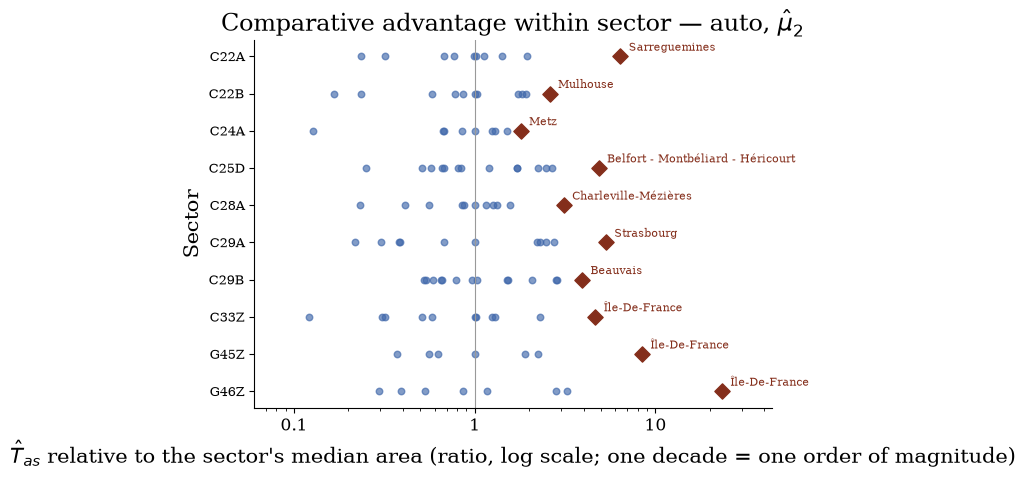

,sector,area,area_code,T,log_T_dev,log10_T_dev,rank,is_reference,n_cells
0,C22A,Île-De-France,1100,0.701017,-0.011566,-0.005023,6,False,11
1,C22A,Beauvais,2207,1.382199,0.667333,0.289819,2,False,4
2,C22A,Rouen,2307,0.225749,-1.144674,-0.497126,9,False,4
3,C22A,Sarreguemines,4110,4.536073,1.855719,0.805928,1,False,3
4,C22A,Vesoul,4309,0.717422,0.011566,0.005023,5,False,7
5,C22A,Angers,5205,0.479609,-0.391126,-0.169864,8,False,20
6,C22A,Le Mans,5213,0.543799,-0.265519,-0.115313,7,False,11
7,C22A,Rennes,5312,0.795064,0.114324,0.049650,4,False,8
8,C22A,Valence,8208,1.000000,0.343657,0.149248,3,True,34
9,C22A,Annecy,8218,0.167384,-1.443805,-0.627037,10,False,11


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


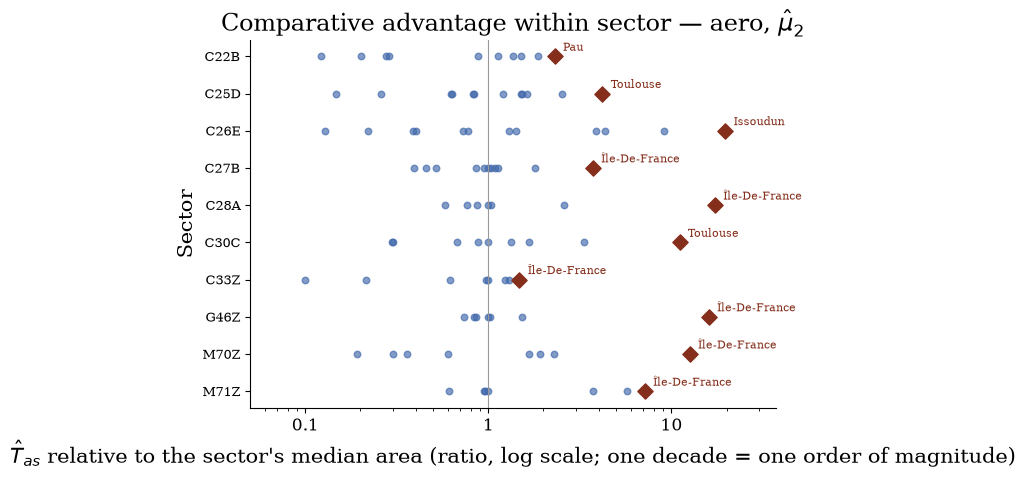

,sector,area,area_code,T,log_T_dev,log10_T_dev,rank,is_reference,n_cells
0,C22B,Roissy - Sud Picardie,0056,0.133001,-1.605802,-0.697391,9,False,50
1,C22B,Toulouse,0061,0.585052,-0.124459,-0.054052,6,False,14
2,C22B,Île-De-France,1100,0.904628,0.311364,0.135223,4,False,12
3,C22B,Issoudun,2408,0.750410,0.124459,0.054052,5,False,9
4,C22B,Cholet,5206,1.000000,0.411595,0.178753,3,True,19
5,C22B,Bordeaux,7204,0.182930,-1.287059,-0.558963,8,False,8
6,C22B,Pau,7214,1.524525,0.833278,0.361888,1,False,4
7,C22B,Valence,8208,0.190381,-1.247131,-0.541622,7,False,32
8,C22B,Montluçon,8301,0.080622,-2.106395,-0.914796,10,False,25
9,C22B,Marseille - Aubagne,9310,1.230412,0.618944,0.268804,2,False,4


In [98]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_frame(data).head(12))


## Test 2 — what is that inequality worth in distance?

The two forces are commensurable on a log scale, so an edge in comparative advantage can be
quoted in kilometres. A gap of $\Delta$ in $\log T$ is offset by a distance ratio of
$\exp\!\big(\Delta/(\theta\alpha)\big)$: how many times further from a buyer a region of the
favoured area may sit than a competing region of the other area, and still win.

That number is only meaningful against the distances the geography actually offers, so it
is compared with two benchmarks, both computed on **cell-to-buyer** distances:

* `geo_log_spread` — the *typical* spread, p90 − p10 of $\log d$ across the regions
  competing for a given buyer, averaged over buyers with their purchase weights. Clearing
  it means the edge beats the distances a buyer ordinarily faces;
* `geo_log_range` — the *extreme* spread, pooled max − min. It is anchored at the
  own-region cell, so one degenerate observation sets it: clearing it means no location in
  the country offsets the edge and the area supplies every buyer.

Both benchmarks are averages of a distribution, which is what Test 3 then removes.


In [99]:
# Test 2 — the edge in distance units, against the distances the geography offers.
from matplotlib.ticker import LogFormatterSciNotation
def ca_distance_equivalence(data):
    """
    How much distance a comparative-advantage gap is worth, against how much distance the
    country actually offers.

    `equiv_log_d = Delta log T / (theta*alpha)` is the log distance ratio that exactly
    offsets the gap between the top area and the median one — how much further from a
    buyer a REGION of the top area may sit than a competing REGION of the median area.
    It is compared with two benchmarks, both computed on cell-to-buyer distances:

      `geo_log_range`  the EXTREME spread, pooled max - min of log distance across all
                       competing cells and buyers. Anchored at the own-region cell, so
                       one degenerate observation sets it: it is the largest gap the
                       geography could ever offer;
      `geo_log_spread` the TYPICAL spread: p90 - p10 of log distance across the cells
                       competing for a given buyer, averaged over buyers with their
                       purchase weights.

    These two are averages over a distribution. `ca_win_margin` does the same comparison
    exactly, buyer by buyer, and is the one to quote; this table is the summary version.
    """
    geom = sourcing_geometry(data)
    ta = geom["theta"] * geom["alpha"]
    caf = comparative_advantage_frame(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        name = data["sector_names"][s]
        sub = caf[caf["sector"] == name].sort_values("rank")
        if sub.empty:
            continue
        logT = np.log(np.maximum(sub["T"].to_numpy(), 1e-300))
        d_top_med = float(logT[0] - np.median(logT))
        d_top_2nd = float(logT[0] - logT[1]) if logT.size > 1 else np.nan
        ld = np.log(blk["distance"])
        geo_range = float(ld.max() - ld.min())
        per_buyer = np.percentile(ld, 90, axis=0) - np.percentile(ld, 10, axis=0)
        geo_spread = float(per_buyer @ _buyer_weights(data))
        equiv = d_top_med / ta if ta > 0 else np.inf
        rows.append({
            "sector": name, "top_area": sub["area"].iloc[0], "n_areas": len(sub),
            "dlogT_top_vs_median": d_top_med, "dlogT_top_vs_2nd": d_top_2nd,
            "equiv_log_d": equiv,
            "equiv_distance_ratio": float(np.exp(min(equiv, 700))),
            "geo_log_range": geo_range, "geo_log_spread": geo_spread,
            "CA_beats_any_geography": bool(equiv > geo_range),
            "CA_beats_typical_geography": bool(equiv > geo_spread),
        })
    df = _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)
    df.attrs["theta_alpha"] = ta
    return df

def plot_ca_distance_equivalence(data, figsize=None, save_to=None, reference_km=1.0):
    """
    What the top area's comparative-advantage edge is worth, in kilometres.

    One POINT per sector, on a LOG x axis. The edge is a RATIO --
    `exp(Delta log T / (theta*alpha))` is the factor by which a region of the top area
    may be further from a buyer than a competing region of the median area and still
    win. With `reference_km = 1` the point IS that factor read as kilometres:

        equiv_km = exp(Delta log T / (theta * alpha))

    Read it as: a supplier of the top area wins a buyer at that distance against a
    median area's supplier sitting one kilometre away. The axis is logarithmic because
    theta*alpha is small, so the factor spans orders of magnitude across sectors.

    A point rather than a bar because the quantity is a RATIO on a log axis: a bar's
    length is read against its origin, and on a log axis that origin is arbitrary (it is
    wherever the axis happens to start), so the bar encodes the axis limits as much as
    the number. A point encodes only its position, which is the whole of the content.

    Each point is NAMED with its TOP AREA -- the attraction area holding the edge, by its
    anchor commuting zone -- in the same form test 1 names it, beside the mark rather than
    on the axis. Without it the figure says how large the edge is and not whose it is, and
    that name is the first thing a reader of the table looks up; beside the point it is
    read WITH the number, and the y axis stays a plain list of sectors.

    The dashed line is the BILATERAL MEDIAN cell-to-buyer distance -- the distance a
    typical supplier-buyer link actually spans in this industry. It is drawn for scale
    only: it is NOT the anchor of the bars, and a bar exceeding it does not by itself
    establish that comparative advantage beats geography. Test 3 (`ca_win_margin`) is
    the buyer-by-buyer comparison that does.
    """
    from matplotlib.ticker import LogFormatterSciNotation, LogLocator, NullFormatter

    df = ca_distance_equivalence(data)[::-1]        # A129-code order, top to bottom
    geom = sourcing_geometry(data)

    # Median over all cell-buyer pairs, pooled across sectors: a scale benchmark, not an
    # anchor. Unweighted, so each buyer counts in proportion to the cells competing for
    # it rather than to its purchases.
    med = [float(np.median(blk["distance"])) for blk in geom["by_sector"].values()]
    median_km = float(np.mean(med)) if med else np.nan

    km = reference_km * np.exp(np.minimum(df["equiv_log_d"].to_numpy(float), 700.0))
    y = np.arange(len(df))

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.62))
    ax.plot(km, y, linestyle="none", marker="o", markersize=7, color=reference_color,
            markeredgecolor="black", markeredgewidth=0.5)
    for yi, (x_i, area) in enumerate(zip(km, df["top_area"].astype(str))):
        ax.annotate(area, (x_i, yi), fontsize=8, xytext=(6, 4),
                    textcoords="offset points", color=reference_color)
    ax.set_xscale("log")
    ax.set_ylim(-0.6, len(df) - 0.4)

    if np.isfinite(median_km) and median_km > 0:
        ax.axvline(median_km, color="black", ls="dashed", lw=1.0, alpha=0.7)
        # anchored to the axis top and set to the LEFT of the line: with no title there
        # is no margin above, and the line sits near the right edge, so a label placed
        # to its right runs off the figure
        ax.text(median_km, ax.get_ylim()[1],
                f"{median_km:,.0f} km ",
                fontsize=8, va="top", ha="right", color="0.3")

    fmt = LogFormatterSciNotation(base=10.0)
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_formatter(NullFormatter())

    # Limits must now bracket the bars AND the benchmark line: the line is no longer the
    # anchor, so nothing guarantees it falls inside the range the bars span.
    finite = km[np.isfinite(km) & (km > 0)]
    anchors = [v for v in (float(finite.min()) if finite.size else np.nan, median_km)
               if np.isfinite(v) and v > 0]
    if anchors:
        ax.set_xlim(left=min(anchors) * 0.5)
    if finite.size and np.isfinite(median_km):
        # room for the NAME, not just for the number: the annotation runs to the right of
        # the widest point, and at x2 that point sits ~90% across and its label overhangs
        # the frame
        ax.set_xlim(right=max(float(finite.max()), median_km) * 4.0)

    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("Distance (km)")
    ax.grid(axis="x", which="major", linestyle="dashed", alpha=0.4)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


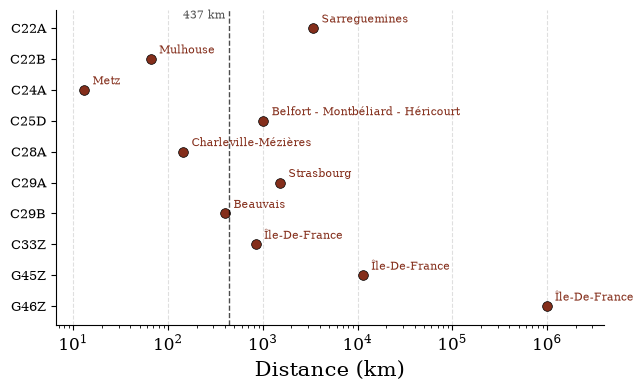

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22A,Sarreguemines,10,1.855719,1.188386,8.129536,3393.225449,4.510434,1.538358,True,True
C22B,Mulhouse,11,0.955204,0.303019,4.184562,65.664709,4.533789,1.350025,False,True
C24A,Metz,9,0.586143,0.180975,2.567777,13.036811,4.533789,1.342422,False,True
C25D,Belfort - Montbéliard - Héricourt,14,1.579761,0.597289,6.920621,1012.948630,4.771428,1.528611,True,True
C28A,Charleville-Mézières,11,1.135484,0.691776,4.974329,144.651759,4.552407,1.367805,True,True
C29A,Strasbourg,11,1.672087,0.666924,7.325082,1517.898810,4.787456,1.272539,True,True
C29B,Beauvais,14,1.368051,0.317779,5.993161,400.679152,4.745919,1.528344,True,True
C33Z,Île-De-France,11,1.537396,0.707666,6.735026,841.365210,4.533789,1.365123,True,True
G45Z,Île-De-France,7,2.131719,1.328828,9.338638,11368.907837,4.536379,1.381816,True,True


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


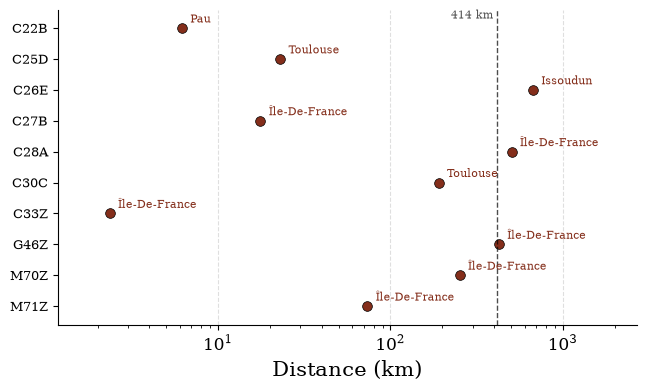

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22B,Pau,10,0.833278,0.214334,1.819711,6.170076,4.434990,1.406121,False,True
C25D,Toulouse,12,1.434649,0.503993,3.132986,22.942388,5.647328,1.413060,False,True
C26E,Issoudun,12,2.980589,0.770515,6.509008,671.160002,5.687365,1.489231,True,True
C27B,Île-De-France,11,1.313386,0.733093,2.868171,17.604793,5.647328,1.393490,False,True
C28A,Île-De-France,7,2.849522,1.900608,6.222785,504.105080,4.182868,1.277212,True,True
C30C,Toulouse,9,2.404526,1.197783,5.251002,190.757289,4.778641,1.400256,True,True
C33Z,Île-De-France,9,0.390775,0.046869,0.853374,2.347553,4.823596,1.585438,False,False
G46Z,Île-De-France,7,2.771921,2.347832,6.053318,425.522783,5.647328,1.475244,True,True
M70Z,Île-De-France,8,2.531519,1.701145,5.528330,251.723068,4.965071,1.481145,True,True


In [100]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_distance_equivalence(data))


## Test 3 — does the favoured area actually win?

Test 2 compares an average edge with an average spread. Neither average has to hold for any
particular buyer, so here the comparison is made exactly, **buyer by buyer and region by
region**, which is the form the inequality at the top of the section takes.

For each sector let $A^*$ be the area with the highest $\hat T$. For each downstream buyer
$r$, every competing cell $l$ carries a score $\log \psi_{lr} = \log T_{a(l)} - \theta\alpha
\log d_{lr}$, and $A^*$ takes the buyer iff its best cell outscores the best cell outside
it. Two numbers come out, both in log-distance units:

* **`mean_win_margin`** — $\big[\max_{l \in A^*} \log\psi - \max_{l \notin A^*}
  \log\psi\big]/(\theta\alpha)$: how much further from this buyer the favoured area's best
  region could be and still win. Positive means it wins; `share_buyers_won` is the
  purchase-weighted share of buyers it takes;
* **`mean_within_penalty`** — $\log d$ of the worst region of $A^*$ minus that of its best,
  for the same buyer. Inside an area $T$ cancels exactly, so this comparison is **pure
  geography**: it is the handicap the area's own spread imposes on its worst region, and it
  is the variation that identifies $\alpha$.

Putting the two side by side answers a question the area-level statement cannot even pose:
does it matter more *which area* a supplier belongs to, or *which region of it* it sits in?
When the second bar is longer than the first, the answer is the region — and that is
exactly the case in which letting regions deviate from their area's $T$ would change the
picture most.


In [101]:
# Test 3 — the exact comparison, buyer by buyer and region by region.

def ca_win_margin(data):
    """
    The decisive test, buyer by buyer and REGION by region — no averaging of distances.

    For each sector, let A* be the area with the highest T. For each downstream buyer r,
    every competing cell l has score

        log psi_lr = log T_{a(l)} - theta*alpha*log d_{lr},

    so A* takes the buyer iff its best cell outscores the best cell OUTSIDE it. Two
    numbers come out of that comparison, both in LOG-DISTANCE units (divide by
    theta*alpha), which is what makes them readable:

      win_margin_r  = [max_{l in A*} score - max_{l not in A*} score] / (theta*alpha)
                      how much FURTHER the favoured area's best region could be from
                      this buyer and still win. Positive = it wins.
      within_penalty_r = log d(worst cell of A*) - log d(best cell of A*)
                      the handicap A*'s own geography imposes on its worst region. Inside
                      an area T cancels exactly, so this comparison is PURE DISTANCE —
                      it is the variation that identifies alpha, and it is invisible to
                      any statement written in terms of area-level distances.

    Both are averaged over buyers with their purchase weights. `share_buyers_won` is the
    purchase-weighted share of buyers the favoured area actually takes; comparing
    `mean_win_margin` with `mean_within_penalty` says whether belonging to the right area
    or sitting in the right region of it matters more.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    est_T = geom["T"]
    rows = []
    for s, blk in geom["by_sector"].items():
        act = np.flatnonzero(data["AA_ACTIVE"][s])
        if act.size == 0:
            continue
        top_area = int(act[np.argmax(est_T[s, act])])
        in_top = blk["areas"] == top_area
        if not in_top.any() or in_top.all():
            continue                       # no cross-area comparison to make
        score = blk["log_psi"]                                   # (n_cell, R_d)
        ld = np.log(blk["distance"])
        best_top = score[in_top].max(axis=0)
        best_out = score[~in_top].max(axis=0)
        margin = (best_top - best_out) / ta if ta > 0 else np.full_like(best_top, np.inf)
        penalty = ld[in_top].max(axis=0) - ld[in_top].min(axis=0)
        rows.append({
            "sector": data["sector_names"][s],
            "top_area": aa_display_names(data)[top_area],
            "n_cells_top_area": int(in_top.sum()),
            "share_buyers_won": float((margin > 0) @ w),
            "mean_win_margin": float(margin @ w),
            "min_win_margin": float(margin.min()),
            "mean_within_penalty": float(penalty @ w),
            "area_beats_own_geography": bool(float(margin @ w) > float(penalty @ w)),
        })
    df = pd.DataFrame(rows)
    return _by_sector_code(df.set_index("sector"), data) if len(df) else df


def plot_ca_win_margin(data, figsize=None, save_to=None):
    """
    The exact test, per sector: how much further the top area's best region could be from
    the average buyer and still win (bar), against the distance handicap that area's own
    geography already imposes on its worst region (marker). Both in log-distance units,
    so they are directly comparable — a bar shorter than its marker is a sector where
    WHICH REGION of the favoured area a supplier sits in matters more than the area's
    edge itself.
    """
    df = ca_win_margin(data)
    if not len(df):
        raise ValueError("no sector has cells both inside and outside its top area — "
                         "there is no cross-area comparison to draw.")
    df = df[::-1]
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    ax.barh(y, df["mean_win_margin"],
            color=[reference_color if v else sim_color
                   for v in df["area_beats_own_geography"]], alpha=0.85,
            label="win margin of the top area (log distance it could give away)")
    ax.scatter(df["mean_within_penalty"], y, marker="|", s=220, color="black", zorder=3,
               label="within-area distance handicap (best to worst region of that area)")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    for i, (_, r) in enumerate(df.iterrows()):
        ax.annotate(f"{100 * r['share_buyers_won']:.0f}% of buyers",
                    (max(r["mean_win_margin"], 0.0), i), fontsize=8,
                    xytext=(4, -3), textcoords="offset points")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance")
    ax.set_title(f"Does the favoured area actually win? — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


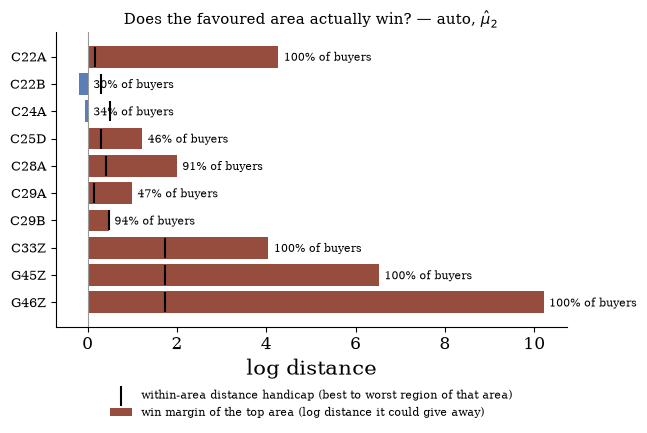

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22A,Sarreguemines,3,1.000000,4.267735,2.211579,0.163494,True
C22B,Mulhouse,4,0.301290,-0.195206,-2.066765,0.306439,False
C24A,Metz,7,0.340575,-0.064811,-2.147457,0.497587,False
C25D,Belfort - Montbéliard - Héricourt,3,0.459465,1.218489,-0.213569,0.296740,True
C28A,Charleville-Mézières,4,0.908475,1.994199,-0.106490,0.419986,True
C29A,Strasbourg,4,0.471849,0.988877,-0.154471,0.150576,True
C29B,Beauvais,3,0.944026,0.474431,-1.395903,0.466361,True
C33Z,Île-De-France,14,1.000000,4.046695,0.404516,1.722662,True
G45Z,Île-De-France,14,1.000000,6.521338,3.855291,1.722662,True


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


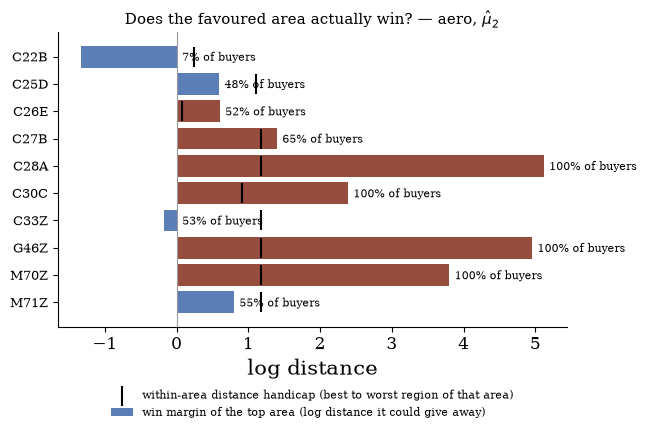

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22B,Pau,4,0.073753,-1.334527,-3.002795,0.242306,False
C25D,Toulouse,18,0.477527,0.589860,-1.409357,1.111834,False
C26E,Issoudun,2,0.516274,0.599860,-0.727389,0.079622,True
C27B,Île-De-France,11,0.649417,1.395943,-2.108064,1.179510,True
C28A,Île-De-France,11,1.000000,5.116175,1.216319,1.175907,True
C30C,Toulouse,6,1.000000,2.387242,0.357747,0.917569,True
C33Z,Île-De-France,12,0.534039,-0.169212,-3.606639,1.179510,False
G46Z,Île-De-France,12,1.000000,4.953941,2.192965,1.179510,True
M70Z,Île-De-France,12,1.000000,3.798925,0.042871,1.179510,True


In [102]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_win_margin(
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_win_margin(data))


## Test 4 — which force disperses the competition more?

Tests 2 and 3 ask who wins. This one asks which force is doing the work, and it is an
identity rather than a regression. Because $\log\psi$ is a sum, its dispersion across the
cells competing for a given buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

Variances are taken **across cells at a fixed buyer** — the competition the model actually
runs — and then averaged over buyers with their purchase weights.
$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like size of the two pulls, and `ratio_CA_over_distance` above one says
comparative advantage disperses the competition more than geography does.

The three shares sum to one by construction. The covariance share is the interesting one
and the one not to over-read — which is what Test 5 is for.


In [103]:
# Test 4 — the exact variance decomposition of log psi across competing cells.

def ca_variance_decomposition(data):
    """
    The exact split of the dispersion of log psi across competing cells.

    For a given buyer r, log psi_{l,r} = log T_l - theta*alpha*log d_{l,r}, so

        Var_l(log psi) = Var_l(log T) + (theta*alpha)^2 Var_l(log d)
                         - 2*theta*alpha*Cov_l(log T, log d)

    holds with no approximation. Variances are taken ACROSS CELLS at a fixed buyer —
    which is the competition the model actually runs — then averaged over buyers with
    their purchase weights. `sd_logT` against `sd_dist` is the like-for-like size of the
    two forces.

    The covariance term is NOT free of the estimator: T is the Sinkhorn image of the
    observed sourcing shares, which loads onto comparative advantage whatever distance
    takes away, so a positive Cov(log T, log d) — hence a negative contribution
    `share_covariance` — is the expected reading. `ca_covariance_benchmark` splits it.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        ld = np.log(blk["distance"])                       # (n_cell, R_d)
        v_T = float(np.var(logT))
        v_d = np.var(ld, axis=0)                           # per buyer
        cov = np.array([np.cov(logT, ld[:, r], bias=True)[0, 1] for r in range(ld.shape[1])])
        v_psi = v_T + (ta ** 2) * v_d - 2 * ta * cov
        vd_bar, cov_bar, vpsi_bar = float(v_d @ w), float(cov @ w), float(v_psi @ w)
        rows.append({
            "sector": data["sector_names"][s],
            "sd_logT": np.sqrt(v_T),
            "sd_dist": ta * np.sqrt(vd_bar),
            "ratio_CA_over_distance": np.sqrt(v_T) / (ta * np.sqrt(vd_bar))
            if vd_bar > 0 else np.inf,
            "share_CA": v_T / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_distance": (ta ** 2) * vd_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_covariance": -2 * ta * cov_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "sd_log_psi": np.sqrt(vpsi_bar),
        })
    return _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)


In [104]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_variance_decomposition(data))


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22A,0.646854,0.143408,4.510577,0.990982,0.048708,-0.039690,0.649790
C22B,0.869439,0.131992,6.587063,0.890662,0.020527,0.088811,0.921262
C24A,0.992669,0.146356,6.782546,0.853673,0.018557,0.127770,1.074382
C25D,0.944432,0.148158,6.374488,0.846555,0.020834,0.132612,1.026462
C28A,0.743101,0.133378,5.571392,0.819060,0.026387,0.154553,0.821088
C29A,1.004207,0.132223,7.594825,0.870090,0.015084,0.114826,1.076568
C29B,0.580684,0.152631,3.804497,0.768229,0.053076,0.178695,0.662513
C33Z,0.974689,0.133501,7.300991,0.879691,0.016503,0.103806,1.039204
G45Z,0.868850,0.135668,6.404234,0.947740,0.023108,0.029152,0.892484


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22B,0.937202,0.276643,3.387771,0.865898,0.075446,0.058656,1.007163
C25D,1.056287,0.270998,3.897773,0.875221,0.057608,0.067170,1.129076
C26E,1.360519,0.306745,4.435344,0.878195,0.044641,0.077164,1.451808
C27B,0.545449,0.272573,2.001110,0.712436,0.177911,0.109653,0.646221
C28A,0.900124,0.256494,3.509334,0.849872,0.069009,0.081120,0.976395
C30C,1.204839,0.313906,3.838219,0.852162,0.057845,0.089994,1.305173
C33Z,0.913156,0.309986,2.945801,0.889487,0.102502,0.008011,0.968222
G46Z,0.759738,0.287425,2.643252,0.783989,0.112210,0.103801,0.858042
M70Z,1.231424,0.293456,4.196281,0.861462,0.048922,0.089616,1.326752


## Test 5 — is the covariance term about the economy or about the estimator?

Under `--profile_T=true`, $\hat T$ is not a free estimate: it is the Sinkhorn image that
makes the model reproduce the *observed* sourcing shares at the current $\alpha$. At the
area level,

$$\log \hat T_{as} \;=\; \log \hat\gamma^{\,emp}_{as} \;-\; \log M_{as}(\alpha) + \text{const},
\qquad M_{as}(\alpha) = \sum_r \omega_r\, d_{ar}^{-\theta\alpha}/\Phi_{sr},$$

with $M$ the market-access term. $M$ falls with distance to markets, so a remote area that
nonetheless sells must be handed a **higher** $T$: the inversion loads onto comparative
advantage exactly what distance takes away. Hence, cell by cell,

$$\operatorname{Cov}(\log \hat T, \log d) \;=\; \underbrace{\operatorname{Cov}(\log \hat\gamma^{\,emp}, \log d)}_{\text{the gradient in the data}} \;-\; \underbrace{\operatorname{Cov}(\log M, \log d)}_{<\,0,\ \text{growing in } \alpha},$$

so the expected sign of $\operatorname{Cov}(\log \hat T, \log d)$ is **positive** unless the
observed sourcing shares fall with distance fast enough to outweigh the correction — and a
positive covariance makes Test 4's `share_covariance` **negative**: the two forces offset,
and $\operatorname{Var}(\log\psi)$ is smaller than the sum of the two separate variances.
That is the inversion's signature, not a finding about the economy, and reading Test 4
without it invites calling comparative advantage "large" when what is large is the
compensation for remoteness.

`ca_covariance_benchmark` reports the two terms separately, taking
$\log M = \log\hat\gamma^{emp} - \log\hat T$ as the residual (exact up to the per-sector
constant, which a covariance drops), so which one drives the total is a number. At
$\alpha = 0$ the market-access term is common within a sector and must vanish, leaving
$\operatorname{Cov}(\log\hat T, \log d) = \operatorname{Cov}(\log\hat\gamma, \log d)$ — the
limiting case to check the split against.


In [105]:
# Test 5 — where the covariance term comes from, given how T was obtained.

def ca_covariance_benchmark(data):
    """
    Where the covariance term of the decomposition comes from — the data, or the
    inversion.

    Under profiling, T is chosen so the model reproduces the observed sourcing shares:
    at the area level, log T_a = log gamma^emp_a - log M_a(alpha) + const, with M the
    market-access term. Hence, cell by cell,

        Cov(log T, log d) = Cov(log gamma^emp, log d) - Cov(log M, log d),

    and since M falls with distance to markets the second term is negative, i.e. the
    inversion MECHANICALLY pushes Cov(log T, log d) up: a remote area that nonetheless
    sells must be handed a higher T. This function reports the two pieces, taking
    log M = log gamma^emp - log T as the residual (exact up to the per-sector constant,
    which drops out of a covariance). Read `cov_gamma` as the gradient in the data and
    `-cov_M` as what the inversion added on top of it.

    At alpha = 0 the market-access term is common within a sector and `cov_M` must
    vanish, leaving `cov_T == cov_gamma` — the limiting case to check the split against.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    emp_gamma_aa, aa_of_ze = data["emp_gamma_aa"], data["aa_of_ze"]
    rows = []
    for s, blk in geom["by_sector"].items():
        cells, areas = blk["cells"], blk["areas"]
        g = emp_gamma_aa[s, areas]
        keep = (g > 0) & (blk["T_cell"] > 0)
        if keep.sum() < 2:
            continue
        logT = np.log(blk["T_cell"][keep])
        logG = np.log(g[keep])
        logM = logG - logT                                  # the market-access residual
        ld = np.log(blk["distance"][keep])
        def _cov(x):
            return float(np.array([np.cov(x, ld[:, r], bias=True)[0, 1]
                                   for r in range(ld.shape[1])]) @ w)
        cov_T, cov_G, cov_M = _cov(logT), _cov(logG), _cov(logM)
        sd_ld = float(np.sqrt(np.array([np.var(ld[:, r]) for r in range(ld.shape[1])]) @ w))
        rows.append({
            "sector": data["sector_names"][s],
            "cov_T": cov_T, "cov_gamma": cov_G, "cov_M": cov_M,
            "check_gamma_minus_M": cov_G - cov_M - cov_T,      # 0 by construction
            "corr_T_d": cov_T / (np.std(logT) * sd_ld) if sd_ld > 0 and np.std(logT) > 0 else np.nan,
            "corr_gamma_d": cov_G / (np.std(logG) * sd_ld) if sd_ld > 0 and np.std(logG) > 0 else np.nan,
            "share_covariance": np.nan,
        })
    df = pd.DataFrame(rows).set_index("sector")
    vd = ca_variance_decomposition(data)
    df["share_covariance"] = vd["share_covariance"].reindex(df.index)
    df.attrs["theta_alpha"] = ta
    return _by_sector_code(df, data)


In [106]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_covariance_benchmark(data))


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22A,0.036707,0.234161,0.197453,-4.857226e-17,0.090328,0.390179,-0.039690
C22B,-0.165104,0.070128,0.235232,-8.326673e-17,-0.328410,0.169587,0.088811
C24A,-0.323050,-0.153344,0.169706,5.551115e-17,-0.507575,-0.336166,0.127770
C25D,-0.306049,0.087636,0.393685,0.000000e+00,-0.499277,0.187015,0.132612
C28A,-0.228234,0.024428,0.252662,-2.775558e-17,-0.525649,0.072531,0.154553
C29A,-0.291505,-0.040101,0.251404,-5.551115e-17,-0.501145,-0.106569,0.114826
C29B,-0.171801,0.108043,0.279844,-5.551115e-17,-0.442475,0.247324,0.178695
C33Z,-0.245554,0.068004,0.313558,-5.551115e-17,-0.430767,0.112579,0.103806
G45Z,-0.050862,0.283052,0.333914,1.734723e-16,-0.098495,0.343403,0.029152


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22B,-0.064967,-0.023118,0.041850,1.387779e-17,-0.114744,-0.056769,0.058656
C25D,-0.093499,-0.042733,0.050766,1.942890e-16,-0.149571,-0.085350,0.067170
C26E,-0.177588,-0.138924,0.038665,-2.775558e-17,-0.194859,-0.173421,0.077164
C27B,-0.049999,0.009147,0.059147,0.000000e+00,-0.153998,0.018657,0.109653
C28A,-0.084442,-0.013714,0.070728,4.163336e-17,-0.167482,-0.023909,0.081120
C30C,-0.167390,-0.167486,-0.000096,5.551115e-17,-0.202670,-0.215595,0.089994
C33Z,-0.008200,-0.008214,-0.000014,-1.231654e-16,-0.013265,-0.011438,0.008011
G46Z,-0.083445,-0.019798,0.063646,5.551115e-17,-0.174984,-0.040829,0.103801
M70Z,-0.172245,-0.136585,0.035660,-5.551115e-17,-0.218264,-0.191382,0.089616


## Test 6 — how much distance is comparative advantage actually buying?

Tests 4 and 5 measure the *dispersion* of $\log \hat T$ and its covariance with distance
with every competing cell counted once. Neither is the statistic that governs the
counterfactual of the amplification section, and the difference matters: two industries
whose $\hat T$ is equally dispersed can have completely different counterfactuals.

Write the allocation as a homotopy in the strength of comparative advantage,

$$\rho_{lr}(t) \;\propto\; T_{l}^{\,t}\, d_{lr}^{-\theta\alpha},
\qquad t = 1 \text{ estimated}, \quad t = 0 \text{ comparative advantage equalised},$$

which is a exponential family in $t$ with sufficient statistic $\log T$. Differentiating
the mean of $\log d$ under it gives, buyer by buyer and with no approximation,

$$\frac{d}{dt}\,\mathbb{E}_{\rho(t)}[\log d] \;=\; \operatorname{Cov}_{\rho(t)}(\log T, \log d).$$

So **what moves the average sourcing distance when comparative advantage is switched off
is a covariance, not a variance**. Dispersion only bounds it,
$|\operatorname{Cov}| \le \operatorname{sd}(\log T)\operatorname{sd}(\log d)$: a $\hat T$
that varies widely but is uncorrelated with the buyer's geography reallocates sourcing
across cells *without sending it further away*. What makes the dispersion bite is whether
capability sits where the buyers are.

Integrating the identity from $t=1$ to $t=0$ gives the whole effect of the `Distance only`
regime on the log sourcing distance, in closed form — the same number the amplification
section obtains by reallocating euros, which is what `check_identity` gates. Read
`corr_rho_T_d` as the **alignment** of comparative advantage with the buyers, and
`dlog_d_no_CA` as what that alignment is worth in distance.


In [107]:
# Test 6 — how much sourcing DISTANCE comparative advantage is buying, in kilometres.

def _representative_buyer(data, geom=None):
    """
    The buyer the alignment figure is drawn for: the one of MEDIAN sourcing reach.

    Per buyer, take the sourcing-weighted average distance `d_rs` within each sector and
    average across sectors; the representative buyer sits at the median of that. It is a
    buyer the model actually sources for, and it is neither the most local nor the most
    remote — which is what makes it representative rather than flattering.
    """
    geom = sourcing_geometry(data) if geom is None else geom
    blocks = [b for b in geom["by_sector"].values() if b["cells"].size >= 2]
    if not blocks:
        raise ValueError("no sector with two competing cells; nothing to draw")
    reach = np.mean([(b["rho"] * b["distance"]).sum(axis=0) for b in blocks], axis=0)
    order = np.argsort(reach)
    return int(order[order.size // 2])


def alignment_frame(data, buyer=None, geom=None):
    """
    The panel behind the alignment regression: one row per (sector, buyer, competing cell).

    Columns are in the units the section reports. `distance_km` is the cell's distance to
    that buyer IN KILOMETRES, not its log — the object of interest is
    `d_{rs} = sum_l rho_lrs d_lr`, the average distance the euro travels, and a statement
    about `d_rs` has to be built out of `d`, not out of `log d`. `log_T` stays in logs
    because comparative advantage enters the allocation multiplicatively and is identified
    only up to a per-sector scale, which the fixed effect absorbs.

    `weight` is the sourcing probability `rho_lrs` times the buyer's purchase weight, so a
    weighted mean over the panel is the sourcing-weighted average the model performs and
    not an average over the places that could in principle have supplied.

    `buyer` selects a single downstream region (the figure); `None` keeps them all (the
    regression). The panel then has `n_cell x n_buyer` rows per sector, which is large but
    is what a within-(sector x buyer) estimand requires. `weight` is normalised to sum to
    one over the panel, so every sector carries equal weight and every buyer its purchase
    weight; the slope of a WLS is invariant to that scale, but the reported dispersions
    are not.
    """
    geom = sourcing_geometry(data) if geom is None else geom
    w = _buyer_weights(data)
    buyers = range(w.size) if buyer is None else (int(buyer),)
    aa_names = aa_display_names(data)
    frames = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        name = data["sector_names"][s]
        for r in buyers:
            p = blk["rho"][:, r]
            tot = p.sum()
            if not np.isfinite(tot) or tot <= 0:
                continue
            frames.append(pd.DataFrame({
                "sector": name,
                "buyer": aa_names[r] if r < len(aa_names) else str(r),
                "group": f"{name}|{r}",
                "ze_index": blk["cells"] + 1,
                "area": [aa_names[a] for a in blk["areas"]],
                "log_T": np.log(np.maximum(blk["T_cell"], 1e-300)),
                "distance_km": blk["distance"][:, r],
                "rho": p / tot,
                "weight": (p / tot) * w[r],
            }))
    if not frames:
        raise ValueError("no (sector, buyer) block with two competing cells")
    df = pd.concat(frames, ignore_index=True)
    # rho sums to one per (sector, buyer) and the purchase weights sum to one across
    # buyers, so each SECTOR carries total weight one: dividing by their number makes
    # `weight` a probability over the whole panel and states the aggregation — every
    # sector counts equally, every buyer in proportion to its purchases.
    n_sec = df["sector"].nunique()
    df["weight"] = df["weight"] / n_sec
    df.attrs["n_sectors"] = n_sec
    return df


def alignment_regression(data, frame=None, by_sector=False, cluster="buyer"):
    """
    Where comparative advantage pulls sourcing, as one weighted regression.

        distance_km = a_{s,r} + b * log T_hat + e,      weights rho_lrs * omega_r

    fitted by `pyfixest.feols` with a sector x downstream-region fixed effect. `b` is in
    KILOMETRES per log point of comparative advantage: how much closer to the buyer a
    supplier is, per unit of the capability that wins it the sale.

    The fixed effect is what makes the estimand the right one. The identity behind the
    counterfactual holds for ONE sector and ONE buyer at a time, so the object is a
    within-(sector x buyer) slope; absorbing that effect is exactly the restriction, and
    the sourcing weights are what make it the average the model performs rather than an
    average over candidate locations. Both are specification decisions, not tuning: run it
    unweighted and the same regression answers a different question, about the cells
    rather than about the sourcing.

    `by_sector=True` returns one row per sector, fitted with a buyer fixed effect inside
    that sector — the numbers `ca_distance_leverage` reports. A sector whose comparative
    advantage takes a single value is collinear with its own fixed effect and is returned
    as NaN rather than dropped silently.

    The standard error is reported because the library returns it, but it has no sampling
    interpretation here: `T_hat` and `d` are model objects, not a sample, so the dispersion
    around this line is the spread of an estimated deterministic allocation.
    """
    fr = alignment_frame(data) if frame is None else frame

    def _fit(sub, fe):
        if sub["log_T"].nunique() < 2:
            return {"slope_km_per_logT": np.nan, "se": np.nan,
                    "n_obs": len(sub), "n_groups": sub[fe].nunique()}
        fit = pf.feols(f"distance_km ~ log_T | {fe}", data=sub, weights="weight",
                       weights_type="aweights",
                       vcov=None if cluster is None else {"CRV1": cluster})
        return {"slope_km_per_logT": float(fit.coef()["log_T"]),
                "se": float(fit.se()["log_T"]),
                "n_obs": len(sub), "n_groups": sub[fe].nunique()}

    if not by_sector:
        out = _fit(fr, "group")
        out["sd_rho_logT"] = _weighted_sd(fr, "log_T")
        out["sd_rho_distance_km"] = _weighted_sd(fr, "distance_km")
        return pd.Series(out, name=f"{data['industry']}, mu = {data['mu']}")

    rows = {}
    for name, sub in fr.groupby("sector", sort=False):
        r = _fit(sub, "buyer")
        r["sd_rho_logT"] = _weighted_sd(sub, "log_T")
        r["sd_rho_distance_km"] = _weighted_sd(sub, "distance_km")
        rows[name] = r
    return _by_sector_code(pd.DataFrame(rows).T, data)


def _weighted_sd(fr, col):
    """Sourcing-weighted sd of `col`, demeaned WITHIN (sector x buyer) as the FE does."""
    w = fr["weight"].to_numpy(float)
    x = fr[col].to_numpy(float)
    g = fr["group"].to_numpy()
    tot = pd.Series(w).groupby(g).transform("sum").to_numpy()
    mu = pd.Series(w * x).groupby(g).transform("sum").to_numpy() / np.maximum(tot, 1e-300)
    return float(np.sqrt((w @ (x - mu) ** 2) / w.sum())) if w.sum() > 0 else np.nan


def ca_distance_leverage(data, n_grid=201, reg=None):
    """
    What equalising comparative advantage does to the average sourcing distance, in km.

    The object is `d_{rs} = sum_l rho_lrs d_lr`, the distance the average euro travels
    from downstream region `r` when it buys product `s`. Dialling comparative advantage
    down along `rho_l(t) ∝ T_l^t d_lr^{-theta*alpha}` moves it at exactly the rate

        d/dt E_{rho(t)}[d] = Cov_{rho(t)}(log T, d),

    an exponential-family identity, so the whole effect of the `Distance only` regime is
    the path integral of a covariance between capability and distance IN KILOMETRES. It is
    a covariance, not a variance: a `T_hat` that varies widely but is uncorrelated with the
    buyer's geography reallocates sourcing across regions without sending the euro one
    kilometre further.

    `delta_km` is that effect, computed as two evaluations of a closed form, and the
    amplification section reaches the same object by reallocating euros — agreement is a
    cross-check of two independent routes. `check_identity` re-derives it by integrating
    the covariance over the grid, so it gates the derivative FORMULA against the mean it
    differentiates, up to the trapezoid error of the grid; it is read relative to the
    effect, not against a fixed zero.

    `slope_km_per_logT` comes from `alignment_regression`, i.e. from `pyfixest`, and is the
    line the alignment figure draws. It is the covariance divided by the sourcing-weighted
    variance of `log T_hat`, so it is the same statistic in the units the figure can show.
    """
    trapz = getattr(np, "trapezoid", None) or np.trapz
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    ts = np.linspace(0.0, 1.0, int(n_grid))
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))[:, None]   # (n_cell, 1)
        d_km = blk["distance"]                                      # (n_cell, R_d), km
        base = -ta * np.log(d_km)

        def allocate(t):
            z = t * logT + base
            p = np.exp(z - z.max(axis=0, keepdims=True))
            return p / p.sum(axis=0, keepdims=True)

        cov_t, d_t = np.empty(ts.size), np.empty(ts.size)
        for k, t in enumerate(ts):
            p = allocate(t)
            mT, md = (p * logT).sum(0), (p * d_km).sum(0)
            cov_t[k] = ((p * logT * d_km).sum(0) - mT * md) @ w     # km per log point
            d_t[k] = md @ w                                         # km

        d_direct = float(d_t[0] - d_t[-1])          # equalising T: t = 1 -> 0
        d_path = float(-trapz(cov_t, ts))
        rows.append({
            "sector": data["sector_names"][s],
            "d_km": float(d_t[-1]),
            "d_km_no_CA": float(d_t[0]),
            "delta_km": d_direct,
            "cov_rho_T_d_km": float(cov_t[-1]),
            "check_identity": d_direct - d_path,
        })
    df = _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)
    reg = alignment_regression(data, by_sector=True) if reg is None else reg
    for col in ("slope_km_per_logT", "sd_rho_logT", "sd_rho_distance_km"):
        df[col] = pd.to_numeric(reg[col].reindex(df.index), errors="coerce")
    df = df[["d_km", "d_km_no_CA", "delta_km", "slope_km_per_logT",
             "cov_rho_T_d_km", "sd_rho_logT", "sd_rho_distance_km", "check_identity"]]
    df.attrs["theta_alpha"] = ta
    return df


def ca_leverage_report(data, lev=None):
    """
    The one-line reading of Test 6: what the alignment is worth in kilometres.

    Prints the sector medians, because the sector distribution is what the paper quotes,
    and flags a broken identity rather than leaving it to be found by eye.
    """
    lev = ca_distance_leverage(data) if lev is None else lev
    if lev.empty:
        print("  no sector with two competing cells; nothing to report")
        return lev
    scale = float(np.maximum(np.abs(lev["delta_km"]).max(), 1e-9))
    bad = float(np.max(np.abs(lev["check_identity"]))) / scale
    print(f"[{data['industry']}, mu = {data['mu']}]  theta*alpha = "
          f"{lev.attrs['theta_alpha']:.3f}")
    print(f"  average sourcing distance d_rs = {lev['d_km'].median():.1f} km at the "
          f"sector median; equalising T takes it to {lev['d_km_no_CA'].median():.1f} km "
          f"({lev['delta_km'].median():+.1f} km)")
    print(f"  slope of distance on log T (pyfixest, sector x buyer FE, rho weights): "
          f"{lev['slope_km_per_logT'].median():+.1f} km per log point")
    print(f"  identity |direct - path| / effect = {bad:.2e}"
          + ("" if bad < 1e-5 else "   <-- INVESTIGATE: raise n_grid"))
    return lev


def plot_spatial_alignment(data, buyer=None, n_label=4, figsize=None, save_to=None,
                           frame=None):
    """
    Where comparative advantage pulls sourcing.

    Each dot is an upstream commuting zone competing to supply one downstream buyer:
    its comparative advantage on `x`, its DISTANCE TO THAT BUYER IN KILOMETRES on `y`,
    with the area of the dot given by the sourcing probability `rho_lr`. The picture
    therefore answers the question the counterfactual asks — not "how unequal is T" but
    "does the buyer's euro come from places that are productive AND close".

    The line is the fit `alignment_regression` reports for this buyer, so the slope the
    eye reads IS the number annotated on the panel: kilometres of sourcing distance per
    log point of comparative advantage. A downward line means the productive suppliers
    are the near ones and equalising `T` would push the euro outward; a flat line means
    comparative advantage is orthogonal to the buyer's geography and equalising it would
    move the euro nowhere.

    Both axes are deviations from their sourcing-weighted SECTOR mean, which is what the
    fixed effect removes: `T_hat` is identified only up to a per-sector scale, so a pooled
    cloud in levels would manufacture a slope out of the normalisation. The `n_label`
    areas taking the most sourcing are named.
    """
    fr = (alignment_frame(data, buyer=_representative_buyer(data) if buyer is None
                          else buyer) if frame is None else frame)
    reg = alignment_regression(data, frame=fr, cluster=None)
    w = fr["weight"].to_numpy(float)
    g = fr["sector"].to_numpy()
    def _dev(col):
        x = fr[col].to_numpy(float)
        tot = pd.Series(w).groupby(g).transform("sum").to_numpy()
        mu = pd.Series(w * x).groupby(g).transform("sum").to_numpy() / np.maximum(tot, 1e-300)
        return x - mu
    x, y = _dev("log_T"), _dev("distance_km")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.72))
    scale = w / w.max() if w.max() > 0 else w
    ax.scatter(x, y, s=18 + 320 * scale, color=reference_color, alpha=0.55,
               edgecolor="black", linewidth=0.4, zorder=2)
    b = reg["slope_km_per_logT"]
    if np.isfinite(b):
        xs = np.array([x.min(), x.max()])
        ax.plot(xs, b * xs, color="black", linewidth=1.4, zorder=3)
    ax.axhline(0.0, color="0.75", linewidth=0.8, zorder=1)
    ax.axvline(0.0, color="0.75", linewidth=0.8, zorder=1)

    if n_label:
        for _, r in fr.assign(_x=x, _y=y).nlargest(int(n_label), "weight").iterrows():
            ax.annotate(str(r["area"]), (r["_x"], r["_y"]), fontsize=8,
                        xytext=(6, 4), textcoords="offset points", color=reference_color)
    ax.annotate(rf"${b:+.0f}$ km per log point", (0.03, 0.05), xycoords="axes fraction",
                fontsize=9, color="0.25")
    ax.set_xlabel(r"Comparative advantage $\log \hat{T}$ (deviation)")
    ax.set_ylabel("Distance to the buyer (km, deviation)")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


# --- The alignment, buyer by buyer --------------------------------------------
#
# `ca_variance_decomposition` reports one covariance per SECTOR, already averaged
# over buyers with their purchase weights, and the paper quotes its median. That
# hides the fact the two industries actually differ on. A sector median of -0.47
# is consistent with every buyer facing the same mild alignment, and equally with
# half of them facing a strong one and half the opposite; those are different
# economies and they predict different counterfactuals. The object that separates
# them is the DISTRIBUTION of
#
#     rho_{rs} = Corr_l( log T_{a(l)s} , log d_{lr} )
#
# across (sector, buyer) pairs -- the same correlation the decomposition's
# co-location term is built from, kept disaggregated instead of averaged.
#
# Two conventions, both inherited rather than chosen. The correlation is taken
# ACROSS CELLS at a fixed buyer, which is the competition the model runs and is
# exactly `ca_variance_decomposition`'s convention, so the purchase-weighted mean
# of the covariances reported here reproduces that table's co-location term
# sector by sector (the gate asserts it). And it is in LOGS on both axes, which is
# what makes it the correlation the decomposition uses and a scale-free number:
# `T_hat` is identified only up to a per-sector scale, and a correlation is
# invariant to it. Test 6's kilometre covariance answers a different question --
# how far the euro moves -- and is not the same statistic.
#
# `weights="cell"` (the default) counts every competing cell once, which is the
# decomposition's convention. `weights="rho"` takes the correlation under the
# sourcing probabilities instead: that is the one appearing in the exponential-
# family identity, and the two come apart exactly where sourcing is concentrated.


def alignment_correlation(data, weights="cell"):
    """
    One row per (sector, downstream buyer): the correlation between comparative
    advantage and distance across the cells competing to supply that buyer.

    `corr` is the object; `cov`, `sd_logT` and `sd_logd` are the pieces it is built
    from, and `buyer_weight` is the buyer's share of purchases, so any aggregate
    quoted from this frame can be taken with the same weights the rest of the
    section uses. `weights` selects the measure the moments are taken under: "cell"
    (every competing cell once, the variance decomposition's convention) or "rho"
    (the sourcing probabilities, the convention of the identity in Section 5.1).
    """
    if weights not in ("cell", "rho"):
        raise ValueError(f"weights must be 'cell' or 'rho', not {weights!r}")
    geom = sourcing_geometry(data)
    w_buyer = _buyer_weights(data)
    lab = _region_labels(data).set_index("index")["ze2010_name"]
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))       # (n_cell,)
        ld = np.log(blk["distance"])                           # (n_cell, R_d)
        for r in range(ld.shape[1]):
            p = (blk["rho"][:, r] if weights == "rho"
                 else np.full(blk["cells"].size, 1.0 / blk["cells"].size))
            tot = p.sum()
            if not np.isfinite(tot) or tot <= 0:
                continue
            p = p / tot
            mT, md = float(p @ logT), float(p @ ld[:, r])
            cov = float(p @ ((logT - mT) * (ld[:, r] - md)))
            sT = float(np.sqrt(p @ (logT - mT) ** 2))
            sd = float(np.sqrt(p @ (ld[:, r] - md) ** 2))
            rows.append({
                "sector": data["sector_names"][s],
                "buyer": lab.get(int(geom["downstream"][r]), str(geom["downstream"][r])),
                "cov": cov,
                "corr": cov / (sT * sd) if sT > 0 and sd > 0 else np.nan,
                "sd_logT": sT,
                "sd_logd": sd,
                "buyer_weight": float(w_buyer[r]),
                "n_cells": int(blk["cells"].size),
            })
    df = pd.DataFrame(rows)
    df.attrs["weights"] = weights
    df.attrs["industry"] = data["industry"]
    df.attrs["theta_alpha"] = geom["theta"] * geom["alpha"]
    return df


def plot_alignment_correlation(datasets, weights="cell", bins=24, frames=None,
                               colors=None, figsize=None, save_to=None, annotate=True):
    """
    The distribution of the alignment correlation across (sector, buyer) pairs, one
    outline per industry.

    `datasets` is a sequence of `(display name, data)` pairs, so both industries land
    on ONE panel: the comparison is the point, and two separate figures would leave
    the reader to align two axes by eye.

    Three things are fixed rather than left to matplotlib, each because the comparison
    would otherwise not be one. The bin EDGES are computed once on the POOLED values
    and reused, so the two histograms sit on the same grid. Each industry is a STEP
    OUTLINE rather than filled bars, since two filled series overlap and whichever is
    drawn last wins. And the counts are NORMALISED to densities, because the two
    industries need not contribute the same number of (sector, buyer) pairs.

    Zero is marked, and it is the line that carries the paragraph: mass to the left is
    capability sitting near demand. The share of pairs on the wrong side of it is
    annotated per industry -- a median says how strong the alignment is, this says
    whether it is common to every buyer or an average over buyers pulled in opposite
    directions.
    """
    frs = (frames if frames is not None
           else {name: alignment_correlation(d, weights=weights) for name, d in datasets})
    pooled = np.concatenate([f["corr"].dropna().to_numpy() for f in frs.values()])
    if pooled.size == 0:
        raise ValueError("no (sector, buyer) pair with a finite correlation.")
    edges = np.histogram_bin_edges(pooled, bins=bins)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    palette = colors or {}
    default = [sim_color, toulouse_color, reference_color]
    for k, (name, fr) in enumerate(frs.items()):
        v = fr["corr"].dropna().to_numpy()
        col = palette.get(name, default[k % len(default)])
        ax.hist(v, bins=edges, density=True, histtype="step", linewidth=1.6,
                color=col, label=f"{name} (median {np.median(v):+.2f})")
        ax.axvline(np.median(v), color=col, linestyle=":", linewidth=1.0)
    ax.axvline(0.0, color="0.35", linewidth=0.9)
    ax.set_xlabel(r"$\mathrm{Corr}_l(\log \hat T_{a(l)s},\ \log d_{lr})$ "
                  "at one (sector, buyer)")
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    if annotate:
        txt = "\n".join(f"{name}: {float((fr['corr'] > 0).mean()):.0%} positive"
                        for name, fr in frs.items())
        ax.text(0.98, 0.97, txt, transform=ax.transAxes, fontsize=8, va="top",
                ha="right", color="0.25")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax, frs


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto, mu = 2]  theta*alpha = 0.228
  average sourcing distance d_rs = 297.2 km at the sector median; equalising T takes it to 388.9 km (+65.4 km)
  slope of distance on log T (pyfixest, sector x buyer FE, rho weights): -102.1 km per log point
  identity |direct - path| / effect = 6.10e-06


,d_km,d_km_no_CA,delta_km,slope_km_per_logT,cov_rho_T_d_km,sd_rho_logT,sd_rho_distance_km,check_identity
sector,,,,,,,,
C22A,367.989936,362.226583,-5.763352,-11.500916,-6.373513,0.744429,190.387001,-0.000041
C22B,334.091663,386.243863,52.152199,-97.085540,-40.351675,0.644694,171.397721,0.000078
C24A,289.806809,352.152151,62.345342,-109.572300,-29.042575,0.514834,148.568381,-0.000128
C25D,284.891858,351.664871,66.773013,-55.654187,-30.613633,0.741666,149.161201,0.000039
C28A,327.225127,394.973523,67.748397,-142.894798,-55.295429,0.622066,172.961535,0.000016
C29A,304.654087,394.376787,89.722699,-61.022500,-53.368865,0.935188,160.618375,0.000280
C29B,284.844555,346.075230,61.230675,-127.561298,-66.043785,0.719543,174.208439,0.000082
C33Z,281.627626,391.645415,110.017790,-107.077839,-115.545778,1.038789,173.401043,0.000328
G45Z,342.958571,407.034166,64.075595,-134.166206,-108.225330,0.898138,206.877455,0.000146


slope_km_per_logT       -84.3323
se                        7.8655
n_obs                 33924.0000
n_groups                220.0000
sd_rho_logT               0.8449
sd_rho_distance_km      168.5414
Name: auto, mu = 2, dtype: float64

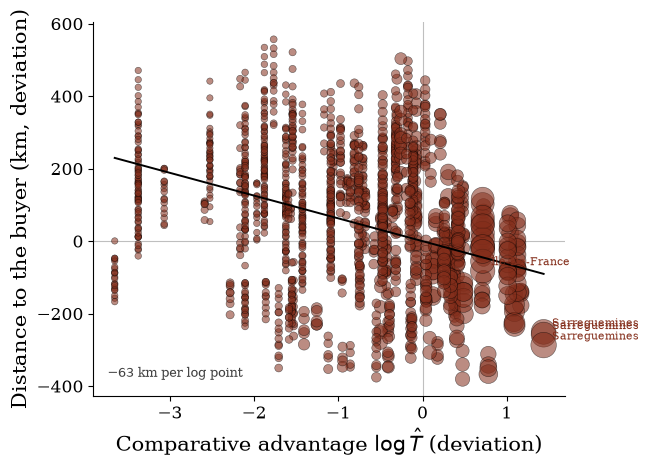

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero, mu = 2]  theta*alpha = 0.458
  average sourcing distance d_rs = 315.8 km at the sector median; equalising T takes it to 345.4 km (+32.2 km)
  slope of distance on log T (pyfixest, sector x buyer FE, rho weights): -19.4 km per log point
  identity |direct - path| / effect = 7.33e-06


,d_km,d_km_no_CA,delta_km,slope_km_per_logT,cov_rho_T_d_km,sd_rho_logT,sd_rho_distance_km,check_identity
sector,,,,,,,,
C22B,323.356752,346.701355,23.344603,-21.228287,-13.245150,0.789898,195.822414,0.000075
C25D,319.556556,344.249727,24.693170,-6.751366,-4.560848,0.821915,176.936091,0.000042
C26E,283.333475,341.275709,57.942234,-9.062405,-12.878028,1.192073,167.377970,0.000340
C27B,320.101359,344.683932,24.582572,-70.403973,-30.801148,0.661431,188.827835,0.000030
C28A,318.639556,364.484235,45.844679,-28.009208,-41.365549,1.215259,143.009775,0.000256
C30C,313.025867,315.676254,2.650386,36.048222,43.679408,1.100770,164.663797,0.000020
C33Z,336.549200,348.413452,11.864252,-57.859271,-15.637310,0.519870,227.912886,0.000045
G46Z,309.412593,349.158481,39.745888,-17.502623,-29.888777,1.306780,157.976893,0.000260
M70Z,276.412879,334.918715,58.505837,-6.536941,-9.320488,1.194076,181.277781,0.000429


slope_km_per_logT       -15.3878
se                       13.7472
n_obs                 24858.0000
n_groups                180.0000
sd_rho_logT               0.9926
sd_rho_distance_km      183.4391
Name: aero, mu = 2, dtype: float64

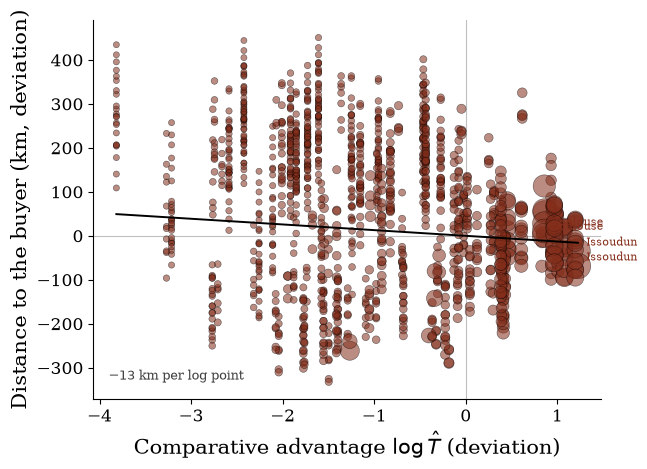

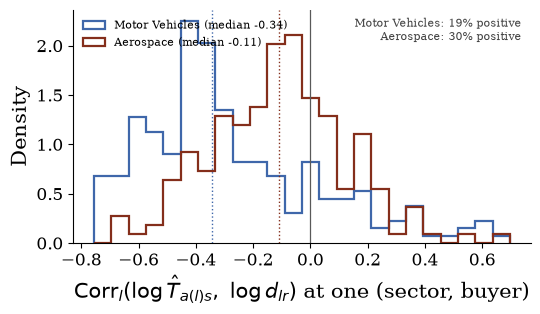

Motor Vehicles: 220 (sector, buyer) pairs, median corr -0.344, purchase-weighted mean -0.384, 19.1% positive, p10 -0.623, p90 +0.196
Aerospace: 180 (sector, buyer) pairs, median corr -0.110, purchase-weighted mean -0.162, 30.0% positive, p10 -0.413, p90 +0.186


In [108]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
ca_data = []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    ca_data.append(data)
    globals().update(data)

    display(ca_leverage_report(data))
    display(alignment_regression(data).round(4))
    _of = globals().get("out_folder")
    plot_spatial_alignment(
        data, save_to=None if _of is None else f"{_of}/spatial_alignment_{industry}_mu{MU}.pdf")
    plt.show()


# --- The alignment, buyer by buyer, both industries on one panel -------------
# The sector medians the paper quotes are averages over buyers; this is the
# distribution behind them, and it is what separates "every buyer faces the same
# alignment" from "an average over buyers pulled in opposite directions".
_ac_ax, _ac_frames = plot_alignment_correlation(
    [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, ca_data)],
    save_to=None if globals().get("out_folder") is None
            else f"{out_folder}/alignment_correlation_mu{MU}.pdf")
plt.show()
for _name, _fr in _ac_frames.items():
    _w = _fr["buyer_weight"]
    print(f"{_name}: {len(_fr)} (sector, buyer) pairs, median corr "
          f"{_fr['corr'].median():+.3f}, purchase-weighted mean "
          f"{float((_fr['corr'] * _w).sum() / _w.sum()):+.3f}, "
          f"{float((_fr['corr'] > 0).mean()):.1%} positive, "
          f"p10 {_fr['corr'].quantile(0.10):+.3f}, p90 {_fr['corr'].quantile(0.90):+.3f}")


## Test 7 — how much of the realised network is systematic, and how much is granularity?

Tests 1–6 all describe the *expected* network: $\hat T$, $\rho_{lrs}$ and the dispersion of
$\log\psi_{lrs}$ are closed forms in the parameters, and none of them carries $N_s$. But the
model's network is a **random object**: with a finite number of varieties per sector, the
realised sourcing pattern fluctuates around those probabilities. This test asks the prior
question about the object itself — **how much of the dispersion of a realised production
network is systematic, and how much is generated by the finite variety count?**

**The object, with its sector index.** Let $\Omega$ index one draw of the Ricardian
productivities. Write $X_{lrs}(\Omega)$ for the flow from upstream region $l$ to buyer $r$
in sector $s$, and

$$\omega_{lrs}(\Omega) = \frac{X_{lrs}(\Omega)}{\sum_{l'} X_{l'rs}(\Omega)}$$

for its normalised version. **The sector index is not decoration and the test is run at that
level first.** The Ricardian competition the section is about happens *inside* a sector:
$\rho_{lrs}$ is a distribution over the cells of sector $s$, the variety count $N_s$ that
generates the granularity is a *sector* parameter, and the aggregate network mixes sectors
with different supports, different $\hat T$ dispersion and different $\hat N_s$. A single
aggregate number would confound the geography of sourcing with the composition of purchases.
The buyer-level aggregate $\omega_{lr} = \sum_s \pi_{sr}\,\omega_{lrs}$ (with $\pi_{sr}$ the
sector's share of $r$'s upstream spending) is reported beside it, because it is the object
Section 5.1's incidence statistics are built on — but the sectoral table is the one that
identifies the mechanism.

**The variance is taken on shares, not on flows.** $X_{lrs}$ also carries the scale of buyer
$r$'s expenditure in sector $s$; the share isolates the spatial structure of sourcing, which
is the question. For one realisation, network dispersion is
$V_{rs}(\Omega) = \operatorname{Var}_l[\omega_{lrs}(\Omega)]$, taken across the full upstream
support, so a zero-filled cell counts.

**The decomposition.** Averaging over independent realisations,

$$\underbrace{\mathbb{E}_\Omega\big[\operatorname{Var}_l(\omega_{lrs}(\Omega))\big]}_{V^{\mathrm{real}}_{rs}}
= \underbrace{\operatorname{Var}_l\big(\mathbb{E}_\Omega[\omega_{lrs}(\Omega)]\big)}_{V^{S}_{rs}\ \text{systematic spatial sorting}}
+ \underbrace{\mathbb{E}_l\big[\operatorname{Var}_\Omega(\omega_{lrs}(\Omega))\big]}_{V^{G}_{rs}\ \text{granularity}}.$$

This is **exact rather than approximate, and for a reason worth stating**: the law of total
variance in this form would ordinarily leave a term
$\operatorname{Var}_\Omega(\mathbb{E}_l\,\omega_{lrs})$, but $\omega_{\cdot rs}$ sums to one
over $l$ by construction, so $\mathbb{E}_l\,\omega_{lrs} = 1/L$ in *every* realisation and
that term is identically zero. The two components are a genuine partition of the realised
dispersion, not an approximation of one.

$V^S_{rs}$ asks: if the particular draw of varieties were averaged out, how different would
supplier locations still be? That is the systematic network. $V^G_{rs}$ asks: holding a
supplier location fixed, how much does its share fluctuate across independent draws of the
finite variety set? It vanishes as $N_s$ grows.

**This is a different decomposition from Test 4, and the two nest.** Test 4 splits
$\operatorname{Var}_l(\log\psi_{lrs})$ into comparative advantage, distance and their spatial
alignment: that explains why the *expected* sourcing probabilities differ across locations,
so it is a decomposition **inside $V^S$**. The law of total variance explains why a
*realised* network differs from its own expectation. Written together,

$$\text{realised network dispersion} \;=\; \underbrace{\text{systematic spatial sorting}}_{\text{CA} \,+\, \text{trade costs} \,+\, \text{co-location (Test 4)}} \;+\; \underbrace{\text{granularity}}_{\text{finite } N_s}.$$

**The expected network is known in closed form here, which is what makes the sectoral
version clean.** Since $X_{lrs} = \text{spend}_{sr}\,\rho_{lrs}$, the spending cancels in the
share and $\mathbb{E}_\Omega[\omega_{lrs}] = \rho_{lrs}$ **exactly** — the same $\rho$ Tests
1–6 are written on. So $V^S_{rs} = \operatorname{Var}_l(\rho_{lrs})$ needs no simulation at
all, and the sectoral test compares the realisations against the section's own object rather
than against a re-estimate of it. Both references are nevertheless reported: `_rho` is that
closed form, `_pooled` is the mean of the $B$ realisations on disk, against which the
identity holds to machine precision on any file. They agree only in so far as the parquet
was drawn from that $\rho$. At the aggregate level the closed-form reference is the
`Both forces` allocation, which is the same $\rho$ mixed with the realised sector spending.

**The HHI identity.** Because $\operatorname{Var}_l(\omega) = H_{rs}/L - 1/L^2$ with
$H_{rs}=\sum_l\omega_{lrs}^2$, the same statement can be read on the concentration index
Section 5.1 already reports:

$$\mathbb{E}_\Omega[H_{rs}(\Omega)] = \underbrace{\sum_l \bar\omega_{lrs}^2}_{\text{concentration of the expected network}} + \underbrace{\sum_l \operatorname{Var}_\Omega(\omega_{lrs}(\Omega))}_{\text{granularity}},$$

an exact additive decomposition of expected concentration: a realised network is
*mechanically* more concentrated than its expectation, so its effective number of
destinations $1/H$ is mechanically smaller. It is the same identity multiplied by $L$, and
the notebook prints both so that it reads as one statement rather than two pieces of
evidence.

**The finite-$B$ bias, which goes the wrong way.** $\operatorname{Var}_l$ of the *estimated*
mean network overstates $V^S$ by exactly $V^G/B$, because the estimated mean inherits a
$1/B$ share of the granular noise. With $B$ realisations the raw split therefore
*understates* granularity. $V^G$ is estimated with `ddof=1` and $V^S$ is reported
bias-corrected as $\operatorname{Var}_l(\hat{\bar\omega}) - V^G/B$, which restores
$V^{\mathrm{real}} = V^S + V^G$ exactly; the uncorrected column is kept beside it so the size
of the correction is visible rather than argued. Against the closed-form $\rho$ the question
does not arise — that reference carries no sampling error.

**Does $V^G$ actually behave like a variety effect? The sector index is what makes this
testable.** The comparative static $\operatorname{d}\log V^G_s/\operatorname{d}\log \hat N_s$
across sectors is the test: near $-1$ is the equal-weight benchmark, negative is the
mechanism, and **flat would mean $V^G$ is picking up an omitted systematic force rather
than the variety count** — which is exactly the alternative this test exists to rule out.
The next subsection replaces that benchmark reasoning with an exact prediction.

**One caveat on levels, stated so it is not read into the numbers.** $\operatorname{Var}_l$
is taken over the full upstream support $L=R$ for every sector, so a sector present in few
cells has structural zeros outside its support and a mechanically larger $V^S$. The `n_cells`
column records the support, the shares $V^G/V^{\mathrm{real}}$ are the comparable quantity
across sectors, and the level of $V^S$ is not.

**Running it.** Test 7 is the only test in this section that reads the *realised*
economy (`suppliers.parquet`) rather than a closed form, so it uses the parquet helpers
the amplification section owns rather than duplicating them — one reader of that file is
enough, and a second copy would drift from it. Run that section's definition cell before
this run cell, or run the notebook through.

### The theoretical counterpart of $V^G$, and it is exact

$V^G$ is not merely "of order $1/N_s$": it has a closed form, and the model supplies the
one independence result the derivation needs.

Within sector $s$ and buyer $r$, write the realised share as a weighted count over the
sector's $N_s$ varieties,

$$\omega_{lrs} = \sum_{\rho} v_{\rho}\,\mathbb{1}\{\text{variety } \rho \text{ is won by cell } l\},$$

where $v_\rho$ is variety $\rho$'s share of the buyer's spending on the sector. Reading
`exp_val` off `model_CP.jl`, $v_\rho \propto w_\rho\,(p_{\rho s}/P_{sr})^{1-\nu_s}$: the
sector and aggregate price factors are common within $(s,r)$ and cancel in the
normalisation, and under the granular weights $w_\rho = 1/N_s$ for every cell of the
sector — so **$v_\rho$ depends on the realised prices alone**. Under Fréchet the winner's
identity is independent of the winning price ($\arg\min \perp \min$), which is the same
property that gives $\hat q \perp N_s$. The weights are therefore independent of *who*
won, and the winners are i.i.d. multinomial with probabilities $\rho_{lrs}$. Conditioning
on the weights and using $\operatorname{Var}(\sum_\rho v_\rho \mathbb{1}_\rho) = \sum_\rho v_\rho^2\, p(1-p)$,

$$\boxed{\;V^{G}_{rs} \;=\; H_{v,s}\cdot \mathbb{E}_l\big[\rho_{lrs}(1-\rho_{lrs})\big],
\qquad H_{v,s} \equiv \mathbb{E}_\Omega\Big[\textstyle\sum_\rho v_\rho^2\Big]\;}$$

with $H_{v,s}$ the expected Herfindahl of the *variety* weights. In the HHI form the same
statement is

$$\mathbb{E}_\Omega[H_{rs}] = H_{\rho,rs} + H_{v,s}\big(1 - H_{\rho,rs}\big)
\qquad\Longleftrightarrow\qquad 1 - \mathbb{E}_\Omega[H_{rs}] = (1-H_{v,s})(1-H_{\rho,rs}),$$

so realised and expected concentration compose **multiplicatively**, and $1/H_{v,s}$ is
exactly the *effective number of varieties* — equal to $N_s$ if and only if varieties carry
equal weight, and smaller otherwise.

**Three predictions of increasing strictness are reported side by side.**

| | $H_v$ | needs | reading |
|---|---|---|---|
| `equal` | $1/\hat N_s$ | $\hat T,\hat\alpha,\hat N_s$ | the textbook multinomial benchmark; a **lower bound** on $V^G$ |
| `frechet` | the CES weights implied by $(\hat N_s,\nu_s,\theta)$ | the parameters only | the prediction the paper can quote |
| `exact` | measured from the parquet's variety weights | the realised economy | the derivation's own prediction: **this one must equal the simulated value** |

**The middle row turns on the sign of one exponent, and getting it wrong changes the
scaling law rather than a constant.** `model_CP.jl` draws
$z = \text{scale}\cdot(-\log(1-u))^{-1/\theta}$, so $\Pr(p_l > x) = \exp(-\Phi_l x^{\theta})$
and the *winning price itself* is the exponential variable: $p^{\theta}\sim\mathrm{Exp}(\Phi)$.
The CES weight is therefore

$$v_\rho \;\propto\; p_\rho^{1-\nu_s} \;=\; \big(p_\rho^{\theta}\big)^{(1-\nu_s)/\theta} \;=\; \mathcal{E}_\rho^{-\kappa}, \qquad \kappa = \frac{\nu_s-1}{\theta},$$

a **negative** power of an i.i.d. exponential. The cheapest variety of the sector — the one
whose $\mathcal{E}$ came out near zero — takes a share with no upper bound, so the weights
are heavy-tailed. $\mathbb{E}[v^2]$ is finite only for $2\kappa<1$, i.e.
$\nu_s < 1+\theta/2$; at this calibration ($\nu_s=1.5$, $\theta=1$, both set in
`load_parameters.jl`) $2\kappa = 1$ **exactly**, the second moment diverges
logarithmically, and there is no constant $c$ with $H_v \to c/N$:

$$H_{v,s} \;\sim\; \frac{\log N_s}{N_s} \qquad\text{rather than}\qquad \frac{c}{N_s}.$$

**Granularity therefore dies out more slowly than the textbook $1/N$**, and the log-log
slope of $V^G$ on $\hat N_s$ is shallower than $-1$ by construction, not by accident. Since
no closed form survives in that regime, `frechet_ces_weight_hhi` evaluates the expectation
by Monte Carlo on the weight distribution itself — $N$ exponentials, fixed seed, distinct
$N$ computed once. It is still parameter-only: it touches neither the network nor $\hat T$.

*(An earlier version of this cell used $\mathcal{E}^{+\kappa}$ and the resulting finite
$\Gamma(1+2\kappa)/\Gamma(1+\kappa)^2 = 4/\pi$ constant. The estimates rejected it — the
measured $H_v$ came out 30–40% larger and the slope was $-0.65/-0.78$ rather than $-1$ —
which is what sent us back to the draw in `model_CP.jl`. Both discrepancies are the missing
minus sign, and both go away with it.)*

**Verified twice.** On a synthetic economy built with this structure the `exact` ratio is
$0.998$–$1.013$, the variance identity closes at $10^{-17}$ and the HHI form's residual
falls as $1/\sqrt B$. On the estimates, the corrected parameter-only prediction reproduces
the measured $1/H_{v,s}$ across all twenty sectors of the two industries, $\hat N_s$
ranging from 5 to 24, with a median ratio of $0.995$ and no sector off by more than 14%.

### Both levels, because they answer different halves of the question

Sectors draw their varieties independently, so with $\pi_{sr}$ the share of buyer $r$'s
upstream spending going to sector $s$,

$$V^{G}_{r} = \sum_s \pi_{sr}^2\;H_{v,s}\;\mathbb{E}_l\big[\rho_{lrs}(1-\rho_{lrs})\big].$$

The sum of squares is the whole of the aggregation, and it is an economic statement rather
than an algebraic one: **a buyer spread over many sectors has a mechanically less granular
network**, whatever its geography, because it is averaging independent draws. The sector
level is where the mechanism is identified — $\rho$ is the exact expected network there and
the implied variety count has $\hat N_s$ itself to sit beside — and the buyer level is the
object Section 5.1's incidence statistics are built on. The bridge between the two numbers
is the sector-mix Herfindahl $\sum_s \pi_{sr}^2$, which is reported with them.
`network_variance_report` runs both levels and both theory checks in one call.


In [109]:
# Test 7 — the dispersion of the REALISED network, split into systematic spatial sorting
# and granularity, sector by sector.
#
# Tests 1-6 are all written on `rho`, which carries no N_s: they describe the EXPECTED
# network. With finite varieties the realised network fluctuates around it, and the law of
# total variance separates the two. It is exact here rather than approximate, because
# omega sums to one over l in every realisation, so E_l omega = 1/L is non-random and the
# cross term of the decomposition vanishes identically.
#
# THE SECTOR INDEX IS THE POINT. The Ricardian competition is inside a sector, N_s is a
# sector parameter, and the aggregate network mixes sectors with different supports and
# different variety counts. So the decomposition is run per (sector, buyer) first --
# where the expected network is exactly rho_{lrs} and the implied variety count is
# directly comparable to N_hat_s -- and the buyer-level aggregate, which is the object
# section 5.1's incidence statistics are built on, is reported beside it.
#
# ONE DEPENDENCY, stated because it breaks "run this section on its own". Test 7 is the
# only test here that reads the REALISED economy rather than a closed form, so it needs
# the parquet helpers the amplification section owns -- `_parquet_sector_index` (which
# refuses an A129 column it cannot place rather than mapping one sector's euros onto
# another's), `build_diffusion_frame`, `counterfactual_diffusion_frame`,
# `incidence_matrix` and `_n_hat_from_diagnostics`. They are NOT duplicated here: one
# reader of `suppliers.parquet` is enough, and a second copy would drift from it. Run the
# amplification section's definition cell before this run cell, or run the notebook
# through; the run cell catches the NameError and says so.


def _omega_cube(df, R, keys=("ze2010_downstream",)):
    """
    The incidence vectors of every realisation as one array.

    Returns `(A, rows, reps)` with `A` of shape (B, n_row, R): `A[b, i, l]` is the share
    of row `i`'s upstream response landing in region `l` in realisation `b`. Rows are the
    distinct values of `keys` -- `("ze2010_downstream",)` for the aggregate network,
    `("sector", "ze2010_downstream")` for the sectoral one -- and `reps` the sorted
    replication labels. A row with no upstream sales in a given realisation comes back as
    all-NaN, so the statistics drop it rather than count it as perfectly dispersed, which
    is the convention `incidence_stats` uses.

    Built by scatter-add rather than by one pivot per realisation, so the full
    (B x n_row x R) support is zero-filled by construction: a cell that supplies nothing
    belongs in the denominator's support and must enter Var_l.
    """
    keys = list(keys)
    reps = np.sort(df["replication"].unique())
    rep_of = {v: i for i, v in enumerate(reps)}
    rows = df[keys].drop_duplicates().sort_values(keys).reset_index(drop=True)
    row_of = {tuple(t): i for i, t in enumerate(rows.itertuples(index=False, name=None))}

    bi = df["replication"].map(rep_of).to_numpy()
    ri = np.array([row_of[t] for t in
                   df[keys].itertuples(index=False, name=None)], dtype=int)
    li = df["ze2010"].to_numpy(dtype=int) - 1

    A = np.zeros((len(reps), len(rows), R), dtype=float)
    np.add.at(A, (bi, ri, li), df["upstream_sales"].to_numpy(dtype=float))
    tot = A.sum(axis=2)
    with np.errstate(invalid="ignore", divide="ignore"):
        A = A / np.where(tot > 0, tot, np.nan)[:, :, None]
    return A, rows, reps


def _decompose_cube(A, expected=None):
    """
    The law-of-total-variance split of one (B, n_row, R) cube of incidence vectors.

    Returns one row per row of the cube. `expected` optionally supplies an INDEPENDENT
    expected network of shape (n_row, R) -- at the sector level that is `rho_{lrs}`
    itself, in closed form; the pooled mean of the cube is always computed as well, since
    the identity is exact against it and only approximately so against `rho`.

    The finite-B bias is handled rather than ignored. `Var_l` of the ESTIMATED mean
    network overstates the systematic term by V_G/B, so `v_systematic` subtracts it and
    `v_systematic_raw` keeps the uncorrected value; `v_granular` uses `ddof=1`, which is
    unbiased for Var_Omega. With those two conventions `v_real = v_systematic +
    v_granular` holds to machine precision, which is what `identity_gap` reports.
    """
    B, n, L = A.shape
    ok = np.isfinite(A).all(axis=2)                      # (B, n)
    keep = ok.all(axis=0)                                # rows present in every draw
    Bf = float(B)

    with np.errstate(invalid="ignore"):
        var_l = np.nanvar(A, axis=2, ddof=0)             # Var_l, per realisation
        v_real = var_l.mean(axis=0)
        bar = A.mean(axis=0)                             # pooled expected network
        v_sys_raw = np.var(bar, axis=1, ddof=0)
        v_gran = (np.var(A, axis=0, ddof=1).mean(axis=1) if B > 1
                  else np.full(n, np.nan))
        v_sys = v_sys_raw - (v_gran / Bf if B > 1 else 0.0)

        hhi_real = (A ** 2).sum(axis=2).mean(axis=0)
        hhi_bar = (bar ** 2).sum(axis=1)

    out = pd.DataFrame({
        "v_real": v_real,
        "v_systematic": v_sys,
        "v_granular": v_gran,
        "v_systematic_raw": v_sys_raw,
        "granularity_share": v_gran / np.where(v_real > 0, v_real, np.nan),
        "identity_gap": v_real - (v_sys + v_gran),
        # the same statement read on the concentration index section 5.1 reports
        "hhi_realised": hhi_real,
        "hhi_expected_pooled": hhi_bar,
        "hhi_granularity": hhi_real - hhi_bar,      # = sum_l Var_Omega(omega)
        "n_eff_realised": 1.0 / np.where(hhi_real > 0, hhi_real, np.nan),
        "n_eff_expected_pooled": 1.0 / np.where(hhi_bar > 0, hhi_bar, np.nan),
        "n_replications": B,
    })

    if expected is not None:
        E = np.asarray(expected, dtype=float)
        with np.errstate(invalid="ignore"):
            out["v_systematic_rho"] = np.nanvar(E, axis=1, ddof=0)
            out["hhi_expected_rho"] = np.nansum(E ** 2, axis=1)
            # E_l[rho(1-rho)]: the geography half of the closed form for V^G derived
            # below. Exposed as a column so the theory check reads it off this table
            # instead of rebuilding rho.
            out["e_p1p"] = np.nanmean(E * (1.0 - E), axis=1)
            # the multinomial benchmark, inverted: how many equally weighted varieties
            # would generate this much fluctuation. At the sector level this is directly
            # comparable to N_hat_s -- reported, never asserted.
            out["n_varieties_implied"] = out["e_p1p"] \
                / np.where(v_gran > 0, v_gran, np.nan)
        out["v_granular_rho"] = out["v_real"] - out["v_systematic_rho"]
        out["granularity_share_rho"] = out["v_granular_rho"] / \
            np.where(out["v_real"] > 0, out["v_real"], np.nan)
        out["n_eff_expected_rho"] = 1.0 / out["hhi_expected_rho"].replace(0, np.nan)
    else:
        with np.errstate(invalid="ignore"):
            out["e_p1p"] = np.nanmean(bar * (1.0 - bar), axis=1)
            out["n_varieties_implied"] = out["e_p1p"] \
                / np.where(v_gran > 0, v_gran, np.nan)
    out[~keep] = np.nan
    return out


def _sector_replication_frame(data, value_col="share"):
    """
    `suppliers.parquet` reduced to (replication, sector, buyer, upstream region) sales.

    The sector index is the model's own 0-based one, read through
    `_parquet_sector_index`, which refuses a column it cannot place rather than mapping
    one sector's euros onto another's.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— there is no realised economy to decompose.")
    if "replication" not in sup.columns:
        raise ValueError(
            "the parquet carries no `replication` column, so there is a single "
            "realisation and Var_Omega is not identified — this is the continuum solve. "
            "Re-run main.jl's post-hoc block under GRANULAR.")
    return (sup.assign(sector=_parquet_sector_index(data, sup))
               .groupby(["replication", "sector", "ze2010_downstream", "ze2010"],
                        as_index=False)[value_col].sum()
               .rename(columns={value_col: "upstream_sales"}))


def rho_incidence(data, rows, geom=None):
    """
    The EXPECTED sectoral incidence `rho_{lrs}`, laid out on the full upstream support.

    `rows` is a frame with columns `sector` and `ze2010_downstream`; the return is an
    (n_row x R) array whose row `i` is `rho_{. , r_i, s_i}` padded with zeros outside the
    sector's modelled cells. Since `X_{lrs} = spend_{sr} * rho_{lrs}`, the spending
    cancels in the share, so this IS `E_Omega[omega_{lrs}]` exactly — no simulation and
    no averaging enter it, which is what lets the sectoral test compare the realisations
    against the section's own object.
    """
    geom = sourcing_geometry(data) if geom is None else geom
    col_of_rd = {int(z): j for j, z in enumerate(geom["downstream"])}
    E = np.full((len(rows), data["R"]), np.nan)
    for i, (s, rd) in enumerate(zip(rows["sector"].to_numpy(),
                                    rows["ze2010_downstream"].to_numpy())):
        blk = geom["by_sector"].get(int(s))
        j = col_of_rd.get(int(rd))
        if blk is None or j is None:
            continue
        v = np.zeros(data["R"])
        v[blk["cells"]] = blk["rho"][:, j]
        E[i] = v
    return E


def network_variance_decomposition(data, level="sector", value_col="share",
                                   expected=None, verbose=True):
    """
    The realised network's spatial dispersion, split into systematic sorting and
    granularity.

        E_Omega[Var_l(omega)] = Var_l(E_Omega omega) + E_l[Var_Omega(omega)]

    `level="sector"` (the default, and the one that identifies the mechanism) returns one
    row per (sector, buyer), with the expected network taken as the closed-form
    `rho_{lrs}`. `level="buyer"` aggregates the sectors first and returns one row per
    buyer -- the object section 5.1's incidence statistics are built on -- with the
    expected network taken as the `Both forces` allocation, i.e. the same rho mixed with
    the realised sector spending.

    The first term is what comparative advantage, trade costs and their spatial
    covariance generate; Test 4's decomposition of `Var_l(log psi)` is a decomposition
    INSIDE it. The second is the finite variety count.
    """
    if level not in ("sector", "buyer"):
        raise ValueError("level must be 'sector' or 'buyer'.")
    R = data["R"]

    if level == "sector":
        long = _sector_replication_frame(data, value_col)
        A, rows, reps = _omega_cube(long, R, keys=("sector", "ze2010_downstream"))
        E = rho_incidence(data, rows) if expected is None else np.asarray(expected)
        idx = pd.MultiIndex.from_frame(rows[["sector", "ze2010_downstream"]])
    else:
        df = build_diffusion_frame(data, value_col, per_replication=True)
        if "replication" not in df.columns:
            raise ValueError("no `replication` column: this is the continuum solve.")
        A, rows, reps = _omega_cube(df, R, keys=("ze2010_downstream",))
        buyers = rows["ze2010_downstream"].to_numpy()
        if expected is None:
            # the model's own expected aggregate network: the closed-form `Both forces`
            # allocation, computed on rho and carrying no N_s at all. It is the same rho
            # as the sectoral reference, mixed with the realised sector spending — which
            # is why the sector composition sits INSIDE the aggregate systematic term.
            expected = counterfactual_diffusion_frame(
                data, value_col=value_col,
                diffusion=build_diffusion_frame(data, value_col), verbose=False)
        E = (expected if isinstance(expected, np.ndarray)
             else incidence_matrix(expected, R=R)
                  .reindex(index=buyers, columns=np.arange(1, R + 1))
                  .to_numpy(dtype=float))
        idx = pd.Index(buyers, name="ze2010_downstream")

    out = _decompose_cube(A, expected=E)
    out.index = idx
    names = [str(c) for c in data["sector_names"]]
    lab = _region_labels(data).set_index("index")["ze2010_name"]
    if level == "sector":
        out.insert(0, "sector_name",
                   [names[s] if s < len(names) else str(s)
                    for s in out.index.get_level_values("sector")])
        out.insert(1, "region", lab.reindex(
            out.index.get_level_values("ze2010_downstream")).to_numpy())
        # the sector's modelled support: Var_l runs over all R regions in every sector,
        # so a sector present in few cells has structural zeros outside its support and a
        # mechanically larger V_S. The shares are comparable across sectors; the levels
        # are not, and this column is what says so.
        out["n_cells"] = np.nansum(E > 0, axis=1)
    else:
        out.insert(0, "region", lab.reindex(out.index).to_numpy())

    out.attrs["level"] = level
    out.attrs["n_replications"] = int(len(reps))
    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    out.attrs["N_hat"] = None if n_hat is None else np.asarray(n_hat, dtype=float).ravel()

    if verbose:
        B = out.attrs["n_replications"]
        g = float(np.nansum(out["v_granular"]) / np.nansum(out["v_real"]))
        n = int(out["v_real"].notna().sum())
        print(f"  network variance decomposition, {level} level "
              f"({B} realisations, {n} rows)")
        print(f"    V_real {np.nanmean(out['v_real']):.3e}   "
              f"V_sys {np.nanmean(out['v_systematic']):.3e}   "
              f"V_gran {np.nanmean(out['v_granular']):.3e}")
        print(f"    granularity share  G = {g:.3f} (ratio of means), "
              f"median {np.nanmedian(out['granularity_share']):.3f}")
        if "granularity_share_rho" in out:
            print(f"    against the closed-form rho network rather than the pooled mean: "
                  f"{np.nanmedian(out['granularity_share_rho']):.3f}")
        print(f"    finite-B correction moved V_sys by "
              f"{np.nanmean(out['v_systematic_raw'] - out['v_systematic']):.2e} "
              f"(= V_gran/B); identity holds to "
              f"{np.nanmax(np.abs(out['identity_gap'])):.2e}")
        print(f"    HHI identity: E[H] {np.nanmean(out['hhi_realised']):.4f} = "
              f"H(omega_bar) {np.nanmean(out['hhi_expected_pooled']):.4f} + granularity "
              f"{np.nanmean(out['hhi_granularity']):.4f}; n_eff "
              f"{np.nanmean(out['n_eff_realised']):.1f} realised against "
              f"{np.nanmean(out['n_eff_expected_pooled']):.1f} expected")
    return out


def network_variance_by_sector(table, data=None, verbose=True):
    """
    The sectoral decomposition reduced to one row per sector, with the variety
    comparative static attached.

    `N_hat` comes from the table's own `.attrs` (the model's calibrated variety count) and
    `n_varieties_implied` is the median across buyers of the multinomial inversion, so the
    two sit side by side sector by sector -- which is the comparison the aggregate version
    cannot make, since it can only be read against `sum_s N_hat_s`.

    `log_slope_vG_on_N` is `d log V_G / d log N_hat` across sectors: -1 is the equal-weight
    benchmark, negative is the mechanism, and FLAT is the alternative this test exists to
    rule out -- a V_G that does not track the variety count is an omitted systematic force,
    not granularity.
    """
    if table.attrs.get("level") != "sector":
        raise ValueError("network_variance_by_sector expects the level='sector' table.")
    by = table.groupby(level="sector").agg(
        sector_name=("sector_name", "first"),
        v_real=("v_real", "mean"), v_systematic=("v_systematic", "mean"),
        v_granular=("v_granular", "mean"),
        granularity_share=("granularity_share", "median"),
        granularity_share_rho=("granularity_share_rho", "median"),
        n_eff_realised=("n_eff_realised", "median"),
        n_eff_expected=("n_eff_expected_rho", "median"),
        n_varieties_implied=("n_varieties_implied", "median"),
        n_cells=("n_cells", "median"), n_buyers=("v_real", "size"))
    n_hat = table.attrs.get("N_hat")
    by["N_hat"] = ([n_hat[s] if n_hat is not None and s < n_hat.size else np.nan
                    for s in by.index])
    by["implied_over_N_hat"] = by["n_varieties_implied"] / by["N_hat"]

    m = by[["v_granular", "N_hat"]].replace(0, np.nan).dropna()
    slope = np.nan
    if len(m) >= 3:
        slope = float(np.polyfit(np.log(m["N_hat"].to_numpy(dtype=float)),
                                 np.log(m["v_granular"].to_numpy(dtype=float)), 1)[0])
    by.attrs["log_slope_vG_on_N"] = slope
    by.attrs["n_replications"] = table.attrs.get("n_replications")
    if verbose:
        cols = ["sector_name", "N_hat", "n_varieties_implied", "implied_over_N_hat",
                "v_real", "v_systematic", "v_granular", "granularity_share",
                "n_eff_realised", "n_eff_expected", "n_cells", "n_buyers"]
        print("  per sector (the level at which the variety count can be tested):")
        print(by[cols].round(5).to_string(index=False))
        print(f"    d log V_G / d log N_hat = {slope:.2f}  "
              "(equal-weight benchmark -1; flat would mean V_G is not a variety effect)")
    return by


def plot_network_variance(tables, label_col="sector_name", figsize=None, save_to=None):
    """
    The decomposition as one stacked bar per sector: systematic sorting below,
    granularity above, both as shares of the realised dispersion.

    Shares rather than levels, because `V_real` differs across sectors by orders of
    magnitude -- a sector present in a handful of cells has a mechanically larger
    dispersion than one spread over the country -- and the question is compositional.
    Every bar therefore has length one and there is no scale to exaggerate. One panel per
    industry, sharing one window.
    """
    n = len(tables)
    fig, arr = plt.subplots(1, n, sharex=True, figsize=figsize or (5.2 * n, 4.2))
    axes = list(np.atleast_1d(arr))
    for ax, (lab, tab) in zip(axes, tables):
        t = tab.dropna(subset=["granularity_share"]).sort_values("granularity_share")
        y = np.arange(len(t))
        gs = t["granularity_share"].to_numpy(dtype=float)
        ax.barh(y, 1.0 - gs, height=0.75, color=toulouse_color,
                label="Systematic spatial sorting", edgecolor="white", linewidth=0.4)
        ax.barh(y, gs, left=1.0 - gs, height=0.75, color=sim_color,
                label="Granularity", edgecolor="white", linewidth=0.4)
        ax.set_yticks(y)
        ax.set_yticklabels(t[label_col].astype(str) if label_col in t.columns
                           else t.index.astype(str), fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.6, len(t) - 0.4)
        ax.set_title(lab, fontsize=9)
        ax.grid(alpha=0.2, axis="x")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0].set_ylabel("Sector")
    fig.supxlabel("Share of the realised network's spatial dispersion", fontsize=9)
    axes[0].legend(frameon=False, fontsize=8, loc="lower left",
                   bbox_to_anchor=(0.0, 1.05), ncol=2)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes[0]


def plot_granularity_variety_scaling(tables, figsize=None, save_to=None):
    """
    The two ways of asking whether the granularity term is the variety count, side by
    side, one dot per SECTOR.

    LEFT: `V_G_s` against `N_hat_s`, both axes logarithmic, with the `1/N` benchmark drawn
    through each industry's own geometric mean -- so what is read off the panel is the
    SLOPE, not the level (the level depends on `E_l[rho(1-rho)]`, a property of the
    sector's geography rather than of its variety count).

    RIGHT: the multinomial inversion `N_eff_s` against `N_hat_s` on the 45-degree line.
    This is the comparison the aggregate decomposition cannot make: it can only be read
    against `sum_s N_hat_s`, whereas per sector the implied count has the model's own
    parameter to sit beside. Points below the line are varieties whose unequal CES
    weights make the network noisier than an equal-weight draw of `N_hat_s`.
    """
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize or (10.0, 4.2))
    cols = [toulouse_color, sim_color, (0.45, 0.60, 0.45)]
    lo, hi = np.inf, -np.inf
    for k, (lab, by) in enumerate(tables):
        c = cols[k % len(cols)]
        m = by[["N_hat", "v_granular"]].replace(0, np.nan).dropna()
        if not m.empty:
            x = m["N_hat"].to_numpy(dtype=float); y = m["v_granular"].to_numpy(dtype=float)
            ax0.scatter(x, y, s=42, color=c, edgecolors="white", linewidths=0.5, zorder=4,
                        label=f"{lab} (slope {by.attrs.get('log_slope_vG_on_N', np.nan):.2f})")
            gx, gy = np.exp(np.mean(np.log(x))), np.exp(np.mean(np.log(y)))
            xs = np.array([x.min(), x.max()], dtype=float)
            ax0.plot(xs, gy * (xs / gx) ** (-1.0), color=c, lw=0.9, ls="--", alpha=0.7,
                     zorder=2)
        p = by[["N_hat", "n_varieties_implied"]].replace(0, np.nan).dropna()
        if not p.empty:
            ax1.scatter(p["N_hat"], p["n_varieties_implied"], s=42, color=c,
                        edgecolors="white", linewidths=0.5, zorder=4, label=lab)
            lo = min(lo, p.to_numpy(dtype=float).min())
            hi = max(hi, p.to_numpy(dtype=float).max())
    ax0.set_xscale("log"); ax0.set_yscale("log")
    ax0.set_xlabel(r"Number of varieties $\hat N_s$")
    ax0.set_ylabel(r"Granularity component $V^{G}_s$")
    ax0.legend(frameon=False, fontsize=8, loc="best",
               title=r"dashed: the $1/N$ benchmark", title_fontsize=8)
    if np.isfinite(lo) and np.isfinite(hi):
        ax1.plot([lo, hi], [lo, hi], color="0.5", lw=0.9, ls="--", zorder=2)
    ax1.set_xlabel(r"Number of varieties $\hat N_s$")
    ax1.set_ylabel(r"Implied effective count $N^{\mathrm{eff}}_s$")
    ax1.legend(frameon=False, fontsize=8, loc="best")
    for ax in (ax0, ax1):
        ax.grid(alpha=0.2, which="both")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax0


# --- The theoretical counterpart of V^G, and it is EXACT ---------------------
#
# The granularity term is not merely "of order 1/N". It has a closed form, and the
# derivation is three lines because the model supplies the one independence result it
# needs.
#
# Within sector s and buyer r, write the realised share as a weighted count over the
# sector's N_s varieties,
#
#     omega_lrs = sum_rho v_rho * 1{variety rho is won by cell l},
#
# where `v_rho` is variety rho's share of the buyer's spending on the sector. Reading
# `exp_val` off model_CP.jl, v_rho ∝ w_rho * (p_rho/P_sr)^{1-nu_s}: the sector and
# aggregate price factors are common within (s, r) and cancel in the normalisation, and
# under the granular weights `w_rho = 1/N_s` for every cell of the sector, so **v_rho
# depends on the realised PRICES alone**. Under Frechet the winner's identity is
# independent of the winning price (argmin ⟂ min) — the same property that gives
# `q_hat ⟂ N_s` — so the weights are independent of who won, and the winners are i.i.d.
# multinomial with probabilities rho_lrs. Conditioning on the weights,
#
#     Var_Omega(omega_lrs) = E[sum_rho v_rho^2] * rho_lrs (1 - rho_lrs),
#
# hence, with H_v,s = E[sum_rho v_rho^2] the expected Herfindahl of the VARIETY weights,
#
#     V^G_rs = H_v,s * E_l[rho_lrs (1 - rho_lrs)]        (exact)
#     E_Omega[H_rs] = H_rho,rs + H_v,s * (1 - H_rho,rs)  (exact, the HHI form)
#
# The second line is worth stating on its own: `1 - E[H_realised] = (1 - H_v)(1 - H_rho)`,
# so realised and expected concentration compose MULTIPLICATIVELY, and `1/H_v` is exactly
# the effective number of varieties. It equals N_s if and only if the varieties carry
# equal weight, and is otherwise smaller.
#
# That gives three predictions of increasing strictness, all reported side by side:
#
#   `equal`    H_v = 1/N_hat_s. Uses (T_hat, alpha_hat, N_hat_s) and nothing else. This
#              is the textbook multinomial benchmark and it is a LOWER bound on V^G.
#   `frechet`  H_v = (1/N_hat_s) * Gamma(1+2k)/Gamma(1+k)^2 with k = (nu_s-1)/theta.
#              Still fully closed form in the parameters: p_rho^{-theta} is exponential,
#              so v_rho ∝ E_rho^k with E i.i.d. exponential, and the ratio of moments is
#              the large-N limit of E[sum v^2] * N. At nu_s = 1.5 and theta = 1 the factor
#              is 4/pi = 1.273 — the CES weights make the network 27% noisier than an
#              equal-weight draw of the same N_s.
#   `exact`    H_v measured from the parquet's own variety weights. This one should match
#              the simulated V^G up to Monte-Carlo error in B; a gap means the derivation
#              above is wrong somewhere, not that the model is.
#
# At the BUYER level the sectors are independent draws, so with pi_sr the sector's share
# of buyer r's upstream spending,
#
#     V^G_r = sum_s pi_sr^2 * H_v,s * E_l[rho_lrs (1 - rho_lrs)],
#
# and the sum of squares is the whole of the aggregation: **a buyer spread over many
# sectors has a mechanically less granular network**, whatever the geography. That is the
# one term the sector-level table cannot show and the buyer-level one exists for.


def variety_weight_concentration(data, value_col="share", verbose=False):
    """
    The expected Herfindahl `H_v` of the VARIETY expenditure weights, per (sector, buyer).

    Within a (realisation, sector, buyer) each of the sector's varieties is won by exactly
    one cell and appears exactly once in the parquet, so `v_rho` is that row's share of
    the group total and `H_v = sum_rho v_rho^2`. Averaged over realisations, it is the
    factor that converts `E_l[rho(1-rho)]` into `V^G` exactly.

    The variety is identified by the `variety` column when the parquet carries one. The
    fallback on `SIREN` is safe HERE though it is not in general: a firm is a (cell,
    sector, variety) triple, so one variety yields several firms across buyers — but
    within a FIXED buyer only the winner appears, and the two keys coincide.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError("no suppliers.parquet — H_v cannot be measured.")
    if "replication" not in sup.columns:
        raise ValueError("no `replication` column: this is the continuum solve.")
    key = "variety" if "variety" in sup.columns else "SIREN"
    g = ["replication", "sector", "ze2010_downstream"]
    per = (sup.assign(sector=_parquet_sector_index(data, sup))
              .groupby(g + [key], as_index=False)[value_col].sum())
    tot = per.groupby(g)[value_col].transform("sum")
    per["v"] = per[value_col] / tot.where(tot > 0)
    hv = (per.assign(v2=per["v"] ** 2).groupby(g)["v2"].sum()
             .groupby(level=["sector", "ze2010_downstream"]).mean()
             .rename("hv"))
    n_obs = (per.groupby(g).size()
                .groupby(level=["sector", "ze2010_downstream"]).mean()
                .rename("n_varieties_observed"))
    out = pd.concat([hv, n_obs], axis=1)
    out["n_eff_varieties"] = 1.0 / out["hv"].replace(0, np.nan)
    out.attrs["variety_key"] = key
    if verbose:
        print(f"  variety weights keyed on `{key}`: effective count "
              f"{out['n_eff_varieties'].median():.2f} against "
              f"{out['n_varieties_observed'].median():.2f} varieties observed")
    return out


def sector_spend_shares(data, value_col="share"):
    """`pi_sr`, the share of buyer `r`'s upstream spending going to sector `s`, averaged
    over realisations. It is what aggregates the sectoral granularity to the buyer."""
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError("no suppliers.parquet.")
    rep = ["replication"] if "replication" in sup.columns else []
    per = (sup.assign(sector=_parquet_sector_index(data, sup))
              .groupby(rep + ["ze2010_downstream", "sector"])[value_col].sum())
    tot = per.groupby(level=rep + ["ze2010_downstream"]).transform("sum")
    sh = (per / tot.where(tot > 0)).rename("pi")
    return (sh.groupby(level=["sector", "ze2010_downstream"]).mean()
            if rep else sh.reorder_levels(["sector", "ze2010_downstream"]))


def frechet_ces_weight_hhi(N, nu_s=None, theta=None, n_draws=200_000, seed=0,
                           verbose=False):
    """
    The `H_v` implied by the PARAMETERS alone: the expected Herfindahl of the CES weights
    of `N` varieties whose prices are the model's own Frechet winners.

    THE EXPONENT'S SIGN IS THE WHOLE OF THIS FUNCTION, and it is not the one a reading of
    "Frechet productivity" suggests. `model_CP.jl` draws `z = scale * (-log(1-u))^{-1/theta}`,
    so `Pr(p_l > x) = exp(-Phi_l x^theta)` and the winning price satisfies **`p^theta ~
    Exp(Phi)`** -- the price, not its reciprocal, is the exponential variable. The CES
    weight is therefore

        v ∝ p^{1-nu_s} = (p^theta)^{(1-nu_s)/theta} = E^{-kappa},   kappa = (nu_s-1)/theta,

    with E i.i.d. standard exponential: a NEGATIVE power. The cheapest variety of the
    sector -- the one whose `E` came out near zero -- takes a share that grows without
    bound, so the weights are heavy-tailed to the RIGHT.

    That changes the scaling law, which is why the sign matters economically rather than
    algebraically. `E[X^2] = E[E^{-2*kappa}]` is FINITE only for `2*kappa < 1`, i.e.
    `nu_s < 1 + theta/2`. At this calibration (`nu_s = 1.5`, `theta = 1`) `2*kappa = 1`
    exactly: the second moment diverges logarithmically, there is no finite constant `c`
    with `H_v -> c/N`, and `H_v` decays like `log(N)/N` instead. **Granularity therefore
    dies out more slowly than the textbook `1/N`**, and the log-log slope of `V^G` on
    `N_s` is shallower than -1 by construction rather than by accident.

    With no closed form available in that regime, the expectation is evaluated by Monte
    Carlo on the weight distribution itself -- `n_draws` sets of `N` exponentials, a fixed
    `seed`, distinct `N` computed once. This is still a PARAMETER-ONLY prediction: it
    simulates the CES weights implied by `(N_hat_s, nu_s, theta)` and touches neither the
    network nor `T_hat`.

    Returns `(H_v array, info)` with `info` carrying `kappa`, the divergence flag, and the
    naive `Gamma(1+2k)/Gamma(1+k)^2 / N` factor that the WRONG sign would have given --
    kept only so the two can be told apart when reading an older table.
    """
    from math import gamma
    nu_s = NU_S_DEFAULT if nu_s is None else nu_s
    theta = THETA_DEFAULT if theta is None else theta
    kappa = (nu_s - 1.0) / theta
    arr = np.asarray(N, dtype=float)
    rng = np.random.default_rng(seed)
    cache = {}
    for n in np.unique(arr[np.isfinite(arr)]):
        k = int(round(n))
        if k < 1:
            continue
        X = rng.exponential(size=(n_draws, k)) ** (-kappa)
        v = X / X.sum(axis=1, keepdims=True)
        cache[k] = float((v ** 2).sum(axis=1).mean())
    hv = np.array([cache.get(int(round(n)), np.nan) if np.isfinite(n) else np.nan
                   for n in arr])
    info = {"kappa": kappa, "heavy_tail": 2.0 * kappa >= 1.0,
            "naive_wrong_sign_factor": gamma(1 + 2 * kappa) / gamma(1 + kappa) ** 2,
            "n_draws": n_draws, "seed": seed}
    if verbose:
        print(f"  CES weight tail: kappa = {kappa:.3f}, "
              + ("E[v^2] DIVERGES (H_v ~ log N / N, so V^G decays slower than 1/N)"
                 if info["heavy_tail"] else "E[v^2] finite (H_v ~ c/N)"))
    return hv, info


def network_variance_theory(data, sector_table, buyer_table=None, value_col="share",
                            verbose=True):
    """
    The simulated `V^G` against its theoretical counterpart, at BOTH levels.

    Returns `(per_sector_buyer, by_sector, by_buyer)`. Every frame carries the three
    predictions — `equal` (H_v = 1/N_hat, parameters only), `frechet` (the closed-form
    CES correction, parameters only) and `exact` (H_v measured from the parquet's own
    variety weights) — beside the simulated value and the ratio of the two.

    Read them in that order. `exact` is the derivation's own prediction and must match;
    `frechet` is the number the paper can quote, since it needs nothing but
    `(T_hat, alpha_hat, N_hat_s, nu_s, theta)`; `equal` is the textbook benchmark, and
    the gap between it and the simulated value is exactly what unequal variety weights
    contribute.
    """
    if sector_table.attrs.get("level") != "sector":
        raise ValueError("pass the level='sector' decomposition.")
    hv = variety_weight_concentration(data, value_col)
    n_hat = sector_table.attrs.get("N_hat")

    t = sector_table.join(hv, how="left")
    t["N_hat"] = [n_hat[s] if n_hat is not None and s < n_hat.size else np.nan
                  for s in t.index.get_level_values("sector")]
    hv_frechet, tail = frechet_ces_weight_hhi(t["N_hat"].to_numpy())
    t["hv_frechet"] = hv_frechet
    t["hv_equal"] = 1.0 / t["N_hat"]
    for lab, col in (("exact", "hv"), ("frechet", "hv_frechet"), ("equal", "hv_equal")):
        t[f"v_granular_{lab}"] = t[col] * t["e_p1p"]
        t[f"ratio_{lab}"] = t["v_granular"] / t[f"v_granular_{lab}"].replace(0, np.nan)
    # the HHI form of the same statement: 1 - E[H] = (1 - H_v)(1 - H_rho)
    t["hhi_realised_theory"] = t["hhi_expected_rho"] + \
        t["hv"] * (1.0 - t["hhi_expected_rho"])

    by_s = t.groupby(level="sector").agg(
        sector_name=("sector_name", "first"), N_hat=("N_hat", "first"),
        n_varieties_observed=("n_varieties_observed", "median"),
        n_eff_varieties=("n_eff_varieties", "median"),
        hv=("hv", "median"), hv_frechet=("hv_frechet", "first"),
        v_granular=("v_granular", "mean"),
        v_granular_exact=("v_granular_exact", "mean"),
        v_granular_frechet=("v_granular_frechet", "mean"),
        v_granular_equal=("v_granular_equal", "mean"))
    for lab in ("exact", "frechet", "equal"):
        by_s[f"ratio_{lab}"] = by_s["v_granular"] / by_s[f"v_granular_{lab}"]

    by_r = None
    if buyer_table is not None:
        pi = sector_spend_shares(data, value_col)
        j = t.join(pi, how="left")
        j["w"] = j["pi"] ** 2
        agg = {}
        for lab, col in (("exact", "hv"), ("frechet", "hv_frechet"), ("equal", "hv_equal")):
            agg[f"v_granular_{lab}"] = (j["w"] * j[col] * j["e_p1p"]) \
                .groupby(level="ze2010_downstream").sum()
        by_r = pd.DataFrame(agg)
        by_r["sector_hhi"] = (j["pi"] ** 2).groupby(level="ze2010_downstream").sum()
        by_r = buyer_table[["region", "v_real", "v_systematic", "v_granular",
                            "granularity_share"]].join(by_r)
        for lab in ("exact", "frechet", "equal"):
            by_r[f"ratio_{lab}"] = by_r["v_granular"] / \
                by_r[f"v_granular_{lab}"].replace(0, np.nan)

    if verbose:
        print(f"\n  V^G against its parameter-only prediction (CES weight tail "
              f"kappa = {tail['kappa']:.3f} at nu_s = {NU_S_DEFAULT}, "
              f"theta = {THETA_DEFAULT}"
              + ("; E[v^2] diverges, so H_v ~ log N / N and V^G decays SLOWER than 1/N)"
                 if tail["heavy_tail"] else "; H_v ~ c/N)"))
        print("  per sector — simulated / predicted, so 1.00 is agreement:")
        cols = ["sector_name", "N_hat", "n_eff_varieties", "v_granular",
                "v_granular_exact", "v_granular_frechet", "v_granular_equal",
                "ratio_exact", "ratio_frechet", "ratio_equal"]
        print(by_s[cols].round(4).to_string(index=False))
        print(f"    exact   median ratio {by_s['ratio_exact'].median():.3f}  "
              "(the derivation's own prediction: this one must be 1)")
        print(f"    frechet median ratio {by_s['ratio_frechet'].median():.3f}  "
              "(parameters only — N_hat_s, nu_s, theta, and rho from T_hat and alpha_hat)")
        print(f"    equal   median ratio {by_s['ratio_equal'].median():.3f}  "
              "(equal variety weights; above 1 is what the CES weights add)")
        if by_r is not None:
            print("  per buyer — the same, aggregated by the sector mix "
                  "(V^G_r = sum_s pi_sr^2 H_v,s E_l[rho(1-rho)]):")
            print(f"    exact median ratio {by_r['ratio_exact'].median():.3f}, "
                  f"frechet {by_r['ratio_frechet'].median():.3f}; the sector-mix "
                  f"Herfindahl sum_s pi^2 has median "
                  f"{by_r['sector_hhi'].median():.3f}, i.e. buyers spread over the "
                  f"equivalent of {1/by_r['sector_hhi'].median():.1f} sectors")
    return t, by_s, by_r


def network_variance_report(data, value_col="share", verbose=True):
    """
    The whole of Test 7 in one call: the decomposition at BOTH levels, the theory check
    at both, and the sectoral comparative static.

    Returns a dict with `sector`, `buyer`, `by_sector`, `theory`, `theory_by_sector` and
    `theory_by_buyer`. The two levels are complements, not alternatives: the sector level
    is where the mechanism is identified (rho is the exact expected network, and the
    implied variety count has N_hat_s to sit beside), the buyer level is the object
    section 5.1's incidence statistics are built on, and the bridge between them is the
    sector-mix Herfindahl `sum_s pi_sr^2` — the only reason the aggregate network is less
    granular than the sectoral ones it is made of.
    """
    sec = network_variance_decomposition(data, level="sector", value_col=value_col,
                                         verbose=verbose)
    by = network_variance_by_sector(sec, data, verbose=verbose)
    buy = network_variance_decomposition(data, level="buyer", value_col=value_col,
                                         verbose=verbose)
    th, th_s, th_r = network_variance_theory(data, sec, buy, value_col=value_col,
                                             verbose=verbose)
    by = by.join(th_s[[c for c in th_s.columns
                       if c.startswith(("v_granular_", "ratio_", "hv", "n_eff_var",
                                        "n_varieties_obs"))]])
    if verbose:
        gs = float(np.nansum(sec["v_granular"]) / np.nansum(sec["v_real"]))
        gr = float(np.nansum(buy["v_granular"]) / np.nansum(buy["v_real"]))
        print(f"\n  the two levels together: granularity is {gs:.1%} of the dispersion "
              f"of a sector's realised network and {gr:.1%} of the aggregate one; the "
              "difference is the sector mix, which averages independent draws.")
    return {"sector": sec, "buyer": buy, "by_sector": by, "theory": th,
            "theory_by_sector": th_s, "theory_by_buyer": th_r}


def plot_network_variance_theory(tables, figsize=None, save_to=None):
    """
    The simulated `V^G` against its closed form, both levels on one window.

    `tables` is a list of `(label, by_sector, by_buyer)` triples. Left panel: per sector,
    the three predictions as three marker shapes against the simulated value, on the
    45-degree line. Right panel: per buyer, the same. Log-log, because `V^G` spans orders
    of magnitude across sectors and the question is proportional agreement.

    The `exact` series is the derivation's own prediction and must sit ON the line; the
    distance of `equal` from it is what unequal CES variety weights contribute, and
    `frechet` is the closed form that predicts that distance from the parameters.
    """
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize or (10.0, 4.4))
    cols = [toulouse_color, sim_color, (0.45, 0.60, 0.45)]
    marks = [("exact", "o"), ("frechet", "^"), ("equal", "s")]
    lims = [np.inf, -np.inf]
    for ax, which, ttl in ((ax0, 1, "By sector"), (ax1, 2, "By buyer")):
        for k, tab in enumerate(tables):
            lab, frame = tab[0], tab[which]
            if frame is None:
                continue
            c = cols[k % len(cols)]
            for lb, mk in marks:
                m = frame[["v_granular", f"v_granular_{lb}"]].replace(0, np.nan).dropna()
                if m.empty:
                    continue
                ax.scatter(m[f"v_granular_{lb}"], m["v_granular"], s=38, marker=mk,
                           facecolors=c if lb == "exact" else "none", edgecolors=c,
                           linewidths=0.9, zorder=4,
                           label=f"{lab} — {lb}" if ax is ax0 else None)
                v = m.to_numpy(dtype=float)
                lims = [min(lims[0], v.min()), max(lims[1], v.max())]
        ax.set_title(ttl, fontsize=9)
        ax.set_xlabel(r"Predicted $V^{G}$")
    ax0.set_ylabel(r"Simulated $V^{G}$")
    for ax in (ax0, ax1):
        if np.isfinite(lims[0]) and np.isfinite(lims[1]):
            ax.plot(lims, lims, color="0.5", lw=0.9, ls="--", zorder=2)
            ax.set_xlim(*lims); ax.set_ylim(*lims)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.grid(alpha=0.2, which="both")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    ax0.legend(frameon=False, fontsize=7, loc="upper left", ncol=1)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax0


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

=== [auto, mu = 2] ==============================================


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  network variance decomposition, sector level (50 realisations, 220 rows)
    V_real 4.146e-04   V_sys 4.880e-05   V_gran 3.658e-04
    granularity share  G = 0.882 (ratio of means), median 0.910
    against the closed-form rho network rather than the pooled mean: 0.904
    finite-B correction moved V_sys by 7.32e-06 (= V_gran/B); identity holds to 3.25e-19
    HHI identity: E[H] 0.1193 = H(omega_bar) 0.0192 + granularity 0.1000; n_eff 8.7 realised against 63.2 expected
  per sector (the level at which the variety count can be tested):
sector_name  N_hat  n_varieties_implied  implied_over_N_hat  v_real  v_systematic  v_granular  granularity_share  n_eff_realised  n_eff_expected  n_cells  n_buyers
       C22A   24.0             11.07743             0.46156 0.00038       0.00006     0.00032            0.85112         9.24551        63.09027    113.0        22
       C22B   21.0             11.82028             0.56287 0.00032       0.00001     0.00030            0.95312        10.91929 

,sector_name,v_real,v_systematic,v_granular,granularity_share,granularity_share_rho,n_eff_realised,n_eff_expected,n_varieties_implied,n_cells,...,n_varieties_observed,n_eff_varieties,hv,hv_frechet,v_granular_exact,v_granular_frechet,v_granular_equal,ratio_exact,ratio_frechet,ratio_equal
sector,,,,,,,,,,,,,,,,,,,,,
0,C22A,0.00038,0.00006,0.00032,0.85112,0.88265,9.24551,63.09027,11.07743,113.0,...,24.0,11.32739,0.08828,0.08226,0.00031,0.00029,0.00015,1.02440,1.09939,2.17050
1,C22B,0.00032,0.00001,0.00030,0.95312,0.94671,10.91929,120.07954,11.82028,200.0,...,21.0,11.78726,0.08484,0.09115,0.00030,0.00032,0.00017,0.99853,0.92859,1.77741
2,C24A,0.00056,0.00007,0.00050,0.88381,0.88734,6.27310,46.90756,7.06170,69.0,...,15.0,7.21585,0.13858,0.11856,0.00049,0.00042,0.00023,1.02389,1.19775,2.13010
3,C25D,0.00030,0.00002,0.00028,0.92665,0.92300,11.50865,100.08012,12.80651,184.0,...,23.0,13.09148,0.07639,0.08496,0.00027,0.00030,0.00015,1.02341,0.92145,1.80063
4,C28A,0.00040,0.00002,0.00037,0.94404,0.95109,8.76984,111.18857,9.50630,179.0,...,17.0,9.34129,0.10705,0.10783,0.00038,0.00038,0.00021,0.98576,0.97643,1.78993
5,C29A,0.00040,0.00004,0.00036,0.90931,0.89860,8.80036,67.77889,9.86907,172.0,...,19.0,10.17436,0.09829,0.09870,0.00035,0.00035,0.00019,1.03122,1.02863,1.92892
6,C29B,0.00036,0.00003,0.00033,0.91236,0.89773,9.46981,71.41260,10.62073,128.0,...,23.0,10.52302,0.09503,0.08496,0.00034,0.00030,0.00015,0.99150,1.10942,2.16796
7,C33Z,0.00045,0.00004,0.00042,0.92335,0.90980,7.67823,66.46980,8.45220,201.0,...,15.0,8.30256,0.12044,0.11856,0.00043,0.00042,0.00024,0.98158,0.99705,1.77317
8,G45Z,0.00050,0.00006,0.00044,0.88715,0.90621,7.00698,60.13661,7.96016,144.0,...,12.0,7.65043,0.13071,0.14084,0.00046,0.00050,0.00029,0.96109,0.89165,1.50692


,region,v_real,v_systematic,v_granular,granularity_share,v_granular_exact,v_granular_frechet,v_granular_equal,sector_hhi,ratio_exact,ratio_frechet,ratio_equal
ze2010_downstream,,,,,,,,,,,,
12,Île-De-France,0.00007,0.00003,0.00005,0.63979,0.00005,0.00005,0.00003,0.13741,0.93625,0.92505,1.70533
13,Charleville-Mézières,0.00007,0.00002,0.00005,0.68930,0.00005,0.00005,0.00003,0.13629,0.93755,0.92225,1.69705
26,Beauvais,0.00007,0.00002,0.00005,0.66842,0.00005,0.00005,0.00003,0.13738,0.94162,0.92947,1.71203
36,Le Havre,0.00007,0.00002,0.00005,0.69018,0.00005,0.00005,0.00003,0.13668,0.93471,0.92200,1.69730
37,Rouen,0.00007,0.00002,0.00005,0.68184,0.00005,0.00005,0.00003,0.13709,0.94370,0.93185,1.71596
58,Caen,0.00007,0.00002,0.00005,0.69634,0.00005,0.00005,0.00003,0.13621,0.93357,0.92029,1.69372
68,Flers,0.00007,0.00002,0.00005,0.69785,0.00005,0.00005,0.00003,0.13564,0.93265,0.92013,1.69324
88,Douai,0.00007,0.00002,0.00005,0.69597,0.00005,0.00005,0.00003,0.13665,0.93386,0.92139,1.69519
89,Valenciennes,0.00007,0.00002,0.00005,0.69633,0.00005,0.00005,0.00003,0.13686,0.93450,0.92170,1.69606


...

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  network variance decomposition, sector level (50 realisations, 180 rows)
    V_real 7.371e-04   V_sys 9.876e-05   V_gran 6.384e-04
    granularity share  G = 0.866 (ratio of means), median 0.915
    against the closed-form rho network rather than the pooled mean: 0.909
    finite-B correction moved V_sys by 1.28e-05 (= V_gran/B); identity holds to 6.51e-19
    HHI identity: E[H] 0.2092 = H(omega_bar) 0.0347 + granularity 0.1745; n_eff 5.1 realised against 43.4 expected
  per sector (the level at which the variety count can be tested):
sector_name  N_hat  n_varieties_implied  implied_over_N_hat  v_real  v_systematic  v_granular  granularity_share  n_eff_realised  n_eff_expected  n_cells  n_buyers
       C22B   10.0              6.72330             0.67233 0.00056       0.00003     0.00053            0.94034         6.27708        80.35234    177.0        18
       C25D   14.0              7.90018             0.56430 0.00048       0.00003     0.00045            0.95303         7.36635 

,sector_name,v_real,v_systematic,v_granular,granularity_share,granularity_share_rho,n_eff_realised,n_eff_expected,n_varieties_implied,n_cells,...,n_varieties_observed,n_eff_varieties,hv,hv_frechet,v_granular_exact,v_granular_frechet,v_granular_equal,ratio_exact,ratio_frechet,ratio_equal
sector,,,,,,,,,,,,,,,,,,,,,
0,C22B,0.00056,0.00003,0.00053,0.94034,0.94295,6.27708,80.35234,6.72330,177.0,...,10.0,6.79145,0.14724,0.16228,0.00052,0.00057,0.00035,1.00638,0.91487,1.48465
1,C25D,0.00048,0.00003,0.00045,0.95303,0.95441,7.36635,104.37323,7.90018,216.0,...,14.0,8.20159,0.12193,0.12533,0.00043,0.00044,0.00025,1.03829,1.01233,1.77633
2,C26E,0.00085,0.00022,0.00063,0.76935,0.78311,4.25297,18.41077,5.35167,96.0,...,9.0,5.79767,0.17248,0.17591,0.00058,0.00059,0.00037,1.07944,1.05946,1.67731
3,C27B,0.00045,0.00003,0.00042,0.94232,0.94832,7.69827,98.76897,8.37996,157.0,...,15.0,8.32663,0.12010,0.11858,0.00043,0.00042,0.00024,0.98788,1.00439,1.78657
4,C28A,0.00074,0.00011,0.00063,0.85350,0.86635,4.72970,31.73024,5.47355,128.0,...,9.0,5.49829,0.18187,0.17591,0.00063,0.00061,0.00039,1.00235,1.03634,1.64071
5,C30C,0.00067,0.00028,0.00040,0.59718,0.60974,5.28355,13.15187,8.34928,44.0,...,16.0,8.66513,0.11541,0.11268,0.00038,0.00037,0.00021,1.04463,1.06615,1.92214
6,C33Z,0.00098,0.00002,0.00095,0.97735,0.97750,3.60126,103.45682,3.70685,157.0,...,5.0,3.73566,0.26769,0.27771,0.00095,0.00099,0.00071,1.00781,0.96901,1.34554
7,G46Z,0.00081,0.00008,0.00073,0.90646,0.89075,4.38991,35.66456,4.75722,161.0,...,8.0,4.90284,0.20396,0.19267,0.00071,0.00067,0.00044,1.02385,1.09129,1.68205
8,M70Z,0.00092,0.00012,0.00080,0.87528,0.88510,3.78743,29.75866,4.27348,136.0,...,7.0,4.31193,0.23192,0.21399,0.00080,0.00074,0.00049,1.00493,1.08677,1.62788


,region,v_real,v_systematic,v_granular,granularity_share,v_granular_exact,v_granular_frechet,v_granular_equal,sector_hhi,ratio_exact,ratio_frechet,ratio_equal
ze2010_downstream,,,,,,,,,,,,
7,Roissy - Sud Picardie,0.00029,0.00012,0.00017,0.59695,0.00018,0.00017,0.00010,0.42065,0.96719,0.99950,1.74403
11,Toulouse,0.00025,0.00013,0.00012,0.49518,0.00011,0.00012,0.00007,0.26623,1.09617,1.06258,1.76520
12,Île-De-France,0.00029,0.00012,0.00017,0.59354,0.00018,0.00017,0.00010,0.42178,0.96317,0.99845,1.74025
36,Le Havre,0.00028,0.00011,0.00017,0.59924,0.00017,0.00017,0.00010,0.40639,0.98078,1.00026,1.74038
45,Issoudun,0.00027,0.00011,0.00016,0.60710,0.00017,0.00016,0.00009,0.38670,0.97736,1.00831,1.73642
137,Cholet,0.00025,0.00010,0.00015,0.60740,0.00016,0.00015,0.00009,0.36844,0.97849,0.98574,1.69733
156,Brest,0.00027,0.00011,0.00016,0.58749,0.00016,0.00015,0.00009,0.37776,0.99720,1.01165,1.75708
170,Châtellerault,0.00026,0.00010,0.00016,0.59913,0.00016,0.00015,0.00009,0.36903,0.99261,1.01085,1.73820
176,Rochefort,0.00024,0.00009,0.00015,0.61334,0.00014,0.00014,0.00008,0.33227,1.02474,1.03325,1.76180


sector_name                 region    v_real  \
sector ze2010_downstream                                                
0      7                        C22B  Roissy - Sud Picardie  0.000540   
       11                       C22B               Toulouse  0.000578   
       12                       C22B          Île-De-France  0.000537   
       36                       C22B               Le Havre  0.000558   
       45                       C22B               Issoudun  0.000544   
       137                      C22B                 Cholet  0.000569   
       156                      C22B                  Brest  0.000562   
       170                      C22B          Châtellerault  0.000552   
       176                      C22B              Rochefort  0.000562   
       178                      C22B                  Niort  0.000555   
       185                      C22B               Bordeaux  0.000567   
       193                      C22B                Bayonne  0.000576   
       195                      C22B                    Pau  0.000598   
       220                      C22B                Valence  0.000555   
       235                      C22B              Montluçon  0.000549   
       267                      C22B       Cannes - Antibes  0.000557   
       272                      C22B    Marseille - Aubagne  0.000561   
       273                      C22B     Istres - Martigues  0.000559   
1      7                        C25D  Roissy - Sud Picardie  0.000479   
       11                       C25D               Toulouse  0.000492   

                          v_systematic  v_granular  granularity_share  \
sector ze2010_downstream                                                
0      7                      0.000030    0.000510           0.944036   
       11                     0.000037    0.000541           0.935301   
       12                     0.000033    0.000504           0.938807   
       36                     0.000030    0.000527           0.945865   
       45                     0.000028    0.000515           0.947810   
       137                    0.000041    0.000528           0.928495   
       156                    0.000034    0.000528           0.940210   
       170                    0.000030    0.000522           0.945816   
       176                    0.000034    0.000528           0.940314   
       178                    0.000033    0.000522           0.940365   
       185                    0.000032    0.000535           0.943703   
       193                    0.000039    0.000537           0.931775   
       195                    0.000058    0.000540           0.903057   
       220                    0.000025    0.000530           0.955004   
       235                    0.000025    0.000524           0.954399   
       267                    0.000031    0.000526           0.944551   
       272                    0.000049    0.000512           0.911851   
       273                    0.000037    0.000521           0.933128   
1      7                      0.000019    0.000460           0.960314   
       11                     0.000049    0.000443           0.901347   

                          identity_gap  hhi_realised  hhi_expected_pooled  \
sector ze2010_downstream                                                    
0      7                           0.0      0.154246             0.014861   
       11                          0.0      0.164865             0.017036   
       12                          0.0      0.153506             0.015573   
       36                          0.0      0.159139             0.014948   
       45                          0.0      0.155286             0.014377   
       137                        -0.0      0.162348             0.017885   
       156                         0.0      0.160346             0.015905   
       170                        -0.0      0.157524             0.014837   
       176                         0.0   

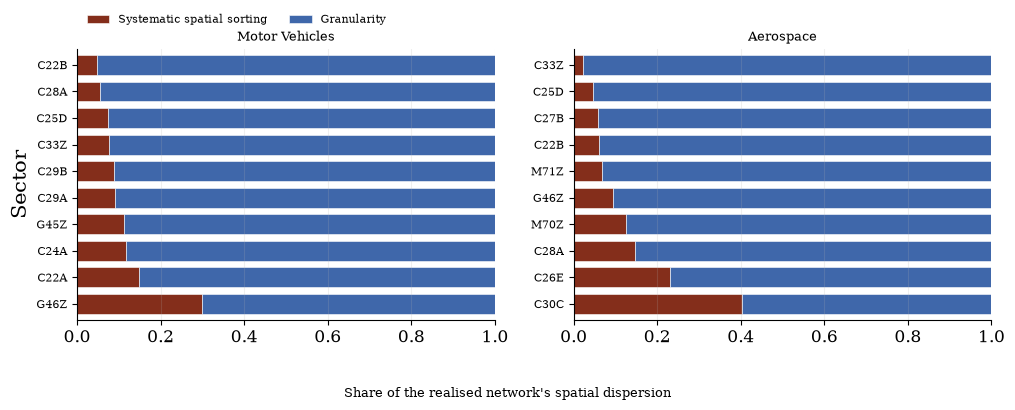

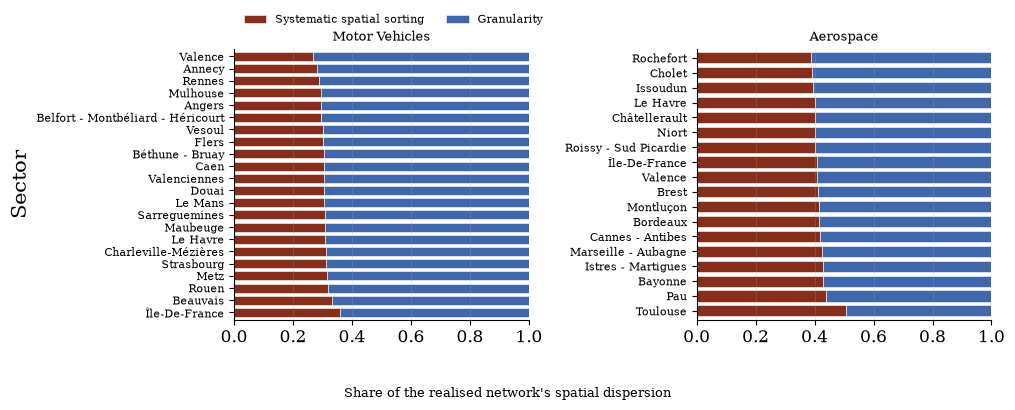

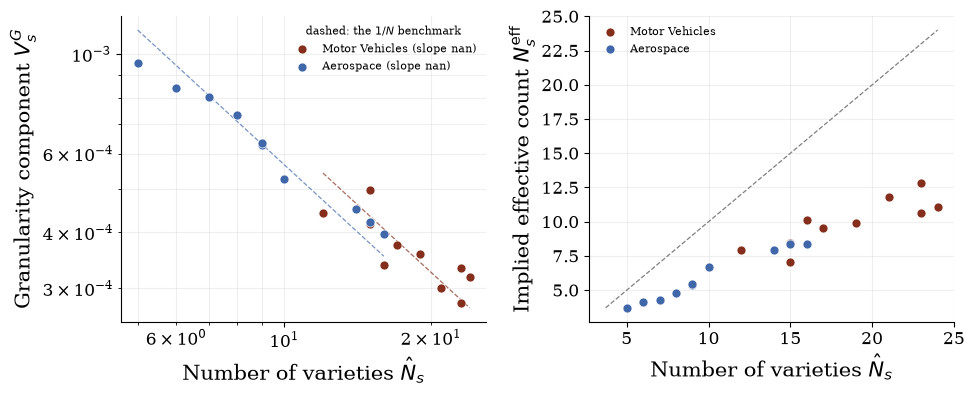

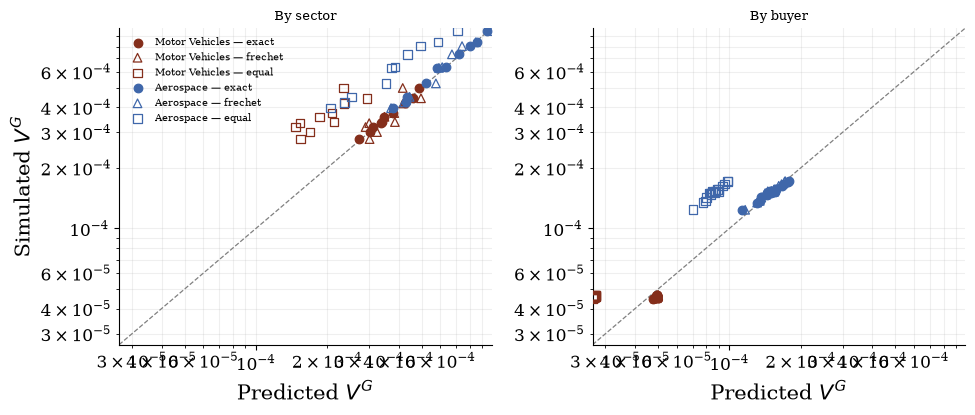

In [110]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
nv = {}
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    name = cfg.get("display_name", industry)

    print(f"\n=== [{industry}, mu = {MU}] " + "=" * 46)
    try:
        # both levels plus the theory check, in one call
        nv[name] = network_variance_report(data)
        display(nv[name]["by_sector"].round(5))
        display(nv[name]["theory_by_buyer"].round(5))
        display(nv[name]["sector"].drop(columns=["v_systematic_raw"]).round(6).head(20))
    except NameError as e:
        print(f"  network variance decomposition skipped: {e}. This test reads the"
              " realised economy, so it needs the amplification section's parquet"
              " helpers — run that definition cell first.")
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  network variance decomposition skipped: {type(e).__name__}: {e}")

_of = globals().get("out_folder")
if nv:
    sec = [(k, v["by_sector"]) for k, v in nv.items()]
    buy = [(k, v["buyer"]) for k, v in nv.items()]
    tri = [(k, v["theory_by_sector"], v["theory_by_buyer"]) for k, v in nv.items()]

    plot_network_variance(
        sec, save_to=f"{_of}/network_variance_mu{MU}.pdf" if _of else None)
    plt.show()
    plot_network_variance(
        buy, label_col="region",
        save_to=f"{_of}/network_variance_buyer_mu{MU}.pdf" if _of else None)
    plt.show()
    plot_granularity_variety_scaling(
        sec, save_to=f"{_of}/granularity_variety_scaling_mu{MU}.pdf" if _of else None)
    plt.show()
    plot_network_variance_theory(
        tri, save_to=f"{_of}/network_variance_theory_mu{MU}.pdf" if _of else None)
    plt.show()

# Amplification and spatial diffusion of downstream shocks

Section 5.1 of the paper. A demand shock lands on a downstream region; the model says how
much upstream activity it generates and where that activity goes. Those are two different
questions, and the second splits into three more, so the section is run as **seven tests**
taken one at a time.

| | Question | Statistic | What the answer looks like |
|---|---|---|---|
| 1 | How large is the response? | $D_r = 1 + \sum_l X_{lr}$ | A number near 1.85, nearly flat across regions — and flat for a structural reason: neither $T$ nor $\alpha$ enters $D_r$ |
| 2 | Is that large? | Leontief multipliers from the IO table | The model captures one upstream tier; the benchmark says what share of the aggregate that is |
| 3 | How far does the response travel? | $d_r$, the average sourcing distance | ~350 km in both industries — a level that identifies nothing on its own |
| 4 | Which force keeps the euro close? | $d_r$ with one force switched off | Auto held close by capability, aero by proximity |
| 5 | Where does the response land? | concentration and commonality of $\omega_r$ | Hub-and-spoke = concentrated **and** common |
| 6 | How much does the region keep? | $L_r(d)$ | The sign reversal: in aero, capability *lowers* the local share |
| 7 | What does finite $N_s$ cost? | granular vs continuum | The expected shares are invariant; the **support** is not |

Tests 1–2 are about the SIZE of the response, 3–6 about its INCIDENCE. Test 7 is not a
caveat on the others but a measurement in its own right: with $N_s$ finite the network is a
random object, and what granularity moves is how many origins one shock reaches.

**Three conventions set the LEVEL of $D_r$ and are worth stating before any number is read.**
`share` in `suppliers.parquet` is `exp_val`, a share of the downstream firm's UNIT COST, and
the markup $\mu$ is not applied — the published figure's convention. The parquet's
`intermediate_derivative` is that quantity renormalised WITHIN intermediates, so it sums to
one and is *not* an amplification measure. And the model has one upstream tier, so $D_r$ is
the whole of its amplification, with no round-2 Leontief term — which is exactly what test 2
puts a number on.

## Definitions

The four cells below define everything the seven tests use. They are kept together rather
than split test by test because the objects are shared: every test after the first is built
on the same diffusion frame, and the counterfactual regimes feed tests 4, 5 and 6 alike.
Run these four, then any test on its own.


In [111]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid
# The radii every function below defaults to. It is a PRIVATE copy of the Constants
# cell's `AMPLIFICATION_RADII`, so re-running that cell cannot clobber an edit here
# and the section still runs when only the definition cells have been executed.
_DEFAULT_RADII = (AMPLIFICATION_RADIUS_KM, 200)


def build_diffusion_frame(data, value_col="share", per_replication=False):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    # The parquet holds `n_rep` INDEPENDENT realisations of the finite-variety economy
    # (see the section header). Pooling and dividing by `n_rep` gives E[X_lr], on which
    # D_r -- linear in the euros -- is the exact expectation. `per_replication=True`
    # keeps the realisations apart instead, which is what the dispersion needs.
    keys = ["ze2010_downstream", "ze2010"]
    has_rep = "replication" in sup.columns
    n_rep = int(sup["replication"].nunique()) if has_rep else 1
    if per_replication and has_rep:
        keys = ["replication"] + keys
        scale = 1.0
    else:
        scale = 1.0 / n_rep
    agg = (sup.groupby(keys, as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    agg["upstream_sales"] *= scale
    agg["n_links"] = agg["n_links"] * scale
    shocked = np.sort(sup["ze2010_downstream"].unique())

    levels = ([np.sort(sup["replication"].unique())] if keys[0] == "replication" else []) \
        + [shocked, np.arange(1, R + 1)]
    grid = pd.MultiIndex.from_product(levels, names=keys).to_frame(index=False)
    df = grid.merge(agg, on=keys, how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")


# --- The same shock, with one force switched off ----------------------------
#
# Where a shock goes is decided by the Ricardian competition, which is closed form
# (`sourcing_geometry`, defined in the comparative-advantage section above and reused
# here rather than duplicated). So the propagation can be recomputed with either force
# removed without re-simulating or re-estimating anything.

# The two switches, each applied alone. Turning BOTH off — the uniform 1/n draw over
# the sector's modelled cells — is still supported by `sourcing_geometry` and is what the
# gate pins the closed form against, but it is not reported: a benchmark in which nothing
# selects among cells is not a counterfactual economy, and reading the two real regimes
# against it invites the reader to treat "chance" as the null the model is tested against.
CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0)}

# The realised economy is drawn beside the regimes wherever both appear, so it needs a
# colour of its own: sharing "Both forces"' would make the granularity gap invisible.
CF_COLORS = {"Realised": (0.32, 0.32, 0.32),
             "Both forces": toulouse_color,
             "Distance only": sim_color,
             "Comparative advantage only": (0.45, 0.60, 0.45),
             "Neither": (0.72, 0.72, 0.72)}    # kept for a caller that asks for it


def _parquet_sector_index(data, sup):
    """
    The model's 0-based sector index for every row of `suppliers.parquet`.

    The parquet's `A129` column holds the model's OWN index 1..S, not the A129 code —
    the column glossary says so, and `main.jl` writes `sectors = s`. It is read as such
    and then cross-checked: a column that does not fit 1..S is tried against
    `sector_names` before the function gives up, so a file written with real codes is
    NAMED rather than silently mapped onto the wrong sectors.
    """
    S = data["S"]
    col = sup["A129"]
    if pd.api.types.is_numeric_dtype(col):
        idx = col.to_numpy().astype(int) - 1
        if idx.size and idx.min() >= 0 and idx.max() < S:
            return idx
    name_of = {str(c): s for s, c in enumerate(data["sector_names"])}
    mapped = col.astype(str).str.strip().map(name_of)
    if mapped.notna().all():
        return mapped.to_numpy().astype(int)
    bad = sorted(set(col[mapped.isna()].astype(str)))[:5]
    raise ValueError(
        f"cannot place suppliers.parquet's A129 values {bad} among the model's S = {S} "
        f"sectors {list(data['sector_names'])} — the column should be the model index "
        "1..S, as main.jl writes it.")


def counterfactual_diffusion_frame(data, alpha=None, equalise_T=False,
                                   value_col="share", diffusion=None, verbose=True):
    """
    The same diffusion frame with the upstream euros REALLOCATED across cells by the
    closed-form win probabilities of a counterfactual regime.

    What is held fixed is what the model makes a cost-share object: how much of a
    downstream region's euro leaves for upstream at all, and how that splits across
    SECTORS. Neither involves T or alpha — the section header derives
    $D_r = 1 + (1-\\Omega_L)(P_r/c_r)^{1-\\lambda}$, in which the comparative-advantage
    parameters simply do not appear. What the two forces decide is where INSIDE a sector
    the euro lands, so

        X_{lr} = sum_s spend_{sr} * rho^{regime}_{lrs},

    with `spend` read off the realised economy and rho from `sourcing_geometry`:
    `alpha=0` switches distance off, `equalise_T=True` switches comparative advantage
    off, both switches off is the uniform benchmark.

    Two consequences, both worth stating before the figures are read.

    Since sum_l rho = 1 for every (sector, buyer), the TOTAL upstream sales of every
    shocked region — hence $D_r$ — is identical under every regime. Cancelling a channel
    moves a shock in space; it does not change its size. That is a property of the
    one-tier structure, not an approximation, and it is why the counterfactual figures
    are all about $L_r(d)$ and none of them re-draws $D_r$.

    And "Both forces" is the closed-form EXPECTATION of the allocation, whereas the
    parquet is one realised finite-variety draw of it: the closed form spreads mass over
    every modelled cell, the realisation concentrates it on the varieties that happened
    to win. The two therefore differ, and the gap is simulation noise plus that
    granularity — `counterfactual_amplification` prints it rather than hiding it, and
    "Both forces" (not the realised frame) is the right baseline to read the other three
    regimes against.
    """
    base = (build_diffusion_frame(data, value_col) if diffusion is None
            else diffusion).copy()
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the counterfactual needs the realised sector-level spending.")

    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    col_of_rd = {int(z): j for j, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])[value_col].sum())
    # `sup` pools `n_rep` realisations of the finite-variety economy, so the sector spend
    # is AVERAGED over them, exactly as `build_diffusion_frame` averages the euros it
    # reallocates. Without this every regime would allocate `n_rep` euros where the base
    # frame allocates one and $D_r$ — linear in those euros — would come out `n_rep`
    # times too large. $L_r(d)$ is a ratio within a regime and would not have shown it,
    # which is why the division is here rather than left to the reader.
    if "replication" in sup.columns:
        spend = spend / float(sup["replication"].nunique())

    R = data["R"]
    X = np.zeros((R, R))                      # [upstream region, shocked region], 0-based
    dropped = []
    for (rd, s), tot in spend.items():
        blk = geom["by_sector"].get(int(s))
        j = col_of_rd.get(int(rd))
        if blk is None or j is None:
            dropped.append((int(rd), int(s), float(tot)))
            continue
        X[blk["cells"], int(rd) - 1] += float(tot) * blk["rho"][:, j]
    if dropped and verbose:
        lost = sum(t for _, _, t in dropped)
        print(f"  [counterfactual] {len(dropped)} (buyer, sector) pairs have no modelled "
              f"cells or no downstream column and were dropped "
              f"({lost:.3g} of upstream sales): {[(r, s) for r, s, _ in dropped[:4]]}")

    out = base.drop(columns=[c for c in ("upstream_sales", "n_links") if c in base.columns])
    out["upstream_sales"] = X[out["ze2010"].to_numpy() - 1,
                              out["ze2010_downstream"].to_numpy() - 1]
    out["n_links"] = np.nan       # a closed-form allocation has no realised linkages
    out.attrs["regime"] = ("alpha=0 " if alpha == 0 else "") + ("T equalised" if equalise_T else "")
    out.attrs["value_col"] = value_col
    return out


def counterfactual_frames(data, regimes=CF_REGIMES, value_col="share", diffusion=None,
                          verbose=True):
    """One reallocated diffusion frame per regime, built once off a shared base frame."""
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    return {label: counterfactual_diffusion_frame(data, value_col=value_col,
                                                  diffusion=base, verbose=verbose, **kw)
            for label, kw in regimes.items()}


def counterfactual_amplification(data, regimes=CF_REGIMES, radii=None, value_col="share",
                                 frames=None, diffusion=None, verbose=True):
    """
    One row per (shocked region, regime): the amplification coefficient, the share of
    upstream sales within each radius, and the mean distance those sales travel.

    The realised economy is reported too, as the regime `"Realised"`, so the closed-form
    "Both forces" row can be read against the draw it is the expectation of.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else frames)

    rows = {"Realised": amplification_summary(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    rows.update({lab: amplification_summary(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    out = pd.concat([s.assign(regime=lab) for lab, s in rows.items()])
    out["regime"] = pd.Categorical(out["regime"], categories=list(rows), ordered=True)
    out = out.reset_index().set_index(["ze2010_downstream", "regime"]).sort_index()

    if verbose:
        amp = out["amplification"].unstack("regime")
        spread = float((amp[list(frames)].max(axis=1) - amp[list(frames)].min(axis=1)).max())
        gap = float((amp["Both forces"] - amp["Realised"]).abs().max())
        col = f"share_within_{int(radii[0])}km"
        sh = out[col].unstack("regime")
        print(f"  [counterfactual] D_r is identical across regimes to {spread:.2e} "
              f"(it must be: sum_l rho = 1), and matches the realised D_r to {gap:.2e}")
        print(f"  [counterfactual] {col}: realised {sh['Realised'].mean():.3f} vs "
              f"closed-form both-forces {sh['Both forces'].mean():.3f} — the gap is "
              "granularity, not a different economy")
    return out


def counterfactual_summary(data, regimes=CF_REGIMES, radii=None, value_col="share",
                           detail=None, frames=None, diffusion=None, verbose=False):
    """
    The counterfactual in one table: per regime, how much of the shock stays within each
    radius and how far it travels on average.

    Two averages per radius, because they answer different questions: `share_within_*`
    is the mean across shocked regions (the typical region), `weighted_*` weights each
    region by the upstream sales it generates (the aggregate euro).
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    det = (counterfactual_amplification(data, regimes=regimes, radii=radii,
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion, verbose=verbose)
           if detail is None else detail)
    w = det["upstream_sales"]
    out = pd.DataFrame({
        "amplification": det["amplification"].groupby(level="regime", observed=True).mean(),
        "mean_upstream_distance":
            (det["mean_upstream_distance"] * w).groupby(level="regime", observed=True).sum()
            / w.groupby(level="regime", observed=True).sum(),
    })
    for d in radii:
        c = f"share_within_{int(d)}km"
        out[c] = det[c].groupby(level="regime", observed=True).mean()
        out[f"weighted_{c}"] = ((det[c] * w).groupby(level="regime", observed=True).sum()
                                / w.groupby(level="regime", observed=True).sum())
    return out

# --- The economy is FINITE-VARIETY, and the parquet has to say so ------------
#
# The model gives sector s exactly N_s varieties; the count moment calibrates N_hat_s
# against the share of cells hosting no supplier. `N_rho` is a DIFFERENT object -- the
# number of draws integrating over the variety continuum, `max(100, max_s N_HI)` in
# load_parameters.jl, one to two orders of magnitude larger. A post-hoc economy written
# over N_rho draws is the N_s -> infinity limit of the model, not the model, and the
# symptom is visible without any reference: a shock reaches nearly EVERY commuting zone
# while the fitted count moment says three quarters of the cells host nobody.


def supplier_count_check(data, verbose=True):
    """
    Does `suppliers.parquet` carry `N_hat_s` varieties per sector, as the model says?

    The exact test counts DISTINCT VARIETY INDICES within a (sector, replication): the
    model gives sector s exactly N_s of them, every one of which is won by somebody, so
    the count must equal `N_hat_s` on the nose.

    Counting distinct FIRMS cannot do that job, and the reason is worth stating because
    it is the fallback path. One variety is won by different cells for different buyers,
    so it yields between one and `R_downstream` firms; a legitimate variety economy can
    therefore show up to `R_downstream` firms per variety, and a draw-count economy
    shows `N_rho / N_hat_s`, which on the real data is of the same order. The two are
    separable only through the variety index itself. A tree written before the parquet
    carried one falls back to the firm count, and the verdict is then a BOUND: above
    `R_downstream` firms per variety the economy cannot be a variety economy at all.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir', '<step>')}/.")

    s_idx = _parquet_sector_index(data, sup)
    rep = (sup["replication"].to_numpy() if "replication" in sup.columns
           else np.zeros(len(sup), dtype=int))
    exact = "variety" in sup.columns
    unit = sup["variety"] if exact else sup["SIREN"]
    frame = pd.DataFrame({"sector": s_idx, "replication": rep,
                          "unit": unit.to_numpy()})
    per = (frame.drop_duplicates(["sector", "replication", "unit"])
                .groupby(["sector", "replication"]).size()
                .groupby("sector").mean())

    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    col = "varieties_in_parquet" if exact else "firms_per_sector"
    out = pd.DataFrame({
        "sector": [str(c) for c in data["sector_names"]],
        "N_hat": (np.asarray(n_hat, dtype=float) if n_hat is not None
                  else np.full(data["S"], np.nan)),
        col: per.reindex(range(data["S"])).to_numpy(),
    }).set_index("sector")
    out["ratio"] = out[col] / out["N_hat"]
    out["n_replications"] = int(pd.Series(rep).nunique())
    out.attrs["exact"] = exact

    R_d = int(sup["ze2010_downstream"].nunique())
    tol = 1e-9 if exact else float(R_d)
    ok = bool(out["N_hat"].notna().all()) and bool((out["ratio"] - 1.0).max() <= tol)
    if verbose:
        print(out.round(2).to_string())
        if out["N_hat"].isna().any():
            print("  [UNKNOWN] no N_hat_s on disk (post_hoc_N_hat.npy or "
                  "granular_diagnostics.npz) — nothing to check the count against.")
        elif not exact:
            print(f"  [BOUND] no `variety` column: counting FIRMS, which a variety "
                  f"economy inflates by at most R_downstream = {R_d}. "
                  + (f"ratio max {out['ratio'].max():.1f} <= {R_d}: consistent with a "
                     "variety economy, though not proof of one."
                     if ok else
                     f"ratio max {out['ratio'].max():.1f} > {R_d}: this economy was "
                     "solved on the estimation DRAWS, not on N_hat_s varieties. "
                     "Re-run main.jl's post-hoc block."))
        elif ok:
            print(f"  [OK] {out['n_replications'].iloc[0]} realisation(s), exactly "
                  "N_hat_s varieties per sector.")
        else:
            print("  [FAIL] the variety count in the parquet is not N_hat_s.")
    return out


def _n_hat_from_diagnostics(data):
    """`N_hat_s` from `granular_diagnostics.npz`, the fallback when the post-hoc run
    predates `post_hoc_N_hat.npy`. It is written only when its own step ran, so it can
    be stale relative to the parquet — which is why the post-hoc file is preferred."""
    for step in (data.get("step_dir", "step3"), "step3", "step1"):
        p = data["folder"] / step / "granular_diagnostics.npz"
        if p.exists():
            with np.load(p, allow_pickle=True) as z:
                for k in ("N_hat", "N_s", "N_hat_s"):
                    if k in z.files:
                        return np.asarray(z[k], dtype=float)
    return None


# --- Averaging over realisations, and what granularity costs ----------------
#
# With N_s finite the network is a RANDOM object, so no single realisation is a result.
# Two different things follow, and they must not be run together.
#
# (1) The AVERAGE network. `build_diffusion_frame` divides the pooled euros by the
#     number of realisations, so every downstream object is built on E[X_lr]. D_r is
#     linear in those euros, so the averaged frame gives E[D_r] exactly.
#
# (2) The DISPERSION, which is content and not error. `L_r(d)` is a ratio, so its mean
#     across realisations is not the ratio of the means; more to the point, the SUPPORT
#     is what granularity moves — a buyer sources N_hat_s varieties per sector, so it
#     reaches a few dozen origins, not every commuting zone.
#
# And granularity itself is the deviation from the N_s -> infinity economy, which is
# `suppliers_continuum.parquet`: the SAME parameters solved on the estimation draws.
# The two differ for a reason that is not sampling noise. The within-sector index
# p_sr = [N_s^{-1} sum_rho p_rho^{1-nu}]^{1/(1-nu)} is nonlinear in the draws, so its
# EXPECTATION moves with N_s; with lambda < 1 a higher intermediate price index raises
# the intermediate share, hence D_r. That is the price-index channel.


def replication_summaries(data, radii=None, value_col="share", diffusion=None):
    """
    `amplification_summary` computed SEPARATELY for each realisation of the economy.

    Indexed by (replication, shocked region). A tree with no `replication` column comes
    back with the single realisation labelled 0, so callers need no special case.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    df = (build_diffusion_frame(data, value_col, per_replication=True)
          if diffusion is None else diffusion)
    if "replication" not in df.columns:
        df = df.assign(replication=0)
    out = []
    for b, sub in df.groupby("replication"):
        s = amplification_summary(data, radii=radii, value_col=value_col,
                                  diffusion=sub.drop(columns="replication"))
        out.append(s.assign(replication=b))
    return (pd.concat(out).set_index("replication", append=True)
              .reorder_levels(["replication", "ze2010_downstream"]).sort_index())


def granular_band(data, radii=None, value_col="share", per_rep=None):
    """
    Per shocked region, each quantity's mean and spread ACROSS realisations.

    The mean of `share_within_d` here is the mean of a RATIO — the direct estimate of
    E[L_r(d)] — where the averaged-frame figure is a ratio of means; they differ at
    O(1/n_rep). `supplier_cells` is the one that changes character: on the averaged
    frame it is the UNION of origins over all realisations, here it is how many origins
    a single shock actually reaches, which is the granular object.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    per = (replication_summaries(data, radii=radii, value_col=value_col)
           if per_rep is None else per_rep)
    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    g = per.groupby(level="ze2010_downstream")
    out = pd.DataFrame({"region": g["region"].first()})
    for c in cols:
        out[f"{c}"] = g[c].mean()
        out[f"{c}_sd"] = g[c].std(ddof=1)
    out["n_replications"] = g.size()
    return out


def granularity_report(data, radii=None, value_col="share", verbose=True):
    """
    The finite-variety economy against its infinite-variety limit, quantity by quantity.

    Returns one row per quantity: the granular mean (over realisations), its spread
    across realisations, the continuum value, and the gap. The gap is granularity; the
    spread is how much a single draw can move the answer.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    cont = data.get("suppliers_continuum")
    if cont is None:
        raise FileNotFoundError(
            "no suppliers_continuum.parquet beside suppliers.parquet — the "
            "infinite-variety benchmark is written by main.jl's post-hoc block under "
            "GRANULAR; a tree without it predates the finite-variety economy.")

    per = replication_summaries(data, radii=radii, value_col=value_col)
    band = granular_band(data, radii=radii, per_rep=per)
    ref = amplification_summary(
        data, radii=radii, value_col=value_col,
        diffusion=build_diffusion_frame(dict(data, suppliers=cont), value_col))

    cols = ["amplification", "mean_upstream_distance", "supplier_cells"] + \
           [f"share_within_{int(d)}km" for d in radii]
    rows = []
    for c in cols:
        # across regions: the granular economy's mean, the spread a single draw carries,
        # and the same statistic in the N_s -> infinity economy
        rows.append({"quantity": c,
                     "granular_mean": band[c].mean(),
                     "sd_across_draws": band[f"{c}_sd"].mean(),
                     "continuum": ref[c].mean()})
    out = pd.DataFrame(rows).set_index("quantity")
    out["granularity"] = out["granular_mean"] - out["continuum"]
    out["granularity_rel"] = out["granularity"] / out["continuum"].replace(0, np.nan)
    out.attrs["n_replications"] = int(per.index.get_level_values("replication").nunique())

    if verbose:
        n = out.attrs["n_replications"]
        print(f"  granularity = the finite-variety economy minus its N_s -> infinity "
              f"limit ({n} realisations):")
        print(out.round(4).to_string())
        gap = out.loc["supplier_cells"]
        print(f"  a shock reaches {gap['granular_mean']:.0f} origins with N_hat_s "
              f"varieties against {gap['continuum']:.0f} in the continuum — the "
              "extensive margin is the whole of what granularity is for.")
    return out



In [112]:
# The two Figure-6 panels (the second with every radius nested on one bar), the radius
# sweep the fixed 100 km hides, the two together in one scatter, and the same shock
# propagated with one force switched off.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def _ring_colors(n):
    """
    Colours for nested radii: the headline radius in the section's own colour, every
    ring beyond it in blue, lightening outward so the order of the radii is visible
    without reading the legend.
    """
    if n <= 1:
        return [toulouse_color]
    blue = np.asarray(sim_color, dtype=float)
    rings = [tuple(1.0 - (1.0 - blue) * (1.0 - 0.30 * k / max(1, n - 2)))
             if n > 2 else tuple(blue) for k in range(n - 1)]
    return [toulouse_color] + rings


def plot_local_share(data, radii=None, value_col="share", summary=None, radius_km=None,
                     sort_by="share_within_100km", order=None, xmax=None, ax=None, figsize=None,
                     save_to=None, title=None):
    """
    Bottom panel of Figure 6, with every radius on the SAME bar.

    $L_r(d)$ is a CDF in $d$: the 200 km share CONTAINS the 100 km one. Side-by-side
    bars would hide that nesting and invite the two numbers to be read as competing
    measurements. Drawn nested instead — the widest radius first, each narrower one
    painted over it, all fully opaque — one bar says "this much stays within 100 km, and
    this much more is picked up by going out to 200 km", which is what the nesting
    means. Regions are sorted by the headline (smallest) radius, so the inner segments
    form a staircase and the blue extensions are read against it.

    `xmax` pins the axis. Left to itself it tracks the widest bar, which uses the panel
    but gives the two industries different scales; pass the same number to both when the
    figures are to be compared side by side.
    """
    if radii is None:
        radii = (radius_km,) if radius_km is not None else _DEFAULT_RADII
    radii = tuple(sorted({float(r) for r in np.atleast_1d(radii)}))
    cols = [f"share_within_{int(r)}km" for r in radii]

    s = (amplification_summary(data, radii=radii, value_col=value_col)
         if summary is None else summary)
    missing = [c for c in cols if c not in s.columns]
    if missing:
        raise KeyError(f"{missing} not in the summary — pass `radii={radii}` to "
                       "amplification_summary, or let this function build it.")
    s = s.reindex(order) if order is not None else s.sort_values(sort_by or cols[0])

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    colors = _ring_colors(len(radii))
    y = np.arange(len(s))
    handles = []
    for i in range(len(radii) - 1, -1, -1):          # widest first, narrowest on top
        lab = (f"within {radii[0]:g} km" if i == 0
               else f"{radii[i-1]:g}–{radii[i]:g} km")
        handles.append(ax.barh(y, s[cols[i]].to_numpy(), height=0.75, color=colors[i],
                               alpha=1.0, label=lab, zorder=2 + (len(radii) - i)))
    ax.set_yticks(y)
    ax.set_yticklabels(s["region"].astype(str))
    ax.set_ylim(-0.7, len(s) - 0.3)
    # no bar comes near 1, and a mostly empty panel is harder to read, not more honest:
    # the axis tracks the widest bar unless `xmax` pins it
    top = float(s[cols[-1]].max())
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    # the means ride on the x label: inside the panel they would sooner or later land on
    # a bar, and in the title they would run into the legend
    ax.set_xlabel("Share of the upstream sales a shock generates\n"
                  + "mean  " + ",  ".join(f"{s[c].mean():.3f} within {r:g} km"
                                          for r, c in zip(radii, cols)))
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the legend sits ABOVE the axes: with a bar per commuting zone there is no corner
    # inside the plot it can occupy without covering the regions it explains
    ax.legend(handles=handles[::-1], frameon=False, fontsize=9, ncol=len(radii),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    ax.set_title(title or (f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"),
                 fontsize=10, loc="right")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


# The 100 km share is a number attached to a PLACE, and the contrast between the two
# industries is a contrast of geography: aerospace concentrates on two hubs, motor
# vehicles spreads over a corridor. A bar chart sorted by value hides exactly that,
# so the same column is also drawn on the map of commuting zones.
#
# The colour scale is PINNED by default and shared by both panels. The whole content
# of the pair is that aerospace reaches 0.42 where motor vehicles never passes 0.18;
# a per-panel scale would rescale that away and paint the two maps alike.
LOCAL_SHARE_MAP_VLIM = (0.0, 0.45)
LOCAL_SHARE_MAP_VLIM_WIDE = (0.0, 0.60)   # the same scale, pinned for the 200 km map


def plot_local_share_map(data, radius_km=None, value_col="share", summary=None,
                         diffusion=None, vlim=LOCAL_SHARE_MAP_VLIM, cmap="viridis",
                         n_label=0, missing_color="0.88", ax=None, figsize=None,
                         save_to=None, title=None, cbar=True):
    """
    $L_r(d)$ on the map: every SHOCKED downstream commuting zone coloured by the share
    of the upstream sales its own shock keeps within `radius_km`.

    Only downstream zones carry a value — the object is indexed by where the shock
    STARTS, not by where the euros land — so every other zone is drawn in
    `missing_color`. That is not missing data: those zones host no downstream producer
    and there is no shock to originate there.

    `vlim` pins the colour scale so the two industries are comparable; a value outside
    it would be clipped, so an exceedance is reported rather than silently flattened.

    `n_label` names that many of the most local zones on the map. It defaults to ZERO:
    the figure's content is the SHAPE of the colour field — a couple of bright hubs
    against a dark ground, or an even mid-tone corridor — and a name pinned to the
    brightest patch pulls the eye to one zone and invites the pair to be read as a
    ranking of places rather than as two geographies. The zones that matter are named in
    the text, where they can be given their number.
    """
    fr = data.get("france")
    # a GeoDataFrame, not merely a table of codes: the loader leaves `france` at None
    # when geopandas is absent, and a run tree assembled without the geometry can still
    # carry the names, so the geometry is what is checked for
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the map cannot be drawn.")

    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col,
                               diffusion=diffusion)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` to "
                       "amplification_summary, or let this function build it.")

    # the summary is indexed by the MODEL's downstream region index; the map is keyed on
    # the ZE code, so it goes through the same index -> code table as every label here
    code_of = _region_labels(data).set_index("index")["ze2010"]
    s["ze2010"] = _as_ze_string(code_of.reindex(s.index))

    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    geo = geo.merge(s[["ze2010", col, "region"]], on="ze2010", how="left")
    shocked = geo[geo[col].notna()]
    if shocked.empty:
        raise ValueError("no shocked commuting zone matched france.gpkg on `ze2010` — "
                         "the codes are formatted differently on the two sides.")

    vmin, vmax = (float(shocked[col].min()), float(shocked[col].max())) if vlim is None \
        else (float(vlim[0]), float(vlim[1]))
    over = shocked.loc[shocked[col] > vmax, "region"]
    if len(over):
        print(f"  [map] {len(over)} zone(s) above the pinned vmax = {vmax:g} and so "
              f"clipped: {', '.join(map(str, over))} — widen LOCAL_SHARE_MAP_VLIM.")
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo[geo[col].isna()].plot(facecolor=missing_color, ax=ax, edgecolor="white",
                              linewidth=0.25)
    shocked.plot(column=col, ax=ax, norm=norm, cmap=cmap, edgecolor="black",
                 linewidth=0.35)

    for _, row in shocked.nlargest(n_label, col).iterrows() if n_label else ():
        p = row.geometry.representative_point()
        ax.annotate(str(row["region"]), (p.x, p.y), fontsize=8, xytext=(6, 4),
                    textcoords="offset points", color="black",
                    path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])

    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=11)
    if cbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cb = ax.figure.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.035,
                                pad=0.02, aspect=35)
        cb.set_label(f"Share of upstream sales within {radius_km:g} km", fontsize=9)
        cb.ax.tick_params(labelsize=8)
        cb.minorticks_off()
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def plot_counterfactual_local_share(data, regimes=CF_REGIMES, radius_km=None,
                                    value_col="share", detail=None, frames=None,
                                    diffusion=None, include_realised=True, xmax=None,
                                    figsize=None, save_to=None):
    """
    The same shock, propagated with one force switched off: the share of upstream sales
    staying within `radius_km`, region by region, one bar per regime.

    Read as two switches against the estimated allocation, not against chance. The step
    from `Both forces` to `Distance only` is what comparative advantage was doing; the
    step to `Comparative advantage only` is what proximity was doing. The first is the
    one with content: $T$ pulls sourcing towards a few favoured areas wherever they
    happen to be, so removing it pushes the local share UP for most regions and down
    only for those that host a favoured area — a SIGNED prediction, which is why the two
    industries can disagree. Removing distance can only push it down.

    Regions keep the order of the previous figure (the realised share within the same
    radius), so the two are read together. $D_r$ is not re-plotted: it is identical in
    every regime by construction, which is the whole point — the counterfactual moves a
    shock in space without changing its size.
    """
    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    det = (counterfactual_amplification(data, regimes=regimes, radii=(radius_km,),
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion)
           if detail is None else detail)
    col = f"share_within_{int(radius_km)}km"
    if col not in det.columns:
        raise KeyError(f"{col} is not in the detail table — pass "
                       f"`radii=({radius_km},)` to counterfactual_amplification.")

    wide = det[col].unstack("regime")
    order = wide["Realised"].sort_values().index      # the order of the previous figure
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    # one row per region, sized so each of the regimes keeps a legible bar
    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * len(labels) * len(wide))))
    y = np.arange(len(wide))
    height = 0.8 / len(labels)
    for k, lab in enumerate(labels):
        off = ((len(labels) - 1) / 2 - k) * height        # first label on top of the group
        ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                color=CF_COLORS.get(lab, toulouse_color),
                edgecolor="white", linewidth=0.4, label=lab)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    top = float(np.nanmax(wide.to_numpy()))
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(3, len(labels)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_distance(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 include_realised=True, units="pct", baseline="Both forces",
                                 kind="bar", annotate_km=True, xmin=None, xmax=None,
                                 figsize=None, save_to=None):
    """
    The per-buyer companion of `plot_counterfactual_local_share`: the average sourcing
    distance `d_r` of each shocked region, one mark per regime, regions in the SAME
    order as that figure (ascending realised local share) so the two read together.

    `units` is the design decision, and it is the one that makes the figure readable.
    Every `d_r` sits between roughly 250 and 450 km, so in KILOMETRES the entire
    counterfactual lives in the last sixth of the axis and the eye reads the LEVEL of
    the sourcing distance -- which is common across regions and carries no information --
    rather than its MOVEMENT, which is the whole content. `units="pct"` (the default)
    therefore plots each regime as a percentage deviation from `baseline` ("Both forces",
    the estimated economy), so the origin IS the baseline: a bar's length is then the
    effect itself, read against a zero that means something, and the honest-zero
    objection that forced `kind="point"` in kilometres no longer applies. The level is
    not thrown away -- with `annotate_km=True` each row carries its baseline `d_r` in
    kilometres at the right margin, so the percentage can be converted back to a
    distance buyer by buyer. `units="km"` keeps the original levels figure.

    `kind` still switches bars (length from the origin) against points joined by a rule
    (position only, so a cropped window is legitimate). In percentage units the baseline
    regime is exactly zero by construction and is drawn as the zero rule, not as a
    series.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    if kind not in ("bar", "point"):
        raise ValueError(f"kind must be 'bar' or 'point', got {kind!r}.")
    if units not in ("pct", "km"):
        raise ValueError(f"units must be 'pct' or 'km', got {units!r}.")

    wide = det["mean_upstream_distance"].unstack("regime")
    # the ordering of plot_counterfactual_local_share, so the two panels line up
    share_cols = [c for c in det.columns if c.startswith("share_within_")]
    if share_cols and "Realised" in wide.columns:
        order = det[sorted(share_cols)[0]].unstack("regime")["Realised"].sort_values().index
    else:
        order = wide.iloc[:, 0].sort_values().index
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    base_km = None
    if units == "pct":
        if baseline not in wide.columns:
            raise KeyError(f"baseline regime {baseline!r} not among {list(wide.columns)}.")
        base_km = wide[baseline].astype(float)
        wide = wide.drop(columns=[baseline]).apply(
            lambda c: 100.0 * (c.astype(float) - base_km) / base_km)
        labels = [l for l in labels if l != baseline]

    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * max(len(labels), 1) * len(wide))))
    y = np.arange(len(wide))
    if kind == "bar":
        height = 0.8 / max(len(labels), 1)
        for k, lab in enumerate(labels):
            off = ((len(labels) - 1) / 2 - k) * height
            ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                    color=CF_COLORS.get(lab, toulouse_color),
                    edgecolor="white", linewidth=0.4, label=lab)
        lo = (min(0.0, float(np.nanmin(wide.to_numpy()))) * 1.05 if units == "pct"
              else 0.0) if xmin is None else xmin
    else:
        for yi, (_, row) in enumerate(wide.iterrows()):
            v = row.to_numpy(dtype=float)
            if np.isfinite(v).any():
                ax.plot([np.nanmin(v), np.nanmax(v)], [yi, yi], color="0.8",
                        linewidth=1.0, zorder=1)
        for lab in labels:
            ax.plot(wide[lab].to_numpy(), y, linestyle="none", marker="o", markersize=5,
                    color=CF_COLORS.get(lab, toulouse_color), label=lab, zorder=2)
        span = float(np.nanmax(wide.to_numpy()) - np.nanmin(wide.to_numpy()))
        lo = (np.nanmin(wide.to_numpy()) - 0.05 * span) if xmin is None else xmin
    hi = (np.nanmax(wide.to_numpy()) * 1.02 if units == "km"
          else float(np.nanmax(wide.to_numpy())) + 0.05 * (
              float(np.nanmax(wide.to_numpy())) - float(np.nanmin(wide.to_numpy())) + 1e-9)
          ) if xmax is None else xmax
    if units == "pct":
        ax.axvline(0.0, color="0.35", linewidth=1.0, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    ax.set_xlim(lo, hi)
    if units == "pct":
        ax.set_xlabel(f"Change in the mean distance travelled by the upstream euro "
                      f"(% of {baseline})")
    else:
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the level the percentages are taken against, so the figure never hides the km
    if units == "pct" and annotate_km and base_km is not None:
        for yi, idx in enumerate(wide.index):
            ax.annotate(f"{base_km.loc[idx]:.0f} km", xy=(1.005, yi),
                        xycoords=("axes fraction", "data"), va="center", ha="left",
                        fontsize=7.5, color="0.35", annotation_clip=False)
        ax.annotate(f"{baseline}\n(km)", xy=(1.005, 1.005),
                    xycoords="axes fraction", va="bottom", ha="left",
                    fontsize=7.5, color="0.35", annotation_clip=False)
    ax.legend(frameon=False, fontsize=9, ncol=min(3, max(len(labels), 1)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_profile(data, regimes=CF_REGIMES,
                                radii=(25, 50, 75, 100, 150, 200, 300, 500),
                                mark=None, value_col="share", frames=None,
                                diffusion=None, figsize=None, save_to=None):
    """
    The whole curve rather than one radius: $L_r(d)$ against $d$, median across shocked
    regions, one line per regime.

    A single radius can flatter a regime that happens to cross it steeply; the curves
    say whether a gap at 100 km is a level difference that persists or a crossing that
    closes by 200 km. The vertical distance from `Both forces` to each switched-off
    regime is what that force was contributing at every radius, and the SIGN of the first
    gap is what separates the two industries: where `Distance only` sits ABOVE `Both
    forces`, comparative advantage is sending the shock further away than proximity alone
    would.
    """
    mark = _DEFAULT_RADII if mark is None else mark
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base) if frames is None else frames)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    curves = {"Realised": local_share_profile(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    curves.update({lab: local_share_profile(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    for lab, p in curves.items():
        ax.plot(p.index, p["median"], marker="o", markersize=4,
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.6 if lab != "Realised" else 1.2, label=lab)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.99), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share within the radius (median region)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def amplification_report(data, radii=None, value_col="share", out_folder=None, show=True,
                         counterfactual=True, regimes=CF_REGIMES):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels
    (the second carrying every radius on one bar), the radius sweep, the joint scatter,
    the summary table, and the same shock propagated with one force switched off.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the headline radius — the one the scatter and the counterfactual bars
    use, and the one the nested bars sort on.

    The counterfactual block needs `best_params` and the estimated geometry. If the run
    tree carries no parameter vector, or the fit is a binned trade cost (where there is
    no single distance elasticity to switch off), it says so and the rest of the section
    is unaffected.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    # Does the economy carry N_hat_s varieties? Everything below is built on the
    # parquet, so a wrong variety count is not a detail of the input -- it is a
    # different model, and it is checked before any of it is reported.
    print(f"[{ind}, mu = {mu}]  variety count in suppliers.parquet:")
    try:
        supplier_count_check(data)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  variety-count check skipped: {type(e).__name__}: {e}")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    # what the finite variety count costs, quantity by quantity
    try:
        granularity_report(data, radii=radii, value_col=value_col)
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radii=radii, summary=summ, save_to=tag("local_share"))
    if show:
        plt.show()
    try:
        plot_local_share_map(data, radius_km=radii[0], summary=summ,
                             save_to=tag("local_share_map"))
        if show:
            plt.show()
        # the SAME map at the wider radius the empirical part works with. It needs its
        # own pinned scale: L_r is a CDF in d, so every value is larger at 200 km and
        # the 100 km window would clip the top of the aerospace distribution.
        if len(radii) > 1:
            plot_local_share_map(data, radius_km=radii[-1], summary=summ,
                                 vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                                 save_to=tag(f"local_share_map{int(radii[-1])}km"))
            if show:
                plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()

    if counterfactual:
        try:
            frames = counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                           diffusion=diff)
            det = counterfactual_amplification(data, regimes=regimes, radii=radii,
                                               value_col=value_col, frames=frames,
                                               diffusion=diff)
            plot_counterfactual_local_share(data, regimes=regimes, radius_km=radii[0],
                                            detail=det,
                                            save_to=tag("counterfactual_local_share"))
            if show:
                plt.show()
            # the same figure at the wider radius the reduced-form part works with
            if len(radii) > 1:
                plot_counterfactual_local_share(
                    data, regimes=regimes, radius_km=radii[-1], detail=det,
                    save_to=tag(f"counterfactual_local_share{int(radii[-1])}km"))
                if show:
                    plt.show()
            plot_counterfactual_profile(data, regimes=regimes, mark=radii, frames=frames,
                                        diffusion=diff,
                                        save_to=tag("counterfactual_profile"))
            if show:
                plt.show()
            plot_distance_distribution(data, regimes=regimes, detail=det,
                                       save_to=tag("counterfactual_distance"))
            if show:
                plt.show()
            # Two alternative readings of the SAME reallocation, drawn beside the two
            # above so the choice for the paper is made on the figures, not in the
            # abstract: d_r buyer by buyer (against the local-share bars) and the
            # density of d_r across buyers (against its cumulative curve).
            #
            # Each gets its OWN guard rather than riding the block's single try, so a
            # failure in one cannot silently take the other -- or be mistaken for the
            # figure never having been added. The block's outer handler prints one note
            # for everything after the point of failure, which is exactly the case where
            # a newly added figure looks absent rather than broken.
            for _lab, _fn, _stem in (
                    ("mean sourcing distance by region", plot_counterfactual_distance,
                     "counterfactual_distance_region"),
                    ("mean sourcing distance histogram", plot_distance_histogram,
                     "counterfactual_distance_hist")):
                try:
                    _fn(data, regimes=regimes, detail=det, save_to=tag(_stem))
                    if show:
                        plt.show()
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  {_lab} skipped: {type(e).__name__}: {e}")
            print("\n  the shock with one force switched off "
                  "(D_r is the same in every regime by construction):")
            print(counterfactual_summary(data, regimes=regimes, radii=radii,
                                         detail=det).round(3).to_string())
            print("\n  the distribution of d_r behind that mean, and how each force "
                  "shifts it quantile by quantile:")
            print(distance_distribution_report(data, regimes=regimes,
                                               detail=det).to_string())

            # WHERE the response lands, which both the mean distance and the barycentre
            # reduce away. Own guard, for the reason given at the two figures above: a
            # newly added block that fails should say so rather than look absent.
            try:
                inc = incidence_concentration_overlap(data, regimes=regimes,
                                                      frames=frames, diffusion=diff)
                incidence_summary(inc)
                summ.attrs["incidence"] = inc
                distance_normalisation(data, regimes=regimes, detail=det, diffusion=diff)
                # The two coordinates above are computed on `rho`, which carries no
                # N_s, so they describe the AVERAGE network. `n_eff` is convex and
                # `tv_common` is convex the other way, so a single draw of the
                # finite-variety economy is strictly MORE concentrated and strictly
                # MORE buyer-specific. Measure the gap rather than caveat it.
                try:
                    summ.attrs["realised_incidence"] = realised_incidence(
                        data, expected=inc)
                except (FileNotFoundError, KeyError, ValueError) as e:
                    print(f"  realised incidence skipped: {type(e).__name__}: {e}")
                plot_destination_composition(data, diffusion=diff,
                                             save_to=tag("destination_composition"))
                if show:
                    plt.show()
            except (FileNotFoundError, KeyError, ValueError) as e:
                print(f"  incidence concentration/overlap skipped: "
                      f"{type(e).__name__}: {e}")
        except (FileNotFoundError, KeyError, ValueError) as e:
            print(f"  counterfactual propagation skipped: {type(e).__name__}: {e}")
    return summ, prof


def distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                          frames=None, diffusion=None, include_realised=True):
    """
    The mean sourcing distance of each shocked downstream region, regime by regime.

    `L_r(d)` answers how much of a shock stays near its origin; this answers how far the
    average euro travels. They are two readings of the same reallocation and they need
    not move together — mass taken off a distant hub can land partly next door and partly
    at an intermediate distance, raising the local share while leaving the mean flat.
    Reported as a distribution ACROSS shocked regions rather than as one number, because
    a force can shift the whole distribution or only its tail, and the mean alone cannot
    tell the two apart.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    out = det["mean_upstream_distance"].unstack("regime").dropna(how="all")
    if not include_realised and "Realised" in out.columns:
        out = out.drop(columns=["Realised"])
    return out


def relative_displacement(data, regimes=CF_REGIMES, value_col="share", detail=None,
                          frames=None, diffusion=None, baseline="Both forces",
                          quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """
    Each buyer's sourcing distance as a PERCENTAGE deviation from the estimated
    allocation, summarised across buyers — the numbers behind
    `plot_counterfactual_distance`, which is drawn on exactly that scale.

    `distance_distribution_report` differences the QUANTILES of `d_r`; this differences
    each BUYER and then takes quantiles of the differences. The two are not the same
    object and answer different questions: a quantile shift describes how the
    distribution moves, and says nothing about any buyer, because the buyer sitting at
    the median under one regime need not be the one sitting there under another. Only
    the per-buyer version supports a sentence of the form "half the buyers move each
    way, and the ones that move, move by x per cent".

    Percentages rather than kilometres because every `d_r` lies between roughly 250 and
    450 km, so the level — common across buyers and carrying no information — swamps the
    movement; and because a relative deviation is comparable across buyers facing
    different geographies, which a kilometre is not.

    `mean_abs_pct` is the size of the reallocation a near-zero average can hide: it is
    the average distance moved regardless of direction, so a figure far above
    `|mean_pct|` is a cancellation of large movements rather than an absence of them.
    """
    det = (counterfactual_amplification(data, regimes=regimes, value_col=value_col,
                                        frames=frames, diffusion=diffusion, verbose=False)
           if detail is None else detail)
    d = det["mean_upstream_distance"].unstack("regime").dropna(how="all")
    if baseline not in d.columns:
        raise KeyError(f"no {baseline!r} column to difference against; have {list(d.columns)}")
    pct = 100.0 * (d.div(d[baseline], axis=0) - 1.0).drop(columns=[baseline])
    # rows carry the commuting-zone NAME, not the model index: the per-buyer table exists
    # to be read buyer by buyer, and an integer index cannot be.
    if "region" in det.columns:
        name = det["region"].groupby(level=0).first()
        pct.index = [name.get(i, i) for i in pct.index]
    q = pct.quantile(list(quantiles)).T
    q.columns = [f"p{int(100 * x)}" for x in quantiles]
    out = q.assign(mean_pct=pct.mean(),
                   mean_abs_pct=pct.abs().mean(),
                   max_abs_pct=pct.abs().max(),
                   share_further=(pct > 0).mean(),
                   n_buyers=len(pct))
    out.attrs["per_buyer_pct"] = pct
    return out.round(2)


def distance_distribution_report(data, regimes=CF_REGIMES, value_col="share",
                                 detail=None, frames=None, diffusion=None,
                                 quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """
    The numbers behind `plot_distance_distribution`: the quantiles of `d_r` across
    shocked regions under each regime, and the SHIFT of each quantile against
    `Both forces`.

    The shift profile is what distinguishes a force that moves every region from one
    that moves only the remote ones — a mean cannot tell them apart, and the identity
    \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment
    covariance AT THAT BUYER, so a flat shift profile means the covariance is common
    across buyers and a steep one means it is concentrated. Also reports the share of
    regions whose distance moves by less than 5 km, i.e. the regions a force leaves
    where they were.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col,
                                 detail=detail, frames=frames, diffusion=diffusion)
    q = dist.quantile(list(quantiles))
    q.index = [f"p{int(100 * x)}" for x in q.index]
    out = q.T
    if "Both forces" in out.index:
        base = out.loc["Both forces"]
        shift = out.subtract(base, axis=1)
        shift.index = [f"{i} - Both forces" for i in shift.index]
        out = pd.concat([out, shift.drop(index="Both forces - Both forces")])
        d = dist.subtract(dist["Both forces"], axis=0)
        out["n_regions"] = len(dist)
        out["share_moved_lt_5km"] = [
            float((d[c].abs() < 5).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
        out["share_moved_away"] = [
            float((d[c] > 0).mean()) if c in d else np.nan
            for c in [i.split(" - ")[0] for i in out.index]]
    return out.round(2)


def plot_distance_distribution(data, regimes=CF_REGIMES, value_col="share", detail=None,
                               frames=None, diffusion=None, include_realised=True,
                               figsize=None, save_to=None):
    """
    How far the shock travels, and how each force moves that.

    One empirical CDF per regime over the shocked downstream regions: the share of
    regions whose average upstream euro travels no further than `d`. A force that shifts
    the whole curve moves every region; a force that only bends its tail moves the
    remote ones. Medians are marked on the axis, so the level shift is readable beside
    the shape change.

    Read against `Both forces`, not against the realised draw: the realised curve is one
    finite-variety draw of the same economy and its distance from `Both forces` is
    granularity, not a force.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    for lab in dist.columns:
        v = np.sort(dist[lab].dropna().to_numpy())
        if v.size == 0:
            continue
        ax.step(v, np.arange(1, v.size + 1) / v.size, where="post",
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, label=lab)
        ax.plot([np.median(v)], [0.5], marker="o", markersize=5,
                color=CF_COLORS.get(lab, "0.3"), zorder=3)
    ax.axhline(0.5, color="0.8", linewidth=0.8, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
    ax.set_ylabel("Share of shocked regions")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_distance_histogram(data, regimes=CF_REGIMES, value_col="share", detail=None,
                            frames=None, diffusion=None, include_realised=True,
                            bins=12, layout="overlay", figsize=None, save_to=None):
    """
    The density companion of `plot_distance_distribution`: the same `d_r` values, drawn
    as a histogram rather than a cumulative curve.

    The CDF is the better object for reading a SHIFT (two curves, the horizontal gap is
    the effect at every quantile); the histogram is the better object for reading a
    SHAPE — whether a regime is unimodal, whether it splits the cross-section in two,
    where the mass actually sits. Both are drawn from the identical vector, so they
    cannot disagree; they only make different features legible.

    Two things are fixed rather than left to matplotlib, because both would otherwise
    invalidate the comparison. The bin EDGES are computed once on the POOLED values
    across every regime and reused for all of them — per-regime edges would put each
    curve on its own grid and the overlay would compare nothing. And the histogram is
    drawn as a STEP outline, not filled bars: four filled series overlap and the one
    drawn last wins, which silently hides whichever regime happens to be plotted first.

    `layout="overlay"` puts every regime on one panel (the direct comparison);
    `layout="panels"` gives each its own row on a shared axis, which is the readable
    choice when the curves cross. Medians are marked in both.

    CAVEAT worth weighing before this replaces the CDF in the paper: there are only as
    many observations as there are shocked commuting zones (of order twenty), so the
    shape is sensitive to `bins` in a way the CDF is not — the CDF uses every point
    exactly, a histogram of twenty points does not. Vary `bins` before believing a mode.
    """
    dist = distance_distribution(data, regimes=regimes, value_col=value_col, detail=detail,
                                 frames=frames, diffusion=diffusion,
                                 include_realised=include_realised)
    labels = [c for c in dist.columns if dist[c].notna().any()]
    if not labels:
        raise ValueError("no regime carries a finite mean sourcing distance.")
    if layout not in ("overlay", "panels"):
        raise ValueError(f"layout must be 'overlay' or 'panels', got {layout!r}.")

    pooled = dist[labels].to_numpy(dtype=float).ravel()
    pooled = pooled[np.isfinite(pooled)]
    edges = np.histogram_bin_edges(pooled, bins=bins)   # ONE grid for every regime

    def _draw(ax, lab):
        v = dist[lab].dropna().to_numpy(dtype=float)
        col = CF_COLORS.get(lab, "0.3")
        ax.hist(v, bins=edges, histtype="step",
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.2 if lab == "Realised" else 1.6, color=col, label=lab)
        ax.axvline(np.median(v), color=col, linewidth=1.0, alpha=0.55, linestyle=":")

    if layout == "overlay":
        fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
        for lab in labels:
            _draw(ax, lab)
        ax.set_xlabel("Mean distance travelled by the upstream euro (km)")
        ax.set_ylabel("Number of shocked regions")
        ax.legend(frameon=False, fontsize=8)
        _despine(ax)
        axes = ax
    else:
        fig, axs = plt.subplots(len(labels), 1, sharex=True, sharey=True,
                                figsize=figsize or get_figsize(wf=0.8,
                                                               hf=0.28 * len(labels)))
        axs = np.atleast_1d(axs)
        for ax, lab in zip(axs, labels):
            _draw(ax, lab)
            ax.set_ylabel(lab, fontsize=8, rotation=0, ha="right", va="center")
            _despine(ax)
        axs[-1].set_xlabel("Mean distance travelled by the upstream euro (km)")
        axes = axs
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


# --- Where the sourcing sits: the barycentre of the shock --------------------
#
# The mean sourcing distance is a RADIUS: it says how far the average euro travels
# and nothing about where it goes. Two regions with the same mean distance can send
# their euros in opposite directions, and a region whose sourcing is spread evenly
# around it is indistinguishable, on that statistic, from one that sends everything
# to a single hub 300 km away. The barycentre is the vector the radius is the length
# of: the upstream-sales-weighted mean POSITION of a shock's suppliers,
#
#     b_r = sum_l w_lr x_l / sum_l w_lr,     w_lr = X_lr,
#
# with `x_l` the centroid of commuting zone l. Drawn as an arrow from the shocked
# zone's own centre to that point, it reads directly: a short arrow is a region that
# sources around itself, and a field of long arrows CONVERGING on one point names
# that point as a sourcing hub — which is the thing no scalar in this section reports.
#
# Two conventions worth stating, because they set what the arrow means.
#
# The barycentre is computed and drawn in a PROJECTED metric CRS (Lambert-93 by
# default), not in longitude/latitude. A weighted mean of degrees is not a mean of
# positions — a degree of longitude is ~74 km at Dunkirk and ~82 km at Perpignan —
# so averaging in lon/lat would tilt every arrow westward-of-true by an amount that
# grows with how far north the sourcing sits. Distances in kilometres are then plain
# Euclidean distances in that projection.
#
# And the arrow is NOT the mean distance. `|b_r - x_r|` is the length of the mean
# displacement vector, which is short exactly when the sourcing is directionally
# balanced; the mean distance is the mean of the lengths, which is not. The gap
# between the two IS the dispersion of directions, and `sourcing_barycentre` reports
# both so a short arrow over a large mean distance is read as symmetry rather than as
# proximity.

BARYCENTRE_CRS = "EPSG:2154"        # Lambert-93: metres, France-wide, area-true enough


def _zone_coordinates(data, crs=BARYCENTRE_CRS):
    """
    The centroid of every commuting zone, in metres, indexed by the MODEL's region
    index 1..R.

    Returns a frame with `x`, `y`, `ze2010` and `ze2010_name`. Zones the geometry does
    not cover come back with NaN coordinates rather than being dropped here — the
    caller decides what to do about them, since a missing zone is a missing WEIGHT and
    that is a fact about the barycentre, not about the table.
    """
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` (france.gpkg missing, or "
            "geopandas is not installed) — the barycentre map cannot be drawn.")
    geo = fr.copy()
    geo["ze2010"] = _as_ze_string(geo["ze2010"])
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)
    cen = geo.geometry.centroid
    pts = (pd.DataFrame({"ze2010": geo["ze2010"].to_numpy(),
                         "x": np.asarray(cen.x), "y": np.asarray(cen.y)})
           .drop_duplicates("ze2010").set_index("ze2010"))
    lab = _region_labels(data)
    out = lab.join(pts, on="ze2010").set_index("index")
    out.attrs["crs"] = crs
    return out[["ze2010", "ze2010_name", "x", "y"]]


def sourcing_barycentre(data, diffusion=None, value_col="share", coords=None,
                        crs=BARYCENTRE_CRS, verbose=False):
    """
    One row per shocked downstream region: where its own centre is, where the
    barycentre of its sourcing is, and how far apart the two are.

    `displacement_km` is the length of the MEAN DISPLACEMENT VECTOR and
    `mean_distance_km` the mean of the individual distances. Their ratio
    (`concentration`) is the directional concentration of the sourcing: 1 when every
    euro leaves along the same bearing, near 0 when the pull cancels in all
    directions. A region can have a large mean distance and a barycentre sitting on
    top of itself, and the two columns are reported together so that case is legible
    rather than surprising.

    Both are measured in the SAME projected geometry, as straight-line distances
    between centroids. That is what makes the ratio a well-defined concentration
    (Jensen bounds it by one). The model's own distance matrix — the object
    `amplification_summary` averages, and which need not be a centroid distance — is
    carried alongside as `mean_model_distance_km` rather than mixed into the ratio.

    Zones the geometry does not cover cannot be placed, so their euros cannot enter a
    weighted mean of positions; they are excluded and `weight_covered` records the
    share of each region's upstream sales that survived, so a barycentre computed on
    half the euros is visible rather than silently reported as the whole.
    """
    df = (build_diffusion_frame(data, value_col) if diffusion is None else diffusion)
    co = _zone_coordinates(data, crs=crs) if coords is None else coords

    x = co["x"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    y = co["y"].reindex(df["ze2010"].to_numpy()).to_numpy(dtype=float)
    w = df["upstream_sales"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    g = df["ze2010_downstream"].to_numpy()
    tot = pd.Series(w).groupby(g).sum()
    wok = pd.Series(np.where(ok, w, 0.0))
    den = wok.groupby(g).sum()
    dist = df["distance"].to_numpy(dtype=float)

    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "weight_covered": (den / tot.replace(0, np.nan)),
        "bary_x": pd.Series(np.where(ok, w * x, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "bary_y": pd.Series(np.where(ok, w * y, 0.0)).groupby(g).sum() / den.replace(0, np.nan),
        "mean_model_distance_km": pd.Series(w * dist).groupby(g).sum() / tot.replace(0, np.nan),
    })
    out.index.name = "ze2010_downstream"
    out["origin_x"] = co["x"].reindex(out.index).to_numpy(dtype=float)
    out["origin_y"] = co["y"].reindex(out.index).to_numpy(dtype=float)
    # the mean of the LENGTHS, in the same geometry the barycentre is taken in
    ox = out["origin_x"].reindex(g).to_numpy(dtype=float)
    oy = out["origin_y"].reindex(g).to_numpy(dtype=float)
    leg = np.hypot(x - ox, y - oy) / 1000.0
    out["mean_distance_km"] = (pd.Series(np.where(ok, w * leg, 0.0)).groupby(g).sum()
                               / den.replace(0, np.nan))
    out["dx_km"] = (out["bary_x"] - out["origin_x"]) / 1000.0
    out["dy_km"] = (out["bary_y"] - out["origin_y"]) / 1000.0
    out["displacement_km"] = np.hypot(out["dx_km"], out["dy_km"])
    # bearing of the pull, degrees clockwise from north — the direction a reader
    # would name ("north-east"), not the mathematical angle from the x axis
    out["bearing_deg"] = (np.degrees(np.arctan2(out["dx_km"], out["dy_km"])) + 360.0) % 360.0
    out["concentration"] = out["displacement_km"] / out["mean_distance_km"].replace(0, np.nan)
    out.attrs["value_col"] = value_col
    out.attrs["crs"] = crs

    miss = out["weight_covered"] < 0.999
    if verbose and miss.any():
        print(f"  [barycentre] {int(miss.sum())} region(s) have upstream sales in zones "
              f"the geometry does not cover; min covered weight "
              f"{out['weight_covered'].min():.3f}")
    return out


def barycentre_hubs(data, bary=None, n=10, radius_km=25, **kwargs):
    """
    Where the arrows POINT: the barycentres aggregated into hubs.

    Every shocked region's barycentre is assigned to the commuting zone it falls in
    (nearest centroid, within `radius_km`), and the zones are ranked by how many
    arrowheads they collect and by the upstream sales those arrows carry. This is the
    figure's claim written as a number — a bright convergence of arrows on the map
    should be the top row here, and if it is not, the eye was reading the arrow
    density of a dense part of the country rather than a hub.
    """
    b = sourcing_barycentre(data, **kwargs) if bary is None else bary
    co = _zone_coordinates(data, crs=b.attrs.get("crs", BARYCENTRE_CRS))
    cx, cy = co["x"].to_numpy(dtype=float), co["y"].to_numpy(dtype=float)
    rows = []
    for idx, r in b.dropna(subset=["bary_x"]).iterrows():
        d = np.hypot(cx - r["bary_x"], cy - r["bary_y"]) / 1000.0
        j = int(np.nanargmin(d))
        rows.append({"hub_index": co.index[j], "hub": co["ze2010_name"].iloc[j],
                     "distance_to_centroid_km": d[j], "from": r["region"],
                     "sales": r["upstream_sales"]})
    hits = pd.DataFrame(rows)
    hits = hits[hits["distance_to_centroid_km"] <= radius_km]
    out = (hits.groupby(["hub_index", "hub"])
               .agg(n_regions=("from", "size"), sales=("sales", "sum"))
               .reset_index().set_index("hub"))
    out["share_of_regions"] = out["n_regions"] / len(b)
    return out.sort_values("n_regions", ascending=False).head(n)


def plot_sourcing_barycentre(data, bary=None, value_col="share", diffusion=None,
                             coords=None, crs=BARYCENTRE_CRS, color=None,
                             min_km=0.0, ax=None, figsize=None, title=None,
                             save_to=None, annotate=True, ground_color="0.93",
                             edge_color="white"):
    """
    The barycentre map: one arrow per shocked commuting zone, from its own centre to
    the barycentre of its sourcing.

    Arrows are drawn at TRUE scale in the projected CRS (`angles="xy"`,
    `scale_units="xy"`, `scale=1`), so an arrow's length is the displacement in
    kilometres read off the same axes as the map itself. That is the whole point of
    the figure and there is deliberately no exaggeration factor: a stretched arrow
    field would make a diffuse sourcing pattern look like a hub.

    `min_km` drops arrows shorter than that, which is a readability device only — the
    dropped regions are the ones whose sourcing is centred on themselves, and the
    count is annotated rather than left implicit.
    """
    b = (sourcing_barycentre(data, diffusion=diffusion, value_col=value_col,
                             coords=coords, crs=crs) if bary is None else bary)
    fr = data.get("france")
    if fr is None or not hasattr(fr, "geometry"):
        raise FileNotFoundError(
            "no commuting-zone GEOMETRY in `data['france']` — the map cannot be drawn.")
    geo = fr.copy()
    if crs is not None and getattr(geo, "crs", None) is not None:
        geo = geo.to_crs(crs)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.5, hf=1.0))
    geo.plot(facecolor=ground_color, ax=ax, edgecolor=edge_color, linewidth=0.25)

    v = b.dropna(subset=["bary_x", "origin_x"])
    short = int((v["displacement_km"] < min_km).sum())
    v = v[v["displacement_km"] >= min_km]
    col = toulouse_color if color is None else color
    ax.quiver(v["origin_x"].to_numpy(), v["origin_y"].to_numpy(),
              (v["bary_x"] - v["origin_x"]).to_numpy(),
              (v["bary_y"] - v["origin_y"]).to_numpy(),
              angles="xy", scale_units="xy", scale=1.0, color=col,
              width=0.0035, headwidth=4.0, headlength=5.0, headaxislength=4.2,
              zorder=3)

    xmin, ymin, xmax, ymax = geo.total_bounds
    pad = 0.02 * max(xmax - xmin, ymax - ymin)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=10)
    if annotate:
        txt = (f"median pull {v['displacement_km'].median():.0f} km"
               + (f"\n{short} region(s) below {min_km:g} km not drawn" if short else ""))
        ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=8, va="bottom",
                ha="left", color="0.25")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def barycentre_panel(datasets, regimes=CF_REGIMES, value_col="share",
                     crs=BARYCENTRE_CRS, min_km=0.0, figsize=None, save_to=None,
                     save_each=None, include_realised=True, verbose=False):
    """
    The barycentre map for every regime and both industries in one figure: one ROW per
    scenario, one COLUMN per industry (`datasets` order — motor vehicles then
    aerospace as the section runs them).

    `datasets` is a sequence of `(column title, data)` pairs. The realised draw is the
    first row and the three closed-form regimes follow, so the reader compares each
    regime against the estimated economy directly above the fold rather than against
    the other industry.

    Every panel is drawn in the same projected CRS at the same true arrow scale and
    the axes are pinned to the same window, so an arrow in one panel is directly
    comparable with an arrow in any other — which is the only reason a grid of maps is
    worth more than four separate ones.

    `save_each` is a format string taking `industry` and `regime` (already slugged,
    e.g. `f"{out}/barycentre_{{industry}}_{{regime}}.pdf"`): every panel is ALSO written
    as its own figure, so a single scenario can be used on its own without the other
    seven coming with it. Those standalone maps are the same object drawn with the same
    scale, not a redrawn variant.

    Returns `(fig, barycentres)` with `barycentres` keyed by `(column title, regime)`,
    so the numbers behind every panel are available without recomputing them.
    """
    labels = (["Realised"] if include_realised else []) + list(regimes)
    ncol, nrow = len(datasets), len(labels)
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=figsize or get_figsize(wf=1.0, hf=0.30 * nrow * 2 / max(ncol, 1)))

    out = {}
    for j, (name, data) in enumerate(datasets):
        base = build_diffusion_frame(data, value_col)
        coords = _zone_coordinates(data, crs=crs)
        frames = {"Realised": base} if include_realised else {}
        frames.update(counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                            diffusion=base, verbose=verbose))
        for i, lab in enumerate(labels):
            b = sourcing_barycentre(data, diffusion=frames[lab], value_col=value_col,
                                    coords=coords, crs=crs)
            out[(name, lab)] = b
            ax = axes[i][j]
            plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=ax,
                                     color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                     title=name if i == 0 else None)
            if save_each:
                slug = lambda t: re.sub(r"[^a-z0-9]+", "_", str(t).lower()).strip("_")
                single, sax = plt.subplots(figsize=get_figsize(wf=0.5, hf=1.0))
                plot_sourcing_barycentre(data, bary=b, crs=crs, coords=coords, ax=sax,
                                         color=CF_COLORS.get(lab, "0.3"), min_km=min_km,
                                         title=f"{name} — {lab}",
                                         save_to=save_each.format(industry=slug(name),
                                                                  regime=slug(lab)))
                plt.close(single)
            if j == 0:
                # the row label goes on the axes, not in a title: a title on every panel
                # would repeat the industry name four times and the scenario name twice
                ax.text(-0.04, 0.5, lab, transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=9)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return fig, out


# --- Do the barycentres FOLLOW their buyers? --------------------------------
#
# "Are the arrowheads clustered?" is not a question a map can settle: a tight
# cluster is what ANY diffuse sourcing pattern produces, because a weighted mean
# of positions over a near-national distribution sits near the national centre of
# mass whatever its tail does. The question with content is whether a buyer's
# barycentre MOVES WITH the buyer, and that is a regression, not a picture.
#
# Write the barycentre as a shrinkage of the buyer's own position towards a common
# point c,
#
#     b_r = (1 - lambda) c + lambda x_r + e_r,
#
# and lambda is the whole diagnostic. `lambda = 1` means every buyer sources around
# itself; `lambda = 0` means the allocation is buyer-INDEPENDENT and there is one
# national barycentre; anything between is a shrunk copy of the buyer map, and the
# shrinkage factor IS the strength of the local pull.
#
# The model predicts what lambda should be, which is what makes this a test rather
# than a summary. The only buyer-specific term in rho_lr ∝ T_l d_lr^{-theta*alpha}
# is the distance factor, so theta*alpha alone governs how much a buyer's own
# location tilts its sourcing. Over a log-distance range of about 3.8 (20 to 900 km)
# the near-far attractiveness ratio is exp(theta*alpha * 3.8): 2.4 in motor vehicles
# at 0.23, 5.7 in aerospace at 0.46. So lambda should be SMALLER in motor vehicles
# --- the industry with the stronger negative alignment --- and the counterfactual
# regimes order it too: `Comparative advantage only` sets alpha = 0, which removes
# the buyer-specific term entirely and must drive lambda to zero.
#
# Two coefficients are reported and they answer different things. `slope` is the
# POOLED 2-D projection, the rotation-invariant scalar, and is the headline.
# `slope_x` / `slope_y` are the axis-wise ones, worth reading separately because
# France is not isotropic: it is longer north-south than the sourcing geography is
# free to move, and a boundary effect on one axis shows up there and not in the
# pooled number. `dispersion_ratio` is sd(b)/sd(x) computed in two dimensions; it
# equals |slope| only when the fit is exact, and the gap between them is the part of
# the barycentre's variation that does NOT track the buyer.


def barycentre_shrinkage(bary, weights=None):
    """
    Regress the sourcing barycentre on the buyer's own position: how much of a
    buyer's location does its barycentre inherit?

    `bary` is one `sourcing_barycentre` frame (or a dict of them, keyed by regime or
    by (industry, regime), in which case one row is returned per key). `weights` names
    a column of `bary` to weight regions by — `"upstream_sales"` asks the question
    about the average EURO, `None` (the default) about the average REGION, which is
    the one the map draws.

    Returns `slope` (the pooled, rotation-invariant shrinkage), `slope_x` / `slope_y`,
    `r2`, `dispersion_ratio` = sd(b)/sd(x) in two dimensions, and `n`. `r2` comes back
    NaN in the one degenerate case that matters — a barycentre identical for every
    buyer has no variation to explain — where `slope` and `dispersion_ratio` are both
    exactly zero and say the whole of it.

    It also returns `se`, `t` and `ci_lo`/`ci_hi`, WITHOUT which the slope cannot be
    read. `slope` is a weighted regression through the origin of the stacked
    coordinate deviations, so its dispersion is the ordinary sandwich
    `Var = (sum_g s_g^2) / D^2` with `D = sum_i w_i (dx_i^2 + dy_i^2)` and the score
    `s_g = w_g (dx_g e^x_g + dy_g e^y_g)` summed WITHIN a region — the two coordinates
    of one buyer are one observation, not two, and clustering on the region is what
    stops the same scatter being counted twice. A finite-sample factor `n/(n-1)` is
    applied and the interval is normal; with of order twenty shocked regions that is
    an approximation, so read the interval as an order of magnitude, not a p-value.
    The estimated weighted means are treated as known, which understates the interval
    slightly. And what the interval measures is the CROSS-SECTIONAL scatter of an
    estimated deterministic allocation across buyers — it says whether the buyers
    agree on a common shrinkage, not how precisely the model's parameters are known.
    """
    if isinstance(bary, dict):
        rows = {k: barycentre_shrinkage(v, weights=weights).iloc[0] for k, v in bary.items()}
        out = pd.DataFrame(rows).T
        out.index = (pd.MultiIndex.from_tuples(out.index)
                     if len(out) and isinstance(next(iter(rows)), tuple) else out.index)
        return out

    v = bary.dropna(subset=["bary_x", "bary_y", "origin_x", "origin_y"])
    w = (np.ones(len(v)) if weights is None
         else v[weights].to_numpy(dtype=float))
    if len(v) < 3 or w.sum() <= 0:
        raise ValueError(f"only {len(v)} placeable region(s) with positive weight — "
                         "the shrinkage regression needs at least three.")
    w = w / w.sum()

    def dev(col):
        a = v[col].to_numpy(dtype=float)
        return a - float(w @ a)

    dx, dy = dev("origin_x"), dev("origin_y")
    bx, by = dev("bary_x"), dev("bary_y")

    # pooled: the single scalar minimising the weighted |b - lambda x|^2 over BOTH
    # coordinates at once, so it does not depend on how the map happens to be rotated
    den = float(w @ (dx**2 + dy**2))
    lam = float(w @ (dx * bx + dy * by)) / den if den > 0 else np.nan
    resid = float(w @ ((bx - lam * dx) ** 2 + (by - lam * dy) ** 2))
    tot = float(w @ (bx**2 + by**2))
    # cluster-robust on the region: the x and y deviations of one buyer are ONE
    # observation, so their scores are summed before being squared
    ex, ey = bx - lam * dx, by - lam * dy
    score = w * (dx * ex + dy * ey)
    n = len(v)
    se = (np.sqrt(float(score @ score) * n / (n - 1)) / den
          if den > 0 and n > 1 else np.nan)
    return pd.DataFrame([{
        "slope": lam,
        "se": se,
        "t": lam / se if se and np.isfinite(se) and se > 0 else np.nan,
        "ci_lo": lam - 1.96 * se, "ci_hi": lam + 1.96 * se,
        "slope_x": float(w @ (dx * bx)) / float(w @ dx**2) if float(w @ dx**2) > 0 else np.nan,
        "slope_y": float(w @ (dy * by)) / float(w @ dy**2) if float(w @ dy**2) > 0 else np.nan,
        "r2": 1.0 - resid / tot if tot > 0 else np.nan,
        "dispersion_ratio": np.sqrt(tot / den) if den > 0 else np.nan,
        "median_pull_km": float(v["displacement_km"].median()),
        "median_distance_km": float(v["mean_distance_km"].median()),
        "n": int(len(v)),
    }])


def barycentre_shrinkage_report(barys, weights=None, verbose=True):
    """
    `barycentre_shrinkage` over every (industry, regime) the panel produced, with the
    reading printed beside it.

    `barys` is `barycentre_panel`'s second return value, so the table is built on the
    SAME barycentres the figure draws rather than on a recomputation that could drift.
    """
    out = barycentre_shrinkage(barys, weights=weights)
    if isinstance(out.index, pd.MultiIndex):
        out.index.names = ["industry", "regime"]
    out = out.sort_index()
    if verbose:
        print(out.round(3).to_string())
        print("  slope = how much of its own position a buyer's barycentre inherits: "
              "1 = sources around itself, 0 = one national barycentre shared by every "
              "buyer.")
        print("  The only buyer-specific term in rho is d^(-theta*alpha), so the slope "
              "is predicted to RISE with theta*alpha (0.23 auto, 0.46 aero) and to "
              "vanish under `Comparative advantage only`, where alpha = 0.")
        print("  se/t/ci are clustered on the region: they say whether the BUYERS "
              "agree on a common shrinkage, not how precisely the parameters are known.")
    return out


def barycentre_shrinkage_contrast(table, pairs=None):
    """
    Differences between two shrinkage slopes, with a standard error — the comparison
    the table itself cannot make.

    A slope of 0.065 beside one of 0.080 says nothing until the two are differenced
    against their own dispersion. `pairs` is a list of ((industry, regime),
    (industry, regime)) index pairs from `barycentre_shrinkage_report`'s table;
    the default contrasts each industry's `Both forces` against every other regime of
    the SAME industry, and the two industries against each other under `Both forces`.

    The standard error is `sqrt(se_a^2 + se_b^2)`, i.e. the two slopes are treated as
    INDEPENDENT. Across industries that is conservative — the two allocations are
    estimated on overlapping regions and their errors are, if anything, positively
    correlated, which would shrink the true standard error. WITHIN an industry it is
    conservative for the same reason and more strongly so: two regimes are the same
    geometry with one force switched off, so their slopes move together.
    """
    if not isinstance(table.index, pd.MultiIndex):
        raise TypeError("barycentre_shrinkage_contrast needs the (industry, regime) table.")
    if pairs is None:
        inds = list(dict.fromkeys(i for i, _ in table.index))
        regs = list(dict.fromkeys(r for _, r in table.index))
        base = "Both forces" if "Both forces" in regs else regs[0]
        pairs = [((i, r), (i, base)) for i in inds for r in regs if r != base]
        pairs += [((inds[k], base), (inds[0], base)) for k in range(1, len(inds))]
    rows = []
    for a, b in pairs:
        if a not in table.index or b not in table.index:
            continue
        d = float(table.loc[a, "slope"]) - float(table.loc[b, "slope"])
        se = float(np.sqrt(float(table.loc[a, "se"]) ** 2 + float(table.loc[b, "se"]) ** 2))
        rows.append({"a": " / ".join(map(str, a)), "b": " / ".join(map(str, b)),
                     "diff": d, "se": se, "t": d / se if se > 0 else np.nan,
                     "ci_lo": d - 1.96 * se, "ci_hi": d + 1.96 * se})
    return pd.DataFrame(rows)


<>:766: SyntaxWarning: invalid escape sequence '\e'
<>:766: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_575747/2286059758.py:766: SyntaxWarning: invalid escape sequence '\e'
  \eqref{eq:alignment} says why it matters: the movement of `d_r` is the alignment


In [113]:
# Where the response LANDS: the incidence vector, its concentration and how much of it
# is common across buyers.
#
# `sourcing_barycentre` reduces the destination distribution to its FIRST MOMENT, and a
# first moment cannot tell one dispersed central pool from two hubs: both put the mean
# near the national centre of mass, which is why every aerospace arrow lands in the
# Massif Central and neither Toulouse nor Paris appears. The object with the answer is
# the incidence vector itself,
#
#     omega_r = ( X_{l r} / sum_l X_{l r} )_l ,
#
# the share of the upstream response to a shock in buyer `r` that lands in each upstream
# region. Two of its features carry the whole question, and they are independent:
#
#   CONCENTRATION -- is the response spread over many origins or collected by a few?
#     Measured by the Herfindahl `H_r = sum_l omega_lr^2` and its reciprocal, the
#     EFFECTIVE NUMBER of destinations `1/H_r`, which is in units a reader can hold
#     ("this shock is equivalent to spreading evenly over 40 commuting zones").
#
#   COMMONALITY -- do different buyers hit the SAME origins, or does each have its own?
#     Measured against the common incidence `omega_bar = mean_r omega_r`.
#
# Two conventions matter, and both are deliberate.
#
# (1) CONCENTRATION IS READ AGAINST THE GEOMETRY, NOT IN LEVELS. `H_r` depends on how
#     many cells the sector has and how the country is shaped before either force acts,
#     so it is reported both raw and as a RATIO to the same statistic under the uniform
#     allocation (`alpha = 0` AND `T` equalised -- nothing selects among cells). The
#     ratio is the concentration the two forces ADD, which is the economic object; the
#     level is the one a referee objects to.
#
# (2) COMMONALITY IS READ AGAINST ZERO, NOT AGAINST A BENCHMARK. The natural benchmark
#     -- the uniform allocation -- is itself almost perfectly common across buyers
#     (nothing in it is buyer-specific except the sector mix), so its overlap is
#     essentially one and differencing against it would just subtract a constant. More
#     to the point, the estimated allocation is ALREADY nearly buyer-independent: the
#     barycentre shrinkage is below 0.12 in both industries, and buyer-independence IS
#     `omega_r = omega_q`. An overlap statistic in levels therefore sits near its
#     ceiling in both industries and separates nothing -- exactly the degeneracy that
#     makes the shrinkage coefficient unreadable. What is informative is the DEFICIT,
#     how much buyer-specific mass there is, and its floor of zero is meaningful.
#
#     `tv_common` is that deficit, measured in euros:
#
#         Delta_r = (1/2) sum_l | omega_lr - omega_bar_l |  in  [0, 1],
#
#     the share of the response that would have to be MOVED to make buyer `r`'s
#     incidence identical to the common one. Zero = perfectly buyer-independent, one =
#     entirely its own pocket. The cosine `cos_common` is reported beside it because it
#     is the statistic the 2x2 framing is usually written in, but the total variation is
#     the one to quote: it is bounded, it is linear in the euros, and it does not
#     reward two vectors for sharing a direction while disagreeing about magnitude.
#
# Together the two coordinates separate the three configurations that the barycentre
# cannot:
#
#                      | spread (n_eff ratio ~ 1) | concentrated (ratio << 1)
#     -----------------+--------------------------+---------------------------
#     common (Delta~0) | dispersed common pool    | HUB-AND-SPOKE
#     specific (Delta>0)| local pockets           | local monopolists

# The geometry-free benchmark: nothing selects among the cells of a sector, so the
# incidence carries only the sector mix and the modelled cell support. It is NOT a
# counterfactual economy and is never reported as one -- it exists to divide out.
UNIFORM_REGIME = "Uniform benchmark"
CF_COLORS[UNIFORM_REGIME] = (0.72, 0.72, 0.72)


def incidence_matrix(diffusion, R=None):
    """
    The incidence vectors as a (buyer x upstream region) frame whose rows sum to one.

    Built from an ALREADY zero-filled diffusion frame, so the columns are the full
    upstream support and two regimes are directly comparable entry by entry. A buyer
    generating no upstream sales at all comes back as an all-NaN row rather than a
    row of zeros, so it is dropped by the statistics instead of counting as a
    perfectly dispersed one.
    """
    if "replication" in diffusion.columns:
        raise ValueError("pass an averaged diffusion frame — the incidence vector of a "
                         "single realisation is a different object (see `granular_band`).")
    W = diffusion.pivot_table(index="ze2010_downstream", columns="ze2010",
                              values="upstream_sales", aggfunc="sum", fill_value=0.0)
    if R is not None:
        W = W.reindex(columns=np.arange(1, R + 1), fill_value=0.0)
    tot = W.sum(axis=1)
    return W.div(tot.where(tot > 0), axis=0)


def _pairwise_overlap(W):
    """
    Median pairwise cosine and median pairwise total-variation distance over the rows.

    Both are computed on every unordered pair, not on a sample: with of order twenty
    shocked regions there are a couple of hundred pairs and no reason to approximate.
    """
    A = np.asarray(W.dropna(how="any"), dtype=float)
    n = A.shape[0]
    if n < 2:
        return np.nan, np.nan
    nrm = np.linalg.norm(A, axis=1)
    C = (A @ A.T) / np.outer(np.where(nrm > 0, nrm, np.nan), np.where(nrm > 0, nrm, np.nan))
    iu = np.triu_indices(n, k=1)
    tv = np.array([0.5 * np.abs(A[i] - A[j]).sum() for i, j in zip(*iu)])
    return float(np.nanmedian(C[iu])), float(np.nanmedian(tv))


def incidence_stats(W, weights=None):
    """
    The per-buyer statistics of one regime, from its incidence matrix alone.

    Split out of `incidence_concentration_overlap` so the arithmetic can be gated on
    planted matrices whose answer needs no model: an incidence on one region must give
    `n_eff = 1`, one spread evenly over `k` must give exactly `k`, and buyers with
    identical incidence must give `tv_common = 0`.

    `weights` is a vector over the rows (buyers) defining what "common" means; `None`
    weights every buyer equally.
    """
    A = W.to_numpy(dtype=float)
    # a buyer generating no upstream sales has an undefined incidence vector; it must
    # not drag the common vector towards zero, so it is dropped from the average rather
    # than counted as a row of zeros.
    ok = np.isfinite(A).all(axis=1)
    w = ok.astype(float) if weights is None else np.where(ok, np.asarray(weights, float), 0.0)
    w = w / w.sum() if w.sum() > 0 else w
    bar = (np.nan_to_num(A, nan=0.0) * w[:, None]).sum(axis=0)
    nb_ = np.linalg.norm(bar)
    srt = -np.sort(-np.nan_to_num(A, nan=0.0), axis=1)
    own = np.array([W.loc[r, r] if r in W.columns else np.nan for r in W.index],
                   dtype=float)
    Az = np.nan_to_num(A, nan=0.0)
    nrm = np.linalg.norm(Az, axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        cos = (Az @ bar) / (nrm * (nb_ if nb_ > 0 else np.nan))
    out = pd.DataFrame({
        "hhi": np.nansum(A ** 2, axis=1),
        "top1": srt[:, 0], "top2": srt[:, :2].sum(1), "top3": srt[:, :3].sum(1),
        "own_share": own,
        "tv_common": 0.5 * np.nansum(np.abs(A - bar), axis=1),
        "cos_common": cos,
    }, index=W.index)
    out[~ok] = np.nan
    out["n_eff"] = 1.0 / out["hhi"].replace(0, np.nan)
    return out


def incidence_concentration_overlap(data, regimes=CF_REGIMES, value_col="share",
                                    frames=None, diffusion=None, include_realised=True,
                                    weights=None, benchmark=True, verbose=False):
    """
    One row per (regime, shocked buyer): how concentrated the response is and how much
    of it is buyer-specific.

    Columns
    -------
    hhi, n_eff        the Herfindahl of `omega_r` and its reciprocal, the effective
                      number of destination commuting zones.
    n_eff_ratio       `n_eff` divided by the SAME buyer's `n_eff` under the uniform
                      allocation. This is the concentration the two forces add, purged
                      of how many cells the sector has and of the shape of the country.
                      Below one means the forces concentrate; one means they do not.
    top1..top3        the share collected by the largest one, two and three origins.
    own_share         the share landing in the shocked region itself.
    tv_common         (1/2)*sum_l |omega_lr - omega_bar_l|: the share of the response
                      that would have to move for this buyer's incidence to equal the
                      common one. Read against ZERO -- see the note above on why the
                      level of an overlap statistic is uninformative here.
    cos_common        the cosine against the same common vector, for readers who want
                      the 2x2 in its usual units.

    `weights` chooses what "common" means: `None` (default) gives every buyer equal
    weight, so `omega_bar` is the typical buyer's incidence; `"sales"` weights each
    buyer by the upstream response it generates, so `omega_bar` is the aggregate
    incidence of the industry. The two answer different questions and the default is
    the one the figure draws.

    The omega matrices are stashed in `.attrs["omega"]` so `incidence_summary` can
    compute the pairwise statistics without rebuilding them.

    NOTE the index order: this table is keyed `(regime, buyer)`, because every use of it
    selects a regime first. The counterfactual detail table and `distance_normalisation`
    are keyed the other way round, `(buyer, regime)`; select a regime there with `xs`,
    since a `.loc` would look up a buyer instead of failing.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    want = dict(regimes)
    if benchmark and UNIFORM_REGIME not in want:
        want[UNIFORM_REGIME] = dict(alpha=0.0, equalise_T=True)
    frames = (counterfactual_frames(data, regimes=want, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else dict(frames))
    if benchmark and UNIFORM_REGIME not in frames:
        frames[UNIFORM_REGIME] = counterfactual_diffusion_frame(
            data, value_col=value_col, diffusion=base, verbose=verbose,
            **want[UNIFORM_REGIME])

    order = (["Realised"] if include_realised else []) + \
            [r for r in regimes if r in frames] + \
            ([UNIFORM_REGIME] if benchmark else [])
    supply = {"Realised": base, **frames}

    names = base.groupby("ze2010_downstream")["shocked_name"].first()
    omegas, rows = {}, []
    for lab in order:
        if lab not in supply:
            continue
        W = incidence_matrix(supply[lab], R=data["R"])
        omegas[lab] = W
        w = None
        if weights == "sales":
            tot = supply[lab].groupby("ze2010_downstream")["upstream_sales"].sum()
            w = tot.reindex(W.index).to_numpy(dtype=float)
        st = incidence_stats(W, weights=w)
        rows.append(st.reset_index().rename(columns={"index": "ze2010_downstream"})
                      .assign(regime=lab,
                              region=names.reindex(W.index).to_numpy()))
    out = pd.concat(rows, ignore_index=True)
    out["regime"] = pd.Categorical(out["regime"], categories=order, ordered=True)
    out = out.set_index(["regime", "ze2010_downstream"]).sort_index()

    # the geometry purge, buyer by buyer rather than through one scalar: the reference
    # is the SAME buyer under the uniform allocation, so a remote buyer is compared with
    # the dispersion that buyer's own position makes available.
    if benchmark and UNIFORM_REGIME in omegas:
        ref = out.loc[UNIFORM_REGIME, "n_eff"]
        out["n_eff_ratio"] = out["n_eff"] / \
            ref.reindex(out.index.get_level_values("ze2010_downstream")).to_numpy()
    else:
        out["n_eff_ratio"] = np.nan
    out.attrs["omega"] = omegas
    out.attrs["weights"] = weights
    return out


def incidence_summary(table, verbose=True):
    """
    The buyer table reduced to one row per regime — the two coordinates of the 2x2.

    `pairwise_cos` / `pairwise_tv` are medians over every pair of buyers, i.e. how much
    two buyers picked at random have in common. They are reported beside the
    against-the-mean statistics because a low `tv_common` could in principle come from
    every buyer sitting halfway between two disjoint groups, which the pairwise median
    would expose and the against-the-mean one would not.
    """
    g = table.groupby(level="regime", observed=True)
    out = pd.DataFrame({
        "n_eff": g["n_eff"].median(),
        "n_eff_ratio": g["n_eff_ratio"].median(),
        "hhi": g["hhi"].median(),
        "top3": g["top3"].median(),
        "own_share": g["own_share"].median(),
        "tv_common": g["tv_common"].median(),
        "cos_common": g["cos_common"].median(),
    })
    om = table.attrs.get("omega", {})
    pc, pt = {}, {}
    for lab, W in om.items():
        pc[lab], pt[lab] = _pairwise_overlap(W)
    out["pairwise_cos"] = pd.Series(pc).reindex(out.index)
    out["pairwise_tv"] = pd.Series(pt).reindex(out.index)
    if verbose:
        print("  the incidence vector: how concentrated, and how much is buyer-specific")
        print("  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share "
              "that is buyer-specific, read against 0)")
        print(out.round(3).to_string())
    return out


def distance_normalisation(data, regimes=CF_REGIMES, value_col="share", detail=None,
                           frames=None, diffusion=None, verbose=True):
    """
    The average sourcing distance divided by the distance the SAME euro would travel
    under the uniform allocation.

    `d_r` mixes the allocation with the shape of the country: a buyer in Brest has a
    mechanically larger `d_r` than one in Bourges under ANY allocation, so the
    cross-buyer dispersion of `d_r` is partly hexagon geometry. Dividing by
    `d_r^uniform` — the same sector spending spread evenly over each sector's modelled
    cells — removes exactly that, and leaves a number with a meaningful anchor: one
    means the response travels as far as an unselective allocation would send it, below
    one means the two forces pull it closer than geometry alone.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    unif = counterfactual_diffusion_frame(data, alpha=0.0, equalise_T=True,
                                          value_col=value_col, diffusion=base,
                                          verbose=False)
    ref = amplification_summary(data, radii=(), value_col=value_col,
                                diffusion=unif)["mean_upstream_distance"]
    det = (counterfactual_amplification(data, regimes=regimes, radii=_DEFAULT_RADII,
                                        value_col=value_col, frames=frames,
                                        diffusion=base, verbose=False)
           if detail is None else detail)
    out = det[["region", "mean_upstream_distance"]].copy()
    out["uniform_distance"] = ref.reindex(
        out.index.get_level_values("ze2010_downstream")).to_numpy()
    out["distance_ratio"] = out["mean_upstream_distance"] / out["uniform_distance"]
    if verbose:
        print("  d_r normalised by the uniform-allocation distance (1 = as far as an "
              "unselective allocation would send it):")
        print(out.groupby(level="regime", observed=True)["distance_ratio"]
                 .describe()[["mean", "50%", "min", "max"]].round(3).to_string())
    return out


def destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                            frames=None, diffusion=None, table=None):
    """
    Each buyer's response split into {own zone, the industry's hubs, everything else}.

    The hubs are chosen from the DATA, not named by hand: the `n_hub` upstream regions
    collecting the most euros summed over every buyer. If two long blocks of the same
    colour appear under nearly every origin, the industry is hub-and-spoke; if the
    "rest" block is wide and the hub blocks are thin, it is a dispersed pool. That is
    the statement `plot_sourcing_barycentre` was drawn to make and could not.

    The own-zone block is taken FIRST, so a buyer that is itself a hub does not have its
    own sourcing counted twice; the hub column for that buyer is then zero by
    construction and the figure shows it as a missing block, which is correct.
    """
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    if regime == "Realised":
        df = base
    else:
        frames = (counterfactual_frames(data, value_col=value_col, diffusion=base,
                                        verbose=False) if frames is None else frames)
        if regime not in frames:
            raise KeyError(f"regime {regime!r} is not among {list(frames)}.")
        df = frames[regime]

    W = incidence_matrix(df, R=data["R"])
    names = (df.drop_duplicates("ze2010").set_index("ze2010")["ze_name"]
               .reindex(W.columns))
    hubs = list(W.sum(axis=0).sort_values(ascending=False).index[:n_hub])

    A = W.to_numpy(dtype=float)
    cols = {c: k for k, c in enumerate(W.columns)}
    own = np.array([A[i, cols[r]] if r in cols else 0.0
                    for i, r in enumerate(W.index)], dtype=float)
    out = pd.DataFrame({"region": df.groupby("ze2010_downstream")["shocked_name"]
                                    .first().reindex(W.index).to_numpy(),
                        "Own zone": own}, index=W.index)
    for h in hubs:
        v = A[:, cols[h]].copy()
        v[W.index.to_numpy() == h] = 0.0          # already counted as the own zone
        out[str(names.get(h, h))] = v
    seg = [c for c in out.columns if c != "region"]
    out["Rest of France"] = 1.0 - out[seg].sum(axis=1)
    out.attrs["hubs"] = hubs
    out.attrs["hub_names"] = [str(names.get(h, h)) for h in hubs]
    out.attrs["regime"] = regime
    return out


def plot_destination_composition(data, regime="Realised", n_hub=2, value_col="share",
                                 composition=None, frames=None, diffusion=None,
                                 sort_by="Own zone", figsize=None, save_to=None):
    """
    The destination composition as one horizontal stacked bar per shocked buyer.

    This is the figure that replaces the barycentre arrows. Each bar is a full euro of
    upstream response, split into where it goes; the blocks are drawn in a fixed order
    (own zone, hubs, rest) with a fixed colour each, so the same block sits at the same
    place in every bar and the reader compares LENGTHS down a column rather than
    positions on a map. Nothing is scaled or exaggerated — the bars all have length one
    because they are shares of one euro, which is the honest normalisation for a
    question about composition.
    """
    comp = (destination_composition(data, regime=regime, n_hub=n_hub,
                                    value_col=value_col, frames=frames,
                                    diffusion=diffusion)
            if composition is None else composition)
    seg = [c for c in comp.columns if c != "region"]
    order = comp[sort_by].sort_values().index if sort_by in comp.columns else comp.index
    comp = comp.reindex(order)

    # own zone first, then one colour per hub, then a neutral grey for everything else:
    # the block order and the colours are FIXED, so the same segment sits at the same
    # place in every bar and in every panel of the pair.
    hub_palette = [sim_color, (0.45, 0.60, 0.45), (0.85, 0.65, 0.30), (0.55, 0.40, 0.65)]
    n_hubs = max(0, len(seg) - 2)
    colours = [toulouse_color] + hub_palette[:n_hubs] + [(0.80, 0.80, 0.80)]

    fig, ax = plt.subplots(figsize=figsize or (7.5, max(3.0, 0.28 * len(comp))))
    y = np.arange(len(comp))
    left = np.zeros(len(comp))
    for k, c in enumerate(seg):
        v = comp[c].to_numpy(dtype=float)
        ax.barh(y, v, left=left, height=0.72, label=c,
                color=colours[min(k, len(colours) - 1)],
                edgecolor="white", linewidth=0.4)
        left = left + v
    ax.set_yticks(y)
    ax.set_yticklabels(comp["region"].astype(str))
    ax.set_ylim(-0.6, len(comp) - 0.4)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of the upstream response")
    ax.set_ylabel("Shocked commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(4, len(seg)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def realised_incidence(data, value_col="share", diffusion=None, expected=None,
                       verbose=True):
    """
    The incidence statistics on the REALISED finite-variety economy, realisation by
    realisation, beside the ones computed on the sourcing probabilities.

    **Why this exists, and it is not a robustness check.** Everything else in this
    section is computed on `rho`, which carries no `N_s`: `incidence_matrix` refuses a
    frame that still has a `replication` column, so `n_eff` and `tv_common` describe
    the AVERAGE network. Whether that is the right object depends on the ORDER of the
    functional, and the two coordinates fall on opposite sides of the line.

    `d_r = sum_l omega_lr d_lr` is LINEAR in `omega`, and `E[omega_realised] =
    omega_rho`, so averaging is exact: the realised mean distance is the closed-form
    one, and the run's 0.3 and 1.3 km gaps are that identity, not a small effect.

    `H_r = sum_l omega_lr^2` is QUADRATIC hence convex, so by Jensen
    `E[H_realised] >= H_rho`, the gap being `sum_l Var(omega_lr)`. The inequality is
    strict and one-directional: **granularity always concentrates.** And the size of it
    is bounded by construction rather than being a matter of degree --- in one draw each
    of the sector's `N_s` varieties is won by exactly ONE region, so the realised
    incidence has at most `sum_s N_hat_s` non-zero entries, a ceiling of the same order
    as the `n_eff` the closed form reports. `tv_common` is convex too, in the opposite
    direction: realised incidence vectors are FURTHER apart than averaged ones, so the
    reported buyer-specificity is a lower bound.

    **What is unaffected**, and why the section's argument does not move: the
    counterfactual comparisons are computed on `rho` with the same `N`-free machinery
    in every regime, so granularity enters each of them identically and the ratio to
    the uniform allocation, and the displacement under equalised `T`, are clean. What
    needs this table is the LEVEL statement.

    Returns one row per buyer: the mean and sd across realisations of `n_eff`, `hhi`
    and `tv_common`, and TWO references beside each. `_pooled` is the statistic of the
    POOLED frame --- the empirical mean of exactly these realisations --- against which
    the Jensen inequality is an identity of the data at hand and holds draw for draw.
    `_expected` is the closed-form value on `rho`; it is the number the section reports,
    and it coincides with `_pooled` only in so far as the parquet was drawn from that
    `rho`, which is the case on a real run and need not be on a planted one.
    `n_eff_gap = n_eff_realised / n_eff_pooled` is how much of the dispersion survives a
    single draw. `.attrs["per_replication"]` keeps the raw draw-by-draw table and
    `.attrs["variety_ceiling"]` the `sum_s N_hat_s` bound.
    """
    df = build_diffusion_frame(data, value_col, per_replication=True) \
        if diffusion is None else diffusion
    if "replication" not in df.columns:
        raise ValueError("the parquet carries no `replication` column, so there is no "
                         "realised economy to measure — this is the continuum solve.")
    if expected is None:
        expected = incidence_concentration_overlap(
            data, value_col=value_col, include_realised=False, benchmark=False,
            regimes={"Both forces": dict()})
    exp_row = expected.xs("Both forces", level="regime")

    # the empirical mean of the same realisations -- the reference the convexity
    # argument is actually about
    pooled = df.groupby(["ze2010_downstream", "ze2010"], as_index=False)\
               .agg(upstream_sales=("upstream_sales", "sum"))
    pool_row = incidence_stats(incidence_matrix(pooled, R=data["R"]))

    per = []
    for b, sub in df.groupby("replication", sort=True):
        st = incidence_stats(incidence_matrix(sub.drop(columns="replication"),
                                              R=data["R"]))
        per.append(st.assign(replication=b))
    per = pd.concat(per)
    cols = ["n_eff", "hhi", "tv_common"]
    g = per.groupby(level=0)[cols]
    out = g.mean().add_suffix("_realised").join(g.std().add_suffix("_sd"))
    out = out.join(pool_row[cols].add_suffix("_pooled"))
    out = out.join(exp_row[cols].add_suffix("_expected"))
    out["n_eff_gap"] = out["n_eff_realised"] / out["n_eff_pooled"]
    out["region"] = exp_row["region"] if "region" in exp_row else np.nan

    n_hat = data.get("post_hoc_N_hat")
    ceiling = float(np.asarray(n_hat).ravel().sum()) if n_hat is not None else np.nan
    out.attrs["per_replication"] = per
    out.attrs["variety_ceiling"] = ceiling
    out.attrs["n_replications"] = int(per["replication"].nunique())

    if verbose:
        print(f"\n  realised vs expected incidence "
              f"({out.attrs['n_replications']} realisations)")
        print(f"    variety ceiling  sum_s N_hat_s = {ceiling:.0f} "
              f"(the most origins ONE draw can reach)")
        for c in cols:
            e = out[f"{c}_expected"].median()
            p = out[f"{c}_pooled"].median()
            r = out[f"{c}_realised"].median()
            print(f"    {c:>10s}  closed form {e:8.3f}   pooled {p:8.3f}   "
                  f"one draw {r:8.3f}   ratio {r / p if p else np.nan:5.2f}")
        print("    Jensen: n_eff must fall and tv_common must rise; the counterfactual "
              "ratios are unaffected (granularity enters every regime identically).")
    return out


def _segments_cross(p, q, r, s):
    """True when the open segments p->q and r->s properly cross (shared endpoints do not count)."""
    def side(a, b, c):
        return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])
    d1, d2 = side(p, q, r), side(p, q, s)
    d3, d4 = side(r, s, p), side(r, s, q)
    return (d1 * d2 < 0) and (d3 * d4 < 0)


def incidence_plane_crossings(moves):
    """
    Count how many pairs of displacement arrows cross.

    `moves` is a list of `(x0, y0, x1, y1)`. This is the tangle test the figure's layout
    is decided on: with twenty-odd buyers per industry a single panel is only legible if
    the arrows are close to a common direction, and "close to a common direction" is
    exactly "few crossings". Counting is O(n^2), which is nothing at this size, and it
    replaces an eyeball judgement with a number the gate can assert on.
    """
    segs = [((m[0], m[1]), (m[2], m[3])) for m in moves]
    return sum(1 for i in range(len(segs)) for j in range(i + 1, len(segs))
               if _segments_cross(segs[i][0], segs[i][1], segs[j][0], segs[j][1]))


def plot_incidence_plane(tables, regimes=("Both forces", "Distance only"),
                         layout="auto", figsize=None, save_to=None, annotate=True,
                         arrows=True, crossing_tol=0.25):
    """
    The 2x2 as a DISPLACEMENT in a plane: concentration on `x`, buyer-specificity on `y`,
    one dot per shocked buyer, and one arrow per buyer carrying it from the estimated
    economy to the counterfactual.

    `tables` is a list of `(label, incidence table)` pairs.

    **Only two regimes are drawn, and the two that are excluded are excluded for
    reasons of construction rather than taste.** The `Uniform benchmark` is the
    DENOMINATOR of the `x` axis: it sits at `(1, ~0)` by definition, so it is a fixed
    point and is drawn as the reference corner (the two rules), never as a cloud.
    `Comparative advantage only` removes the only buyer-specific term in `rho`, so
    `tv_common` must collapse there — plotting it would lay a flat line on `y ~ 0` that
    a reader would take for an economic finding rather than an identity. That leaves
    `Both forces` and `Distance only`, which is the comparison the section is about.

    **Colour is the industry, marker FILL is the regime** (filled = the estimate, hollow
    = the counterfactual), so the four clouds are two contrasts and not four categories.
    Each buyer's two points are joined by an arrow at TRUE scale: the horizontal
    component says whether equalising `T` de-concentrates the response, the vertical one
    whether it makes buyers more alike or more idiosyncratic. Opposite vertical
    displacements across industries under the SAME intervention is the finding, and it
    is a picture rather than a paragraph of numbers.

    `layout='auto'` puts everything on one panel unless the arrows tangle — measured,
    not judged: if more than `crossing_tol` of the arrow pairs of some industry cross,
    it falls back to one panel per industry SHARING ONE WINDOW (which is the only thing
    that keeps the two panels comparable). `'single'` / `'panels'` force either.
    """
    if len(regimes) != 2:
        raise ValueError("plot_incidence_plane draws exactly two regimes (an origin and "
                         f"a destination); got {list(regimes)}.")
    r0, r1 = regimes
    cols = [toulouse_color, sim_color, (0.45, 0.60, 0.45)]

    series = []
    for k, (lab, tab) in enumerate(tables):
        have = set(tab.index.get_level_values("regime"))
        for rg in (r0, r1):
            if rg not in have:
                raise KeyError(f"regime {rg!r} is not in the incidence table for {lab}.")
        a = tab.xs(r0, level="regime")
        b = tab.xs(r1, level="regime")
        common = [i for i in a.index if i in b.index]
        a, b = a.loc[common], b.loc[common]
        ok = (a[["n_eff_ratio", "tv_common"]].notna().all(axis=1)
              & b[["n_eff_ratio", "tv_common"]].notna().all(axis=1))
        a, b = a[ok], b[ok]
        moves = list(zip(a["n_eff_ratio"], a["tv_common"],
                         b["n_eff_ratio"], b["tv_common"]))
        series.append(dict(label=lab, color=cols[k % len(cols)], a=a, b=b, moves=moves))

    if layout == "auto":
        tangled = False
        for s in series:
            n = len(s["moves"])
            npair = n * (n - 1) / 2
            if npair and incidence_plane_crossings(s["moves"]) / npair > crossing_tol:
                tangled = True
        layout = "panels" if tangled else "single"
    elif layout not in ("single", "panels"):
        raise ValueError("layout must be 'auto', 'single' or 'panels'.")

    xs = np.concatenate([np.r_[s["a"]["n_eff_ratio"].values,
                               s["b"]["n_eff_ratio"].values] for s in series])
    ys = np.concatenate([np.r_[s["a"]["tv_common"].values,
                               s["b"]["tv_common"].values] for s in series])
    pad_x = 0.05 * (np.nanmax(xs) - np.nanmin(xs) + 1e-12)
    pad_y = 0.05 * (np.nanmax(ys) - np.nanmin(ys) + 1e-12)
    xlim = (min(np.nanmin(xs), 1.0) - pad_x, max(np.nanmax(xs), 1.0) + pad_x)
    ylim = (min(np.nanmin(ys), 0.0) - pad_y, np.nanmax(ys) + pad_y)

    if layout == "single":
        fig, axes = plt.subplots(figsize=figsize or get_figsize(hf=0.62))
        axes = [axes] * len(series)
        axl = [axes[0]]
    else:
        fig, arr = plt.subplots(1, len(series), sharex=True, sharey=True,
                                figsize=figsize or get_figsize(hf=0.52))
        axes = list(np.atleast_1d(arr))
        axl = axes

    for s, ax in zip(series, axes):
        c = s["color"]
        ax.scatter(s["a"]["n_eff_ratio"], s["a"]["tv_common"], s=38, color=c,
                   edgecolors="white", linewidths=0.5, zorder=4,
                   label=f"{s['label']} — {r0}")
        ax.scatter(s["b"]["n_eff_ratio"], s["b"]["tv_common"], s=38,
                   facecolors="none", edgecolors=c, linewidths=1.1, zorder=4,
                   label=f"{s['label']} — {r1}")
        if arrows:
            for x0, y0, x1, y1 in s["moves"]:
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=3,
                            arrowprops=dict(arrowstyle="->", color=c, lw=0.7,
                                            alpha=0.55, shrinkA=3, shrinkB=3))
        if annotate:
            for frame, mk in ((s["a"], "D"), (s["b"], "s")):
                ax.scatter([frame["n_eff_ratio"].median()], [frame["tv_common"].median()],
                           marker=mk, s=80, color=c, edgecolors="black",
                           linewidths=0.9, zorder=6)
        if layout == "panels":
            ax.set_title(s["label"], fontsize=9)

    for ax in axl:
        ax.axvline(1.0, color="0.5", lw=0.8, ls="--")
        ax.axhline(0.0, color="0.5", lw=0.8)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axl[0].set_ylabel("Share of the response that is buyer-specific")
    xlab = "Effective number of destinations, relative to the uniform allocation"
    if layout == "panels":
        fig.supxlabel(xlab, fontsize=9)
    else:
        axl[0].set_xlabel(xlab)
    axl[0].legend(frameon=False, fontsize=8, loc="best")
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axl[0] if layout == "single" else axl


In [114]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

## Test 1 — how large is the upstream response?

$D_r$ is the aggregate increase in sales generated by one additional euro of final demand in
downstream region $r$: the euro itself, plus what it pulls upstream. Summing `share` over
every supplying firm gives $r$'s intermediate-input share, so

$$D_r = 1 + \sum_l X_{lr}.$$

**It has a closed form, and that is the test's real content.** Summing `exp_val` over the
varieties of a sector kills the within-sector CES index exactly, and summing over sectors
kills the across-sector one, leaving $D_r = 1 + (1-\Omega_L)(P_r/c_r)^{1-\lambda}$. So $D_r$
is a COST-SHARE object: the comparative-advantage parameters do not appear in it. Two
consequences follow. The identification of $T$ only up to $w^\theta T$ does **not**
contaminate $D_r$ — that conflation shapes the geography of a shock, not its size. And the
only regional term is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients come out nearly flat across commuting zones.

The variety-count check runs first. A wrong variety count is not a detail of the input; it is
a different model, and everything below is built on that parquet.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  variety count in suppliers.parquet:
        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22A     24.0                  24.0    1.0              50
C22B     21.0                  21.0    1.0              50
C24A     15.0                  15.0    1.0              50
C25D     23.0                  23.0    1.0              50
C28A     17.0                  17.0    1.0              50
C29A     19.0                  19.0    1.0              50
C29B     23.0                  23.0    1.0              50
C33Z     15.0                  15.0    1.0              50
G45Z     12.0                  12.0  

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
162,Rennes,0.851,1.851,274,407.149,0.055,0.155
94,Béthune - Bruay,0.850,1.850,274,385.300,0.058,0.165
89,Valenciennes,0.849,1.849,274,368.312,0.054,0.186
58,Caen,0.849,1.849,274,366.720,0.054,0.189
36,Le Havre,0.849,1.849,274,363.144,0.024,0.212
91,Maubeuge,0.849,1.849,274,362.717,0.045,0.212
121,Mulhouse,0.849,1.849,274,362.796,0.069,0.192
88,Douai,0.849,1.849,274,368.315,0.061,0.175
220,Valence,0.849,1.849,274,360.262,0.056,0.218


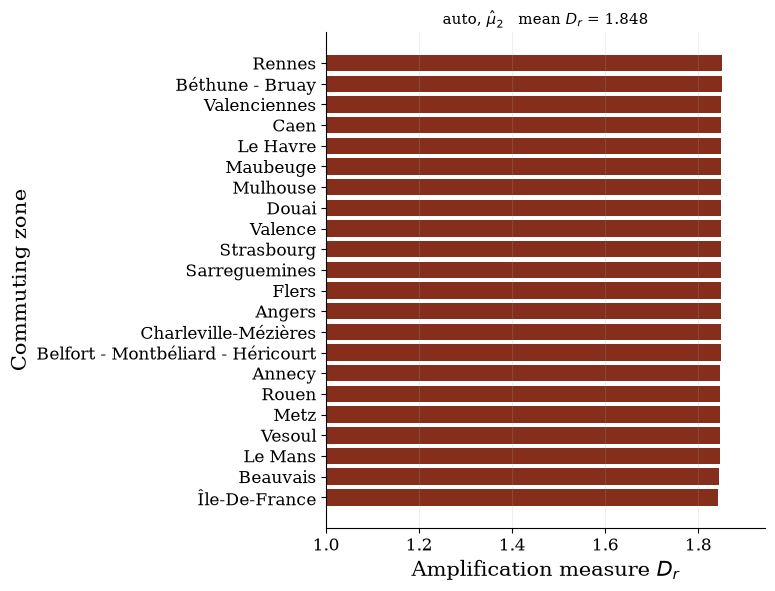

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  variety count in suppliers.parquet:
        N_hat  varieties_in_parquet  ratio  n_replications
sector                                                    
C22B     10.0                  10.0    1.0              50
C25D     14.0                  14.0    1.0              50
C26E      9.0                   9.0    1.0              50
C27B     15.0                  15.0    1.0              50
C28A      9.0                   9.0    1.0              50
C30C     16.0                  16.0    1.0              50
C33Z      5.0                   5.0    1.0              50
G46Z      8.0                  

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,region,upstream_sales,amplification,supplier_cells,mean_upstream_distance,share_within_100km,share_within_200km
ze2010_downstream,,,,,,,
156,Brest,0.888,1.888,257,590.146,0.015,0.031
267,Cannes - Antibes,0.884,1.884,252,488.485,0.006,0.040
36,Le Havre,0.880,1.880,259,453.792,0.017,0.176
272,Marseille - Aubagne,0.878,1.878,250,395.518,0.040,0.081
193,Bayonne,0.876,1.876,251,381.133,0.057,0.223
273,Istres - Martigues,0.876,1.876,250,366.930,0.046,0.094
137,Cholet,0.874,1.874,254,335.292,0.046,0.157
7,Roissy - Sud Picardie,0.873,1.873,252,375.681,0.167,0.334
220,Valence,0.872,1.872,249,310.968,0.069,0.217


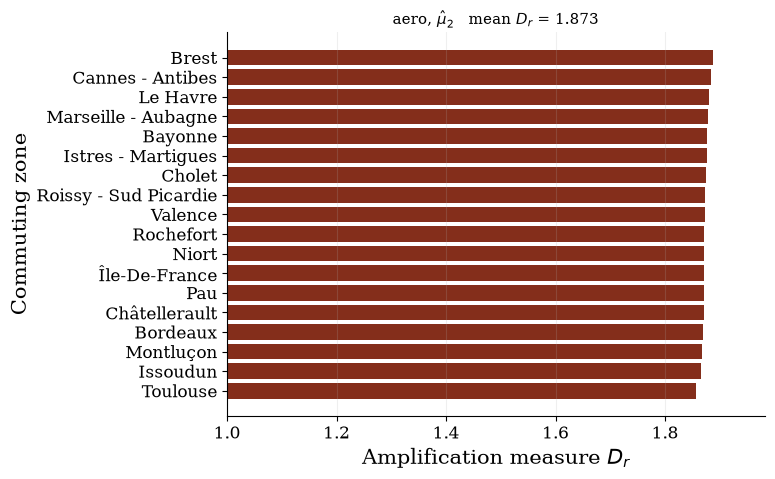

In [115]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]  variety count in suppliers.parquet:")
    supplier_count_check(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"\n  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    display(summ.round(3))

    plot_amplification(data, summary=summ,
                       save_to=f"{out_folder}/amplification_{industry}_mu{MU}.pdf")
    plt.show()


## Test 2 — is $D_r$ large? The input-output benchmark

Test 1 returns ~1.85. Whether that is a lot is not answerable from inside the model, so it is
read against the Leontief multipliers of the IO table.

**Two comparisons need no output data and come first**, because they are the ones that can be
made cleanly. The COMPOSITION of the downstream column — the $\pi_s$ object the $\Omega_s$
were calibrated on — against the model's simulated sector split; and the COVERAGE, the
modelled sectors' share of the industry's domestic intermediate purchases. Then
$(D_r - 1)/\text{coverage}$ is what the model implies for the downstream firm's TOTAL
intermediate share: a number that must sit below one and near $1 - \Omega_L$ to be credible.

**What the TES block cannot support, stated rather than papered over.** The technical
coefficients $a_{ij} = X_{ij}/x_j$ need GROSS OUTPUT, and the intermediate-flow block has no
value-added row, so each column must be normalised to an intermediate share supplied from
outside. Under a COMMON $m$ every column of $A$ sums to $m$, hence $\sum_i (A^k)_{ij} = m^k$
and the Leontief total is exactly $1/(1-m)$ for every sector — the cascade then measures the
assumption, not the network. The scalar path runs and says so loudly; pass a per-sector
`intermediate_share` for the informative answer.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.848  -> the modelled domestic sectors are 0.848 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.336
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 16% of the aggregate, 100% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.848,0.156,1.004
subset,10,1.845,2.559,6.447,1.848,0.156,1.004


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2475
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1385
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1266
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1117
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1063
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0688
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0686
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0672
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


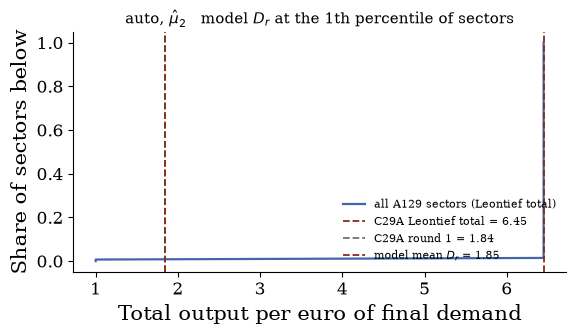

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.873  -> the modelled domestic sectors are 0.873 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.208
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 103% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.873,0.153,1.026
subset,10,1.851,2.575,6.715,1.873,0.153,1.026


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.5639
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1366
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0811
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0869
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0357
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0230
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0247
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0202


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


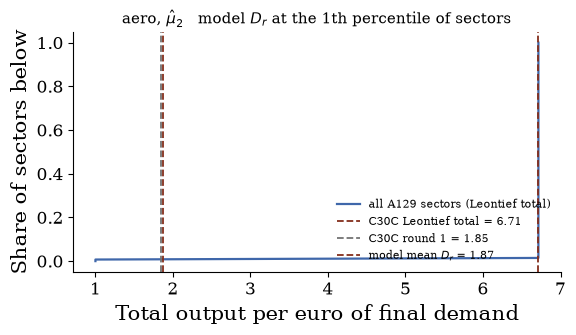

In [116]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    # Guarded: without TES_dom.csv / TES_imp.csv beside the run this prints a note
    # instead of breaking the test.
    try:
        summ = amplification_summary(data, radii=AMPLIFICATION_RADII)
        bench = io_amplification_benchmark(data, summary=summ)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")


## Test 3 — how far does the response travel?

Amplification says how large the response is, not where it lands. The first incidence
statistic is the distance the euro covers:

$$d_r = \frac{\sum_{r'} X_{r'r}\, d_{r'r}}{\sum_{r'} X_{r'r}}.$$

One number in kilometres, aggregating the whole geography of the response rather than one
radius, and the object the alignment identity of §4 governs directly.

**Two things this test does NOT settle, and says so.** The LEVEL identifies nothing on its
own: ~350 km in both industries, which is neither which force is holding the euro there nor
whether the two industries hold it there for the same reason. That is test 4. And the
cross-buyer DISPERSION of $d_r$ is partly the shape of the country — a buyer in Brest faces a
larger $d_r$ than one in Bourges under *any* allocation — which is what
`distance_normalisation` removes by dividing through the uniform-allocation distance,
anchoring the statistic at one.

Both the CDF and the histogram are drawn. The CDF is the better object for a SHIFT (the
horizontal gap between two curves is the effect at every quantile, and it uses every point
exactly); the histogram is the better object for a SHAPE. With only ~20 shocked regions the
histogram is sensitive to `bins` in a way the CDF is not — vary `bins` before believing a mode.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  d_r: mean 347.2 km, median 358.7, min 257.3, max 407.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.798  0.783  0.684  1.079
Both forces                 0.799  0.781  0.689  1.084
Distance only               0.942  0.942  0.925  0.952
Comparative advantage only  0.852  0.836  0.760  1.141


region  \
ze2010_downstream regime                                             
12                Realised                           Île-De-France   
                  Both forces                        Île-De-France   
                  Distance only                      Île-De-France   
                  Comparative advantage only         Île-De-France   
13                Realised                    Charleville-Mézières   
...                                                            ...   
220               Comparative advantage only               Valence   
230               Realised                                  Annecy   
                  Both forces                               Annecy   
                  Distance only                             Annecy   
                  Comparative advantage only                Annecy   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
12                Realised                                   257.279   
                  Both forces                                258.999   
                  Distance only                              352.579   
                  Comparative advantage only                 285.713   
13                Realised                                   338.231   
...                                                              ...   
220               Comparative advantage only                 380.935   
230               Realised                                   338.291   
                  Both forces                                337.793   
                  Distance only                              328.173   
                  Comparative advantage only                 359.319   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
12                Realised                             376.070           0.684  
                  Both forces                          376.070           0.689  
                  Distance only                        376.070           0.938  
                  Comparative advantage only           376.070           0.760  
13                Realised                             462.952           0.731  
...                                                        ...             ...  
220               Comparative advantage only           333.956           1.141  
230               Realised                             352.768           0.959  
                  Both forces                          352.768           0.958  
                  Distance only                        352.768           0.930  
                  Comparative advantage only           352.768           1.019  

[88 rows x 4 columns]

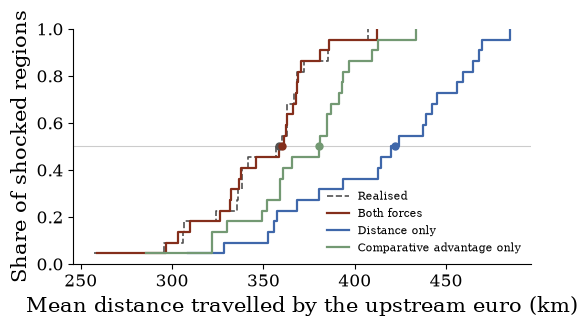

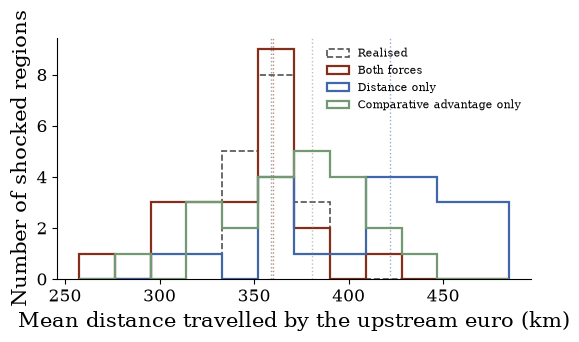

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  d_r: mean 353.3 km, median 333.3, min 252.9, max 590.1


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  d_r normalised by the uniform-allocation distance (1 = as far as an unselective allocation would send it):
                             mean    50%    min    max
regime                                                
Realised                    0.878  0.908  0.640  0.981
Both forces                 0.881  0.908  0.639  0.981
Distance only               0.882  0.888  0.826  0.944
Comparative advantage only  0.967  0.973  0.797  1.124


region  \
ze2010_downstream regime                                              
7                 Realised                    Roissy - Sud Picardie   
                  Both forces                 Roissy - Sud Picardie   
                  Distance only               Roissy - Sud Picardie   
                  Comparative advantage only  Roissy - Sud Picardie   
11                Realised                                 Toulouse   
...                                                             ...   
272               Comparative advantage only    Marseille - Aubagne   
273               Realised                       Istres - Martigues   
                  Both forces                    Istres - Martigues   
                  Distance only                  Istres - Martigues   
                  Comparative advantage only     Istres - Martigues   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
7                 Realised                                   375.681   
                  Both forces                                376.802   
                  Distance only                              332.152   
                  Comparative advantage only                 434.096   
11                Realised                                   252.917   
...                                                              ...   
272               Comparative advantage only                 434.234   
273               Realised                                   366.930   
                  Both forces                                368.562   
                  Distance only                              378.553   
                  Comparative advantage only                 405.575   

                                              uniform_distance  distance_ratio  
ze2010_downstream regime                                                        
7                 Realised                             386.066           0.973  
                  Both forces                          386.066           0.976  
                  Distance only                        386.066           0.860  
                  Comparative advantage only           386.066           1.124  
11                Realised                             395.398           0.640  
...                                                        ...             ...  
272               Comparative advantage only           450.783           0.963  
273               Realised                             427.406           0.859  
                  Both forces                          427.406           0.862  
                  Distance only                        427.406           0.886  
                  Comparative advantage only           427.406           0.949  

[72 rows x 4 columns]

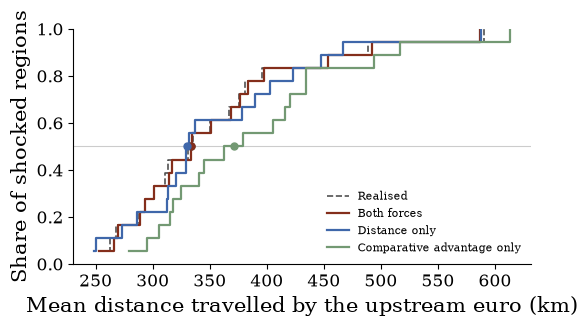

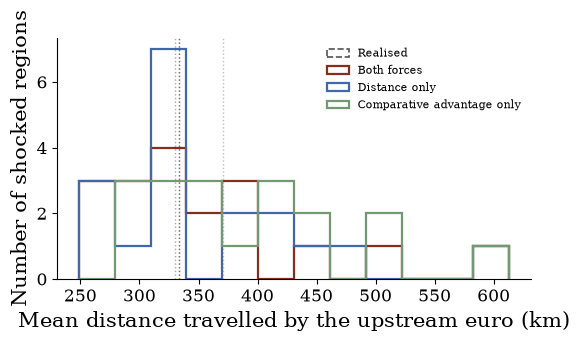

In [117]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    print(f"[{industry}, mu = {MU}]  d_r: mean {summ['mean_upstream_distance'].mean():.1f} km, "
          f"median {summ['mean_upstream_distance'].median():.1f}, "
          f"min {summ['mean_upstream_distance'].min():.1f}, "
          f"max {summ['mean_upstream_distance'].max():.1f}")

    # d_r purged of the country's shape: 1 = as far as an unselective allocation sends it
    display(distance_normalisation(data, diffusion=diff).round(3))

    plot_distance_distribution(data, diffusion=diff,
                               save_to=f"{out_folder}/counterfactual_distance_{industry}_mu{MU}.pdf")
    plt.show()
    plot_distance_histogram(data, diffusion=diff,
                            save_to=f"{out_folder}/counterfactual_distance_hist_{industry}_mu{MU}.pdf")
    plt.show()


## Test 3 bis — how uniform is the force that sets that distance?

Test 3 reports where $d_r$ ends up. This one reports the *rate* that puts it there, which is
the object the next test integrates. By the alignment identity, dialling comparative
advantage down moves a buyer's average sourcing distance at

$$\frac{\partial \bar d_{rs}}{\partial t} = \operatorname{Cov}_{\rho_{\cdot rs}}\!\big(\log \hat T_{a(l)s},\, d_{lr}\big),$$

taken across the cells competing for that buyer and weighted by the sourcing probabilities.
It is in KILOMETRES per log point, so unlike the correlation of the section above it can be
read against the counterfactual directly: a buyer's whole displacement under *Distance only*
is the path integral of its own covariance.

**Why this figure and not the correlation, and why both are kept.** The correlation is
scale-free, which is what makes it the right object in §4 — $\hat T$ is identified only up to
a per-sector scale, so a comparison of two industries has to be. But a scale-free statistic
carries no distance, and §5.1 quotes kilometres. Reporting the covariance here is what lets
the counterfactual paragraph and the figure it cites be the same statistic.

**What the figure answers that a median cannot.** A sector median of $-54$ km is consistent
with every buyer facing the same mild alignment *and* with half facing a strong one and half
the opposite — different economies, different counterfactuals. The mass on either side of
zero is the answer: where it is one-sided, equalising $\hat T$ moves every buyer the same way
and the aggregate is the buyer; where it straddles zero, the aggregate is a cancellation and
the buyer-level picture of test 4 is the one to read.

The histogram and a Gaussian kernel density are drawn together. The density is the cleaner
object for a paper, but it is an estimate with a bandwidth: at a couple of hundred pairs it
can put a shoulder where the data have three points, and it leaks a little mass past the
extreme observations. The outline underneath is the raw count to check it against — vary `bw`
as `bins` is varied on the histogram of test 3. `level="buyer"` spend-aggregates across
sectors, which is the level at which "negative for every buyer" is a claim rather than a
statement about (sector, buyer) pairs.


In [118]:
# Test 3 bis — the alignment in KILOMETRES: the rate the counterfactual integrates.
#
# Reads `alignment_frame` from Test 6 of the comparative-advantage section above,
# and `_parquet_sector_index` from the amplification definitions, so run those first
# if this section is run on its own.
from scipy.stats import gaussian_kde


def alignment_covariance(data, weights="rho", frame=None):
    """
    The alignment in KILOMETRES, one row per (sector, buyer) — the object Section 5.1
    reads, as opposed to the dimensionless correlation `alignment_correlation` returns.

    `cov_T_d_km` is `Cov_rho(log T_a(l)s, d_lr)`, the rate at which dialling comparative
    advantage down moves that buyer's average sourcing distance in that sector
    (eq:alignment). `cov_d_d_km` is `Cov_rho(log d_lr, d_lr)`, the rate for trade costs
    (eq:distance_rate); it is a covariance between two increasing functions of the same
    variable, so it is POSITIVE by construction and the column exists to be checked, not
    to be read for its sign.

    Three conventions are inherited rather than chosen, and each of the three is a place
    the figure and the text can silently come apart. The moments are taken under the
    SOURCING probabilities `rho` by default, because that is the measure the identity
    holds under — `weights="cell"` reproduces the variance decomposition's convention
    instead and answers a different question. Distance enters in KILOMETRES on the second
    argument, because the statistic differentiates `d_rs = sum_l rho_lrs d_lr`; the log
    is on `T` alone. And the row is one (sector, buyer) pair, so a buyer-level statement
    needs `by_buyer=True` on the aggregate below, not a read of this frame's median.

    Built off `alignment_frame`, so the figure and the regression cannot drift apart.
    """
    fr = alignment_frame(data, geom=None) if frame is None else frame
    if weights not in ("rho", "cell"):
        raise ValueError(f"weights must be 'rho' or 'cell', not {weights!r}")
    rows = []
    # grouped on `group`, not on (sector, buyer): `group` is built from the downstream
    # INDEX, so two buyers sharing a display name cannot be merged into one row.
    for _, sub in fr.groupby("group", sort=False):
        sec, buyer = sub["sector"].iloc[0], sub["buyer"].iloc[0]
        x = sub["log_T"].to_numpy(float)
        d = sub["distance_km"].to_numpy(float)
        p = (sub["rho"].to_numpy(float) if weights == "rho"
             else np.full(len(sub), 1.0 / len(sub)))
        tot = p.sum()
        if not np.isfinite(tot) or tot <= 0 or len(sub) < 2:
            continue
        p = p / tot
        ld = np.log(np.maximum(d, 1.0))
        mx, md, ml = float(p @ x), float(p @ d), float(p @ ld)
        rows.append({
            "sector": sec,
            "buyer": buyer,
            "cov_T_d_km": float(p @ ((x - mx) * (d - md))),
            "cov_d_d_km": float(p @ ((ld - ml) * (d - md))),
            "d_rs_km": md,
            "buyer_weight": float(sub["weight"].sum()),
            "n_cells": int(len(sub)),
        })
    out = pd.DataFrame(rows)
    out.attrs["weights"] = weights
    out.attrs["industry"] = data["industry"]
    return out


def alignment_covariance_by_buyer(data, cov=None, weights="rho"):
    """
    The same covariance aggregated to the BUYER, which is the level Section 5.1 quotes.

    `d_r = sum_s (X_rs/X_r) d_rs`, so the buyer-level rate is the spend-weighted average
    of its sectors' rates — the same buyer-first aggregation `counterfactual_diffusion_frame`
    performs on the euros, and the reason a sector median and a buyer median need not
    agree (one sector can carry most of a buyer's spending).

    Spending comes from the realised economy (`suppliers.parquet`); absent it, the
    function raises rather than falling back on equal sector weights, which would report
    a different statistic under the same name.
    """
    cov = alignment_covariance(data, weights=weights) if cov is None else cov
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the buyer-level aggregation needs the realised sector-level spending.")
    geom = sourcing_geometry(data)
    # The buyer label is rebuilt with `aa_display_names`, the SAME route `alignment_frame`
    # takes, so the join cannot silently miss: `alignment_correlation` names buyers through
    # `_region_labels` instead, and the two need not agree on every zone. The parquet's
    # `ze2010_downstream` carries the model's own region index, which is what
    # `geom["downstream"]` holds, so the key is exact rather than a name match.
    aa_names = aa_display_names(data)
    ze_of_name = {(aa_names[r] if r < len(aa_names) else str(r)): int(z)
                  for r, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])["share"].sum())
    sec_of = {name: s for s, name in enumerate(data["sector_names"])}
    w = []
    for _, row in cov.iterrows():
        s, z = sec_of.get(row["sector"]), ze_of_name.get(row["buyer"])
        w.append(0.0 if s is None or z is None else float(spend.get((z, s), 0.0)))
    cov = cov.assign(spend=w)
    if float(np.sum(w)) <= 0:
        raise ValueError(
            "every (sector, buyer) matched zero spending — the parquet's sector index or "
            "its `ze2010_downstream` does not line up with `sourcing_geometry`.")
    # `sup` pools `n_rep` realisations, so `spend` is `n_rep` times the per-economy figure;
    # unlike `counterfactual_diffusion_frame`, which allocates those euros and must divide,
    # this uses them only as WEIGHTS, and a common factor cancels out of a weighted mean.
    #
    # Summed rather than run through `groupby.apply`: apply over the grouping column warns
    # on pandas 2.x, and its `np.average` would have propagated a NaN covariance into the
    # numerator while `sum` silently kept that pair's spending in the denominator. Dropping
    # the unusable rows first is what makes the weights and the values the same set.
    ok = cov.dropna(subset=["cov_T_d_km", "cov_d_d_km"])
    acc = (ok.assign(_a=ok["cov_T_d_km"] * ok["spend"], _b=ok["cov_d_d_km"] * ok["spend"])
             .groupby("buyer", sort=False)[["_a", "_b", "spend"]].sum())
    den = acc["spend"].where(acc["spend"] > 0)
    out = pd.DataFrame({"cov_T_d_km": acc["_a"] / den,
                        "cov_d_d_km": acc["_b"] / den,
                        "spend": acc["spend"]})
    out.attrs["industry"] = data["industry"]
    return out



def plot_alignment_covariance(datasets, weights="rho", bins=24, frames=None, colors=None,
                              figsize=None, save_to=None, annotate=True, level="pair",
                              kde=True, bw=None, grid=512):
    """
    The distribution of the alignment in KILOMETRES: one histogram outline and one
    kernel density per industry, on one panel.

    This is `plot_alignment_correlation`'s companion, not its replacement, and the two
    answer different questions. The correlation is scale-free, so it RANKS geometries
    and is the right object for Section 4, where the comparison is between two
    industries whose `log T` is identified only up to a per-sector scale. The covariance
    carries kilometres, so it is the only one of the two a paragraph quoting a distance
    may cite: by the alignment identity it IS the rate at which dialling comparative
    advantage down moves that buyer's average sourcing distance, and its path integral
    is the `Distance only` counterfactual.

    Three conventions, each a place the figure and the text can silently come apart. The
    moments are taken under the SOURCING probabilities, because that is the measure the
    identity holds under; `weights="cell"` reproduces the variance decomposition's
    convention and answers a different question. Distance enters in kilometres on the
    second argument and the log is on `T` alone, because the statistic differentiates
    `d_rs = sum_l rho_lrs d_lr`. And a row is one (sector, buyer) pair unless
    `level="buyer"`, which spend-aggregates across sectors -- the level at which a
    sentence of the form "negative for every buyer" is a claim.

    Both the histogram and the density are drawn, deliberately. A Gaussian kernel is
    smooth and reads well in a paper, but it is an ESTIMATE with a bandwidth, and at a
    couple of hundred pairs it can put a shoulder where the data have three points; the
    outline underneath is the raw count the reader checks it against. `bw` overrides
    Scott's rule -- vary it before believing a mode, exactly as `bins` is varied on
    `plot_distance_histogram`. The kernel is drawn on the pooled support and is NOT
    truncated at the data range, so a little mass leaks past the extreme observations:
    that is the estimator, not a finding.

    Bin edges and the density grid are computed ONCE on the pooled values, so the two
    industries sit on one axis and the comparison is a comparison.
    """
    if level not in ("pair", "buyer"):
        raise ValueError(f"level must be 'pair' or 'buyer', not {level!r}")

    def _build(d):
        cov = alignment_covariance(d, weights=weights)
        return cov if level == "pair" else alignment_covariance_by_buyer(d, cov=cov)

    frs = frames if frames is not None else {n: _build(d) for n, d in datasets}
    vals = {n: f["cov_T_d_km"].dropna().to_numpy(float) for n, f in frs.items()}
    pooled = np.concatenate(list(vals.values()))
    if pooled.size == 0:
        raise ValueError(f"no {level} with a finite Cov(log T, d).")
    edges = np.histogram_bin_edges(pooled, bins=bins)
    pad = 0.15 * (pooled.max() - pooled.min() or 1.0)
    xs = np.linspace(pooled.min() - pad, pooled.max() + pad, int(grid))

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    palette = colors or {}
    default = [sim_color, toulouse_color, reference_color]
    for k, (name, v) in enumerate(vals.items()):
        col = palette.get(name, default[k % len(default)])
        ax.hist(v, bins=edges, density=True, histtype="step", linewidth=1.0,
                color=col, alpha=0.55)
        lab = f"{name} (median {np.median(v):+.0f} km)"
        if kde and v.size > 1 and np.ptp(v) > 0:
            dens = gaussian_kde(v, bw_method=bw)(xs)
            ax.plot(xs, dens, color=col, linewidth=1.8, label=lab)
            ax.fill_between(xs, dens, color=col, alpha=0.10)
        else:
            ax.plot([], [], color=col, linewidth=1.8, label=lab)
        ax.axvline(np.median(v), color=col, linestyle=":", linewidth=1.0)
    ax.axvline(0.0, color="0.35", linewidth=0.9)
    unit = "buyer" if level == "buyer" else "(sector, buyer)"
    ax.set_xlabel(r"$\mathrm{Cov}_{\rho}(\log \hat T_{a(l)s},\ d_{lr})$ "
                  f"(km per log point) at one {unit}")
    ax.set_ylabel("Density")
    ax.set_ylim(bottom=0.0)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    if annotate:
        txt = "\n".join(f"{n}: {float((v > 0).mean()):.0%} positive" for n, v in vals.items())
        ax.text(0.98, 0.97, txt, transform=ax.transAxes, fontsize=8, va="top",
                ha="right", color="0.25")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax, frs


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


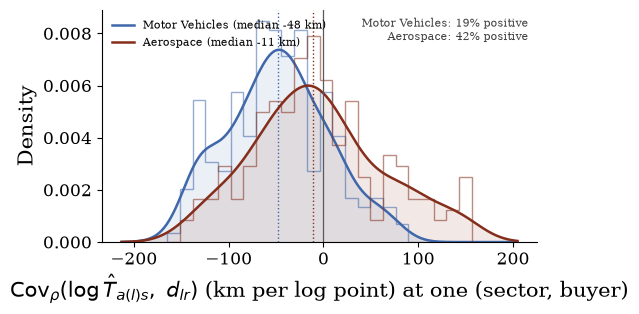

Motor Vehicles: 220 (sector, buyer) pairs, median -48.2 km/log pt, purchase-weighted mean -60.2, 18.6% positive, p10 -125.5, p90 +17.5
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +101.3 km/log pt
Aerospace: 180 (sector, buyer) pairs, median -11.1 km/log pt, purchase-weighted mean -15.2, 41.7% positive, p10 -91.5, p90 +95.8
    Cov(log d, d) > 0 for 100.0% of pairs (must be 100%), median +86.2 km/log pt


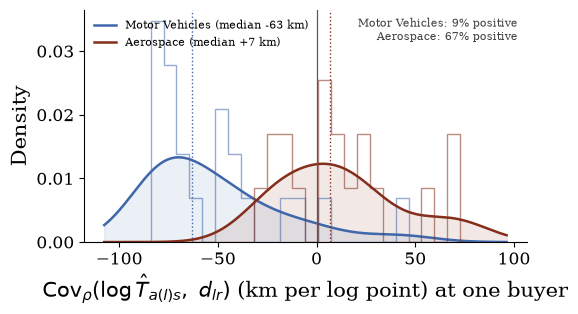

Motor Vehicles: 22 buyers, median -63.1 km/log pt, 9.1% positive, range [-84.1, +41.7]
Aerospace: 18 buyers, median +6.9 km/log pt, 66.7% positive, range [-27.2, +72.7]


In [119]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
cov_data = []
for cfg in INDUSTRIES:
    data = load_granular_data(cfg["industry"], mu=MU, **RUN_KWARGS)
    cov_data.append(data)

_cov_ax, _cov_frames = plot_alignment_covariance(
    [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
    save_to=f"{out_folder}/alignment_covariance_mu{MU}.pdf")
plt.show()

for _name, _fr in _cov_frames.items():
    _w, _c = _fr["buyer_weight"], _fr["cov_T_d_km"]
    print(f"{_name}: {len(_fr)} (sector, buyer) pairs, median {_c.median():+.1f} km/log pt, "
          f"purchase-weighted mean {float((_c * _w).sum() / _w.sum()):+.1f}, "
          f"{float((_c > 0).mean()):.1%} positive, "
          f"p10 {_c.quantile(0.10):+.1f}, p90 {_c.quantile(0.90):+.1f}")
    # the trade-cost rate: Cov(log d, d) is a covariance between two increasing functions
    # of the same variable, so this line gates the arithmetic rather than reporting a result
    print(f"    Cov(log d, d) > 0 for {float((_fr['cov_d_d_km'] > 0).mean()):.1%} of pairs "
          f"(must be 100%), median {_fr['cov_d_d_km'].median():+.1f} km/log pt")

# --- and the same covariance at the BUYER level, which is what 5.1 asserts ----
# One sector can carry most of a buyer's spending, so the pair median and the buyer
# median need not agree; this is the spend-weighted aggregation, the one the euros get.
try:
    plot_alignment_covariance(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, cov_data)],
        level="buyer",
        save_to=f"{out_folder}/alignment_covariance_buyer_mu{MU}.pdf")
    plt.show()
    for cfg, d in zip(INDUSTRIES, cov_data):
        v = alignment_covariance_by_buyer(d)["cov_T_d_km"].dropna()
        print(f"{cfg['display_name']}: {len(v)} buyers, median {v.median():+.1f} km/log pt, "
              f"{float((v > 0).mean()):.1%} positive, "
              f"range [{v.min():+.1f}, {v.max():+.1f}]")
except (FileNotFoundError, NameError) as e:
    print(f"  buyer-level aggregation skipped: {e}")


## Test 4 — which force keeps the euro close?

The sourcing probabilities are closed form, so the same shock can be propagated with either
allocative force switched off. What is held FIXED is what the model makes a cost-share object
— how much of the euro leaves for upstream, and how it splits across SECTORS, neither of which
involves $T$ or $\alpha$. What moves is where inside a sector the euro lands.

**Two consequences, both load-bearing.** Since $\sum_l \rho_{lrs} = 1$ for every (sector,
buyer), $D_r$ is IDENTICAL under every regime: cancelling a channel moves a shock in space
without changing its size. That is why every counterfactual figure is about incidence and none
re-draws $D_r$, and it is gated to machine precision. And `Both forces` is the closed-form
EXPECTATION of the allocation while the parquet is one realised finite-variety draw of it, so
the two differ by granularity — the gap is printed, and the closed-form row, not the realised
one, is the baseline the other regimes are read against.

**The two regimes are not symmetric interventions.** Equalising $\hat T$ removes a
*supplier*-specific term; setting $\alpha = 0$ removes the *only buyer-specific* term in
$\rho_{lrs} \propto T_{a(l)s} d_{lr}^{-\theta\alpha}$. Any statistic measuring how much of its
own position a buyer's sourcing inherits must therefore go to zero under $\alpha = 0$ by
construction — that regime is an internal control on such a statistic, not an economic
counterfactual to be compared with the other.

By the alignment identity the movement of $d_r$ IS the co-location covariance evaluated at
that buyer, so the SHAPE of the shift is informative in a way its mean is not: a block shift
means the covariance is common across buyers, crossing curves mean the sign is not.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy

[auto, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.848                 347.294               0.074                        0.074               0.238                        0.237
Both forces                         1.848                 347.593               0.073                        0.073               0.2

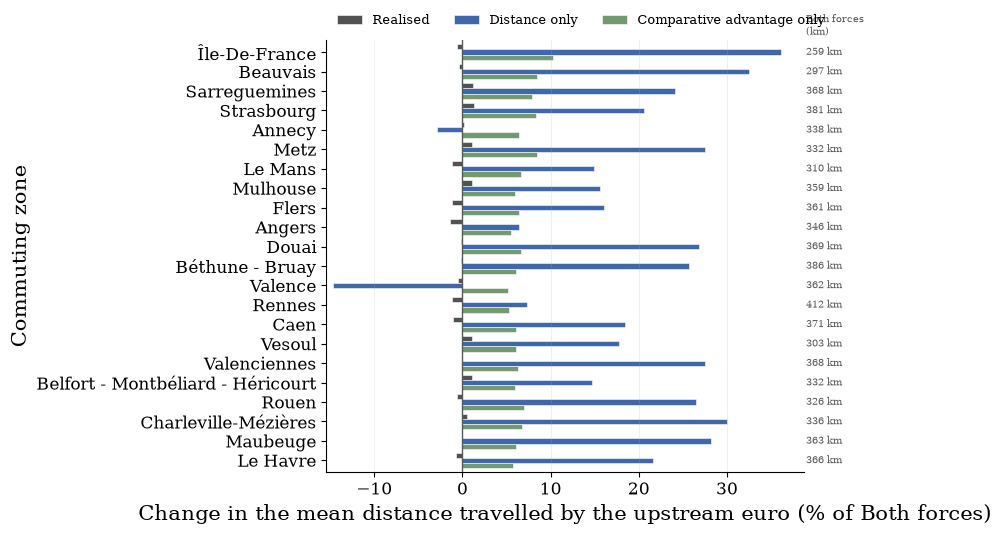

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy

[aero, mu = 2]  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.873                 353.850               0.088                        0.088               0.213                        0.212
Both forces                         1.873                 355.162               0.089                        0.088               0.2

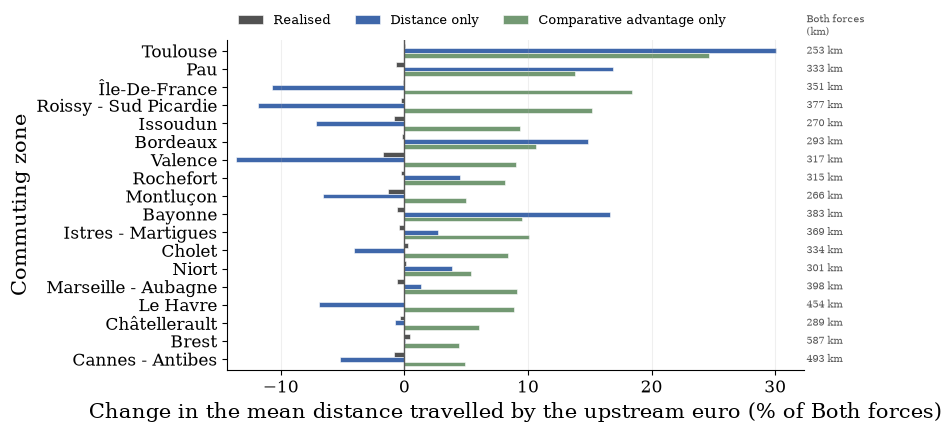

In [120]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)
    det    = counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                          frames=frames, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]  the shock with one force switched off "
          "(D_r is the same in every regime by construction):")
    print(counterfactual_summary(data, radii=AMPLIFICATION_RADII, detail=det).round(3).to_string())

    # is the shift a block translation or a rotation? the quantile-by-quantile answer
    print("\n  the distribution of d_r behind that mean, and how each force shifts it:")
    print(distance_distribution_report(data, detail=det).to_string())

    # ... and the same thing differenced BUYER BY BUYER rather than quantile by quantile,
    # on the percentage scale `plot_counterfactual_distance` is drawn on. `mean_abs_pct`
    # against `mean_pct` is the size of the reallocation a near-zero average hides.
    print("\n  each buyer's d_r as a % deviation from the estimated allocation:")
    rel = relative_displacement(data, detail=det)
    print(rel.to_string())
    # every buyer, sorted: there are only ~20 of them, and the paper names individual
    # commuting zones, so the full list is what a named claim has to be checked against.
    _p = rel.attrs["per_buyer_pct"]
    for _reg in [c for c in ("Distance only", "Comparative advantage only") if c in _p.columns]:
        print(f"\n  {_reg}: each buyer's % deviation, sorted (negative = sources closer):")
        print(_p[_reg].sort_values(ascending=False).round(1).to_string())

    plot_counterfactual_distance(
        data, detail=det,
        save_to=f"{out_folder}/counterfactual_distance_region_{industry}_mu{MU}.pdf")
    plt.show()


## Test 5 — where does the response land?

Test 4 says capability sits near demand in motor vehicles. It does not say whether that
capability is one broad mass inside the demand distribution, a set of local pockets, or a
small number of hubs — three different economies, and only the third is hub-and-spoke.

**The barycentre cannot make that distinction, and this is a defect rather than a taste.**
It is the FIRST MOMENT of the destination distribution, and a dispersed central pool and a
pair of distant hubs have nearly the same first moment: both sit near the national centre of
mass, since with four fifths of the euros spread nationally the mean is pinned there however
concentrated the remaining fifth is. That is exactly why every aerospace arrow lands in the
Massif Central while the euros are collected by Toulouse and Île-de-France. The shrinkage
coefficient $\lambda$ inherits the degeneracy — below 0.12 in both industries, separating
nothing. `barycentre_shrinkage` is still run below, as a reported robustness exhibit.

The object with the answer is the incidence vector $\omega_r = (X_{lr}/\sum_l X_{lr})_l$,
characterised by two numbers. CONCENTRATION is the effective number of destinations
$1/H_r$, reported RELATIVE to the uniform allocation because its level is mostly the sector's
cell count and the shape of the country. COMMONALITY is the euro share that is buyer-specific,
$\Delta_r = \tfrac12\sum_l|\omega_{lr} - \bar\omega_l|$, read against ZERO rather than against
a benchmark — the allocation is already nearly buyer-independent, so an overlap statistic in
levels sits at its ceiling in both industries.

The prediction is stated before the numbers: aerospace should be concentrated AND common
(bottom-left of the plane), motor vehicles spread and common.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(



[auto, mu = 2]
  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                              n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                     
Realised                    105.847        0.468  0.009  0.074      0.007      0.048       0.995         0.987        0.067
Both forces                 106.660        0.472  0.009  0.073      0.006      0.044       0.996         0.989        0.060
Distance only               227.252        1.004  0.004  0.024      0.005      0.037       0.994         0.986        0.056
Comparative advantage only  114.250        0.505  0.009  0.066      0.003      0.003       1.000         1.000        0.005
Uniform benchmark           226.188        1.000  0.00

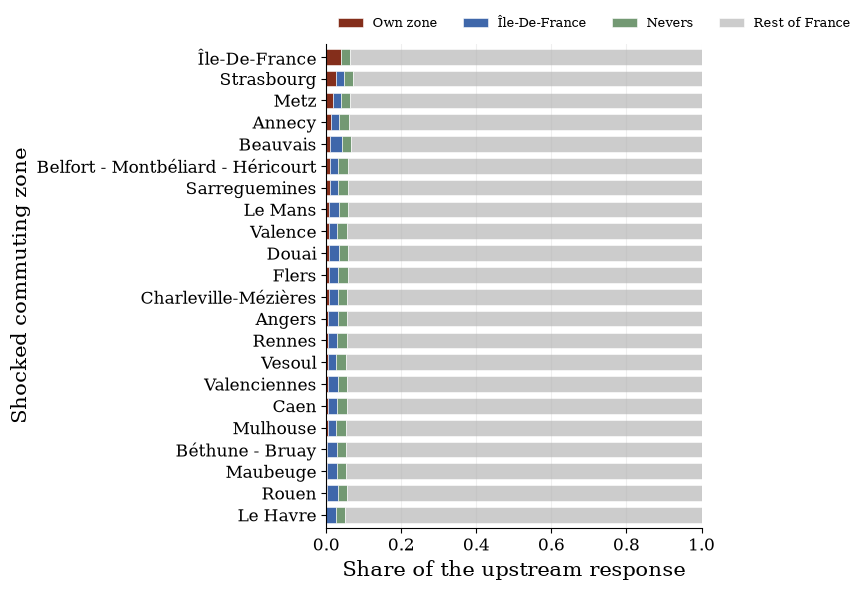

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[aero, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the incidence vector: how concentrated, and how much is buyer-specific
  (n_eff_ratio < 1 = the forces concentrate; tv_common is the euro share that is buyer-specific, read against 0)
                             n_eff  n_eff_ratio    hhi   top3  own_share  tv_common  cos_common  pairwise_cos  pairwise_tv
regime                                                                                                                    
Realised                    28.938        0.302  0.035  0.234      0.012      0.082       0.991         0.975        0.124
Both forces                 31.337        0.326  0.032  0.204      0.011      0.074       0.991         0.973        0.116
Distance only               86.661        0.895  0.012  0.085      0.009      0.103       0.955         0.875        0.157
Comparative advantage only  31.294        0.319  0.032  0.200      0.003      0.020       1.000         0.999        0.036
Uniform benchmark           98.026        1.000  0.010  0.048      0.002    

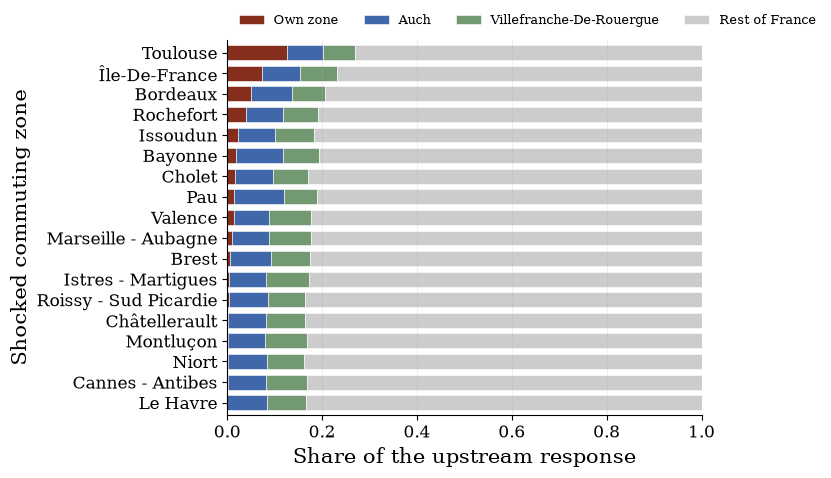

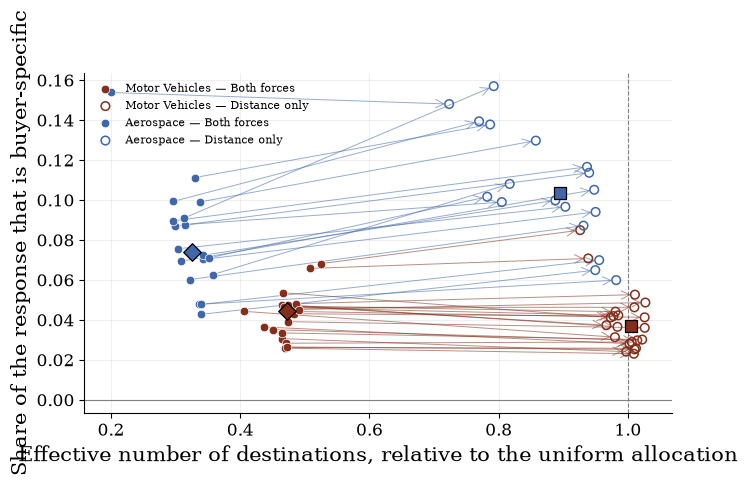

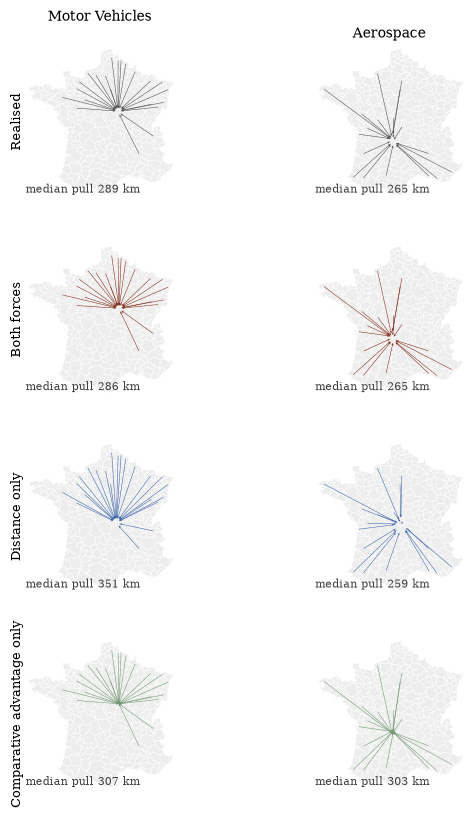

                                           slope     se       t  ci_lo  ci_hi  slope_x  slope_y     r2  dispersion_ratio  median_pull_km  median_distance_km     n
industry       regime                                                                                                                                             
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098    0.060    0.097  0.846             0.087         264.600             335.014  18.0
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   -0.002   -0.040  0.374             0.037         302.729             372.621  18.0
               Distance only               0.121  0.014   8.849  0.094  0.148    0.113    0.128  0.871             0.130         259.301             334.260  18.0
               Realised                    0.082  0.009   8.799  0.064  0.101    0.064    0.097  0.852             0.089         264.645             334.360  18.0
Motor Vehicles Both fo

slope     se       t  ci_lo  ci_hi  \
industry       regime                                                           
Aerospace      Both forces                 0.080  0.009   8.904  0.062  0.098   
               Comparative advantage only -0.023  0.007  -3.274 -0.036 -0.009   
               Distance only               0.121  0.014   8.849  0.094  0.148   
               Realised                    0.082  0.009   8.799  0.064  0.101   
Motor Vehicles Both forces                 0.065  0.002  34.472  0.062  0.069   
               Comparative advantage only -0.003  0.000 -11.668 -0.003 -0.002   
               Distance only               0.069  0.004  19.571  0.062  0.076   
               Realised                    0.068  0.002  33.809  0.064  0.072   

                                           slope_x  slope_y     r2  \
industry       regime                                                
Aerospace      Both forces                   0.060    0.097  0.846   
               Comparative advantage only   -0.002   -0.040  0.374   
               Distance only                 0.113    0.128  0.871   
               Realised                      0.064    0.097  0.852   
Motor Vehicles Both forces                   0.067    0.062  0.961   
               Comparative advantage only   -0.003   -0.002  0.830   
               Distance only                 0.067    0.073  0.955   
               Realised                      0.068    0.068  0.964   

                                           dispersion_ratio  median_pull_km  \
industry       regime                                                         
Aerospace      Both forces                            0.087         264.600   
               Comparative advantage only             0.037         302.729   
               Distance only                          0.130         259.301   
               Realised                               0.089         264.645   
Motor Vehicles Both forces                            0.067         286.461   
               Comparative advantage only             0.003         307.104   
               Distance only                          0.070         351.112   
               Realised                               0.069         288.858   

                                           median_distance_km     n  
industry       regime                                                
Aerospace      Both forces                            335.014  18.0  
               Comparative advantage only             372.621  18.0  
               Distance only                          334.260  18.0  
               Realised                               334.360  18.0  
Motor Vehicles Both forces                            353.820  22.0  
               Comparative advantage only             375.454  22.0  
               Distance only                          419.197  22.0  
               Realised                               355.277  22.0

,a,b,diff,se,t,ci_lo,ci_hi
0,Aerospace / Comparative advantage only,Aerospace / Both forces,-0.103,0.011,-9.053,-0.125,-0.080
1,Aerospace / Distance only,Aerospace / Both forces,0.041,0.016,2.512,0.009,0.073
2,Aerospace / Realised,Aerospace / Both forces,0.002,0.013,0.172,-0.023,0.028
3,Motor Vehicles / Comparative advantage only,Motor Vehicles / Both forces,-0.068,0.002,-35.622,-0.072,-0.064
4,Motor Vehicles / Distance only,Motor Vehicles / Both forces,0.003,0.004,0.796,-0.005,0.011
5,Motor Vehicles / Realised,Motor Vehicles / Both forces,0.002,0.003,0.863,-0.003,0.008
6,Motor Vehicles / Both forces,Aerospace / Both forces,-0.015,0.009,-1.588,-0.033,0.003



Motor Vehicles — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Cosne - Clamecy,3,19,16.111,0.864



Aerospace — where the arrows point (realised economy):


,hub_index,n_regions,sales,share_of_regions
hub,,,,
Ussel,210,5,4.378,0.278
Tulle,209,3,2.604,0.167
Guéret,211,2,1.744,0.111


In [121]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
incidence_tables, panel_data = [], []
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    panel_data.append(data)
    globals().update(data)

    diff   = build_diffusion_frame(data)
    frames = counterfactual_frames(data, diffusion=diff)

    print(f"\n[{industry}, mu = {MU}]")
    inc = incidence_concentration_overlap(data, frames=frames, diffusion=diff)
    incidence_tables.append((cfg["display_name"], inc))
    incidence_summary(inc)

    # the figure that replaces the barycentre arrows: own zone, the industry's hubs, rest
    plot_destination_composition(
        data, diffusion=diff,
        save_to=f"{out_folder}/destination_composition_{industry}_mu{MU}.pdf")
    plt.show()

# the 2x2 plane, both industries on one window
plot_incidence_plane(incidence_tables, save_to=f"{out_folder}/incidence_plane_mu{MU}.pdf")
plt.show()

# The barycentre, kept as a reported robustness exhibit rather than as the answer.
# Guarded: without france.gpkg (or geopandas) there is no geometry to place one in.
try:
    fig, barys = barycentre_panel(
        [(cfg["display_name"], d) for cfg, d in zip(INDUSTRIES, panel_data)],
        save_to=f"{out_folder}/sourcing_barycentre_panel_mu{MU}.pdf")
    plt.show()
    shrink = barycentre_shrinkage_report(barys)
    display(shrink.round(3))
    display(barycentre_shrinkage_contrast(shrink).round(3))
    for cfg, d in zip(INDUSTRIES, panel_data):
        print(f"\n{cfg['display_name']} — where the arrows point (realised economy):")
        display(barycentre_hubs(d).round(3))
except (FileNotFoundError, KeyError, ValueError) as e:
    print(f"  barycentre panel skipped: {type(e).__name__}: {e}")


## Test 5 bis — how few places, and are they the same places for every buyer?

The sourcing distance says how far a shock travels, not where it lands: a buyer sourcing
at 350 km may be drawing on a ring of neighbours or on a single distant hub, and the two
economies behave differently when the industry is shocked as a whole. Two further
questions settle it. **How many places does one buyer's shock reach?** And **do different
buyers' shocks reach the same places?** A hub serving every buyer aggregates the
industry's shocks; distinct pockets diversify them.

Both are answered by one statistic and one identity, taken **sector by sector** — a
buyer's shock hits every input sector, and each sector has its own supplier geography, so
pooling them lets a nearly common input mix impose a similarity that says nothing about
where inside a sector the euro goes (this is why the pooled cosine of Test 5 sits above
0.97 and separates nothing). With buyer weights $\pi_{rs}$ (the share of sector $s$'s
purchases made by buyer $r$) and $\bar\omega_s = \sum_r \pi_{rs}\,\omega_{rs}$,

$$\bar H_s \;=\; \sum_r \pi_{rs} H_{rs} \;=\; \underbrace{H(\bar\omega_s)}_{\text{common}} \;+\; \underbrace{M_s}_{\text{buyer-specific}},\qquad M_s=\sum_l \mathrm{Var}_\pi(\omega_{lrs})\ \ge 0,\qquad C_s = 1-\frac{M_s}{\bar H_s}.$$

A shock to **one** buyer lands with concentration $H_{rs}$; a shock to the **whole
industry** lands with $H(\bar\omega_s)$. So $C_s$ is the share of a buyer's concentration
that aggregating across buyers cannot diversify away. Unlike the overlap statistics of
Test 5, this decomposes exactly, so the two halves add up and can be counted in euros.

The 2×2 keeps all four cells, and the fourth is not empty — low concentration with low
commonality is **diffuse local sourcing**, every buyer spreading over its own
neighbourhood, which is where the `Distance only` regime sits.

|            | $H$ low        | $H$ high       |
|------------|----------------|----------------|
| $C$ high   | common pool    | hub-and-spoke  |
| $C$ low    | diffuse local  | local pockets  |

Three things this section does that the ones above do not.

**Spending weights, not medians.** The identity holds for a weighted mean over buyers and
for no other aggregator, so every average here is spend-weighted and the cross-buyer
distributions go to the appendix figure. And $H$ is averaged *before* it is inverted into
an effective number, since $1/H$ is convex.

**The forces enter as derivatives of $H$**, the exact analogue of the distance identity:
$\partial H_{rs}/\partial t = 2\,\mathrm{Cov}_\rho(\log T,\rho)$ and
$\partial H_{rs}/\partial(\alpha\theta) = -2\,\mathrm{Cov}_\rho(\log d,\rho)$ — same
weights, same two forces, but now covarying with the **shares** rather than with the
distance. Comparative advantage raises concentration whenever the productive cells
already hold large shares; trade costs raise it only if a buyer's large suppliers are the
nearby ones, and that sign is genuinely ambiguous. Distance is the *only* buyer-specific
term in $\rho$, so $C_s = 1$ **exactly** under $\alpha = 0$ — an internal control that is
an identity here, not the 0.003 the overlap table could offer.

**Granularity enters, and it did not enter the distance paragraph.** That is an argument
about the ORDER of the statistic, not about magnitudes: $d_r$ is linear in $\omega$ and
$E[\omega^{\text{realised}}]=\omega^{\text{expected}}$, so averaging was exact; $H$ is
quadratic, so $E[H] > H(E[\omega])$ strictly. With $N_s$ varieties each won by exactly one
cell,

$$E[H_{rs}] \;\approx\; H^{E}_{rs} + \frac{1-H^{E}_{rs}}{N_s},$$

exact when varieties carry equal expenditure shares. Two predictions follow, and the table
tests both: granularity and comparative advantage are **substitutes** as sources of
concentration (the added term is proportional to $1-H^E$, so it adds most where the
structure is diffuse), while granularity and distance are **complements** as sources of
buyer-specificity (chance winners differ across buyers only in so far as the buyers are
far enough apart to rank cells differently at all). Taking expectations of the identity
splits $E[\bar H_s]$ into four additive cells — structural common, structural
buyer-specific, granular common, granular buyer-specific — which is the figure. The two
granular cells are **untargeted**: bilateral links are not observed, so they are
predictions of the model.

One definitional care. "Structural" here means the **expected network** $E[\omega]$, not
the win probabilities $\tilde\gamma$: $\rho$ is the probability a cell wins a variety,
$\omega$ the share of the euro it collects, and under CES a cheaper winner takes a larger
value share. `expected_network_check` measures the gap rather than assuming it away.

In [122]:
# Concentration and COMMONALITY, sector by sector: the decomposition identity, the two
# forces that build each half, and what granularity adds on top.
#
# The section above reads the incidence vector POOLED across sectors and against the
# common vector `omega_bar`. Two things are wrong with that as the section's backbone,
# and both are structural rather than matters of taste.
#
# (1) A BUYER'S SHOCK HITS EVERY INPUT SECTOR, AND EACH SECTOR HAS ITS OWN SUPPLIER
#     GEOGRAPHY. Pooling them mixes a sector sourced from two hubs with one sourced
#     nationally, and because the input mix `theta_rs` is nearly common across buyers,
#     the pooled vectors are forced to look alike whatever happens inside a sector.
#     That is why the pooled cosine sits above 0.97 and separates nothing. Everything
#     below is therefore computed at the (sector x buyer) level and aggregated with
#     explicit weights.
#
# (2) THE STATISTIC DECOMPOSES EXACTLY, so there is no need for an overlap measure at
#     all. With buyer weights `pi_rs` (the share of sector s's purchases made by buyer
#     r) write `omega_bar_s = sum_r pi_rs omega_rs`. Then
#
#         Hbar_s  ==  sum_r pi_rs H_rs  =  H(omega_bar_s)  +  M_s ,
#         M_s     =  sum_l Var_pi(omega_lrs)  >= 0,
#         C_s     =  1 - M_s / Hbar_s .
#
#     The reading is economic, not algebraic. A shock to ONE buyer lands with
#     concentration `H_rs`. A shock to the WHOLE industry lands with `H(omega_bar_s)`.
#     So `C_s` is the share of a buyer's concentration that aggregating across buyers
#     CANNOT diversify away — the part that is common — and `1 - C_s` is the part that
#     is buyer-specific. `tv_common` measured the same idea with a statistic that does
#     not decompose; this one does, so the two halves add up and can be counted in
#     euros.
#
# The 2x2 keeps all four cells, and the fourth is not empty: low concentration with low
# commonality is DIFFUSE LOCAL SOURCING — every buyer spreads over its own
# neighbourhood — which is exactly where the `Distance only` regime sits.
#
#        C high  |  common pool          hub-and-spoke
#        C low   |  diffuse local        local pockets
#                +------------------------------------
#                   H low                H high
#
# Two conventions, both deliberate and both departures from the paragraphs above.
#
#   WEIGHTS ARE SPENDING WEIGHTS, NOT MEDIANS. The identity holds for a weighted MEAN
#   over buyers and for no other aggregator, so the means here are spend-weighted and
#   the distributions go in the appendix. Reporting a median of `C_r` would break the
#   adding up.
#
#   "STRUCTURAL" MEANS THE EXPECTED NETWORK, NOT THE EK PROBABILITIES. `rho` is the
#   probability a cell WINS a variety; `omega` is the share of the EURO it collects, and
#   under CES a cheaper winner takes a larger value share, so the two differ by a cross
#   term. They are close in practice and `expected_network_check` measures the gap
#   rather than asserting it — but the object the identity is about is `E[omega]`.
#
# Granularity enters here and did not enter the sourcing distance, for a reason of
# ORDER: `d_r` is linear in `omega` and `E[omega_realised] = omega_expected`, so
# averaging was exact; `H` is quadratic, so `E[H] > H(E[omega])` strictly.


def _sector_spend(data, value_col="share"):
    """
    (buyer x sector) spending on the modelled upstream sectors, averaged over the
    realisations the parquet pools. Rows are 1-based downstream ZE indices.

    This is the object both weightings are built from: normalised down a COLUMN it is
    `pi_rs` (who buys sector s), normalised across a ROW it is `theta_rs` (what buyer r
    buys). The identity uses the first; the aggregation to a buyer uses the second.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the sector split of a buyer's euro is read off the realised economy.")
    sp = (sup.assign(_s=_parquet_sector_index(data, sup))
             .groupby(["ze2010_downstream", "_s"])[value_col].sum())
    if "replication" in sup.columns:
        sp = sp / float(sup["replication"].nunique())
    out = sp.unstack("_s").reindex(columns=np.arange(data["S"])).fillna(0.0)
    out.columns.name = "sector"
    return out


def _conc_identity(W, pi):
    """
    The identity on one sector's incidence matrix.

    `W` is (buyer x cell) with rows summing to one, `pi` a buyer weight vector summing
    to one. Returns `(Hbar, H_common, M, per_buyer_H, per_buyer_m)`, with
    `M = Hbar - H(omega_bar) = sum_l Var_pi(omega_lrs)` — an identity, not an
    approximation, which is what makes the two halves additive in euros.
    """
    W = np.asarray(W, dtype=float)
    pi = np.asarray(pi, dtype=float)
    tot = pi.sum()
    pi = pi / tot if tot > 0 else np.full(pi.size, np.nan)
    bar = pi @ W
    h_r = (W ** 2).sum(axis=1)
    m_r = ((W - bar) ** 2).sum(axis=1)
    return float(pi @ h_r), float((bar ** 2).sum()), float(pi @ m_r), h_r, m_r, bar


def structural_networks(data, alpha=None, equalise_T=False, buyers=None):
    """
    The expected incidence `omega^E_{lrs}` of every modelled sector under one regime,
    as a dict `sector -> {"W": (buyer x cell), "cells": ..., "buyers": ...}`.

    `W` is `rho` transposed: `rho` is indexed (cell, buyer) and every column already
    sums to one over the cells of that sector, so the rows of `W` are incidence vectors
    with no renormalisation. `buyers` restricts and orders the columns; it defaults to
    the downstream regions the geometry carries.
    """
    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    down = np.asarray(geom["downstream"]).astype(int)
    if buyers is None:
        buyers = down
    buyers = np.asarray(buyers).astype(int)
    col = {int(z): j for j, z in enumerate(down)}
    miss = [int(b) for b in buyers if int(b) not in col]
    if miss:
        raise KeyError(f"buyers {miss[:5]} are not downstream regions of the geometry.")
    take = np.array([col[int(b)] for b in buyers])
    out = {}
    for s, blk in geom["by_sector"].items():
        out[s] = {"W": blk["rho"][:, take].T, "cells": blk["cells"], "buyers": buyers,
                  "distance": blk["distance"][:, take], "T_cell": blk["T_cell"]}
    return {"by_sector": out, "buyers": buyers, "alpha": geom["alpha"],
            "theta": geom["theta"]}


def sector_concentration(data, regimes=CF_REGIMES, value_col="share", benchmark=True,
                         spend=None, verbose=True):
    """
    The identity, one row per (regime, sector): concentration, how much of it is common,
    and both in effective numbers.

    Columns
    -------
    h_bar          spend-weighted mean of `H_rs` over buyers — how concentrated a
                   shock to the TYPICAL buyer's euro is in this sector.
    h_common       `H(omega_bar_s)` — how concentrated a shock to the whole industry is.
    m              `h_bar - h_common = sum_l Var_pi(omega_lrs)`, the buyer-specific part.
    C              `1 - m/h_bar`, the share of a buyer's concentration that aggregation
                   cannot diversify away. `C = 1` exactly when nothing is
                   buyer-specific, which under `alpha = 0` is a THEOREM: distance is the
                   only buyer-specific term in `rho`, so equal distances make every
                   buyer's incidence identical. That row is the section's internal
                   control and it should read 1.000, not 0.997.
    n_eff, n_eff_common      the reciprocals — effective numbers of destination zones.
    n_eff_ratio    `n_eff` divided by the same sector's `n_eff` under the uniform
                   allocation (`alpha = 0` AND `T` equalised), which purges the cell
                   count and the shape of the country.
    n_hat_s        the sector's variety count, for the granularity paragraph.

    AVERAGE H, THEN INVERT. Every effective number here is the reciprocal of a
    spend-weighted mean of `H`, never the mean of per-buyer reciprocals: `1/H` is convex,
    so the two differ and only the first respects the identity.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    want = dict(regimes)
    if benchmark and UNIFORM_REGIME not in want:
        want[UNIFORM_REGIME] = dict(alpha=0.0, equalise_T=True)

    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = None if n_hat is None else np.asarray(n_hat, dtype=float).ravel()

    rows, per_buyer = [], []
    for lab, kw in want.items():
        nets = structural_networks(data, buyers=buyers, **kw)
        for s, blk in nets["by_sector"].items():
            pi = sp.iloc[:, s].to_numpy(dtype=float)
            if pi.sum() <= 0:
                continue
            h_bar, h_com, m, h_r, m_r, bar = _conc_identity(blk["W"], pi)
            rows.append({"regime": lab, "sector": s,
                         "sector_name": str(data["sector_names"][s]),
                         "n_cells": blk["W"].shape[1],
                         "spend": float(pi.sum()),
                         "h_bar": h_bar, "h_common": h_com, "m": m,
                         "C": 1.0 - m / h_bar if h_bar > 0 else np.nan,
                         "n_eff": 1.0 / h_bar if h_bar > 0 else np.nan,
                         "n_eff_common": 1.0 / h_com if h_com > 0 else np.nan,
                         "n_hat_s": np.nan if n_hat is None or s >= n_hat.size
                                    else float(n_hat[s])})
            per_buyer.append(pd.DataFrame({
                "regime": lab, "sector": s, "ze2010_downstream": buyers,
                "h": h_r, "m": m_r, "spend": pi}))
    out = pd.DataFrame(rows).set_index(["regime", "sector"]).sort_index()

    if benchmark and UNIFORM_REGIME in want:
        ref = out.loc[UNIFORM_REGIME, "n_eff"]
        out["n_eff_ratio"] = out["n_eff"] / \
            ref.reindex(out.index.get_level_values("sector")).to_numpy()
    else:
        out["n_eff_ratio"] = np.nan
    out.attrs["per_buyer"] = pd.concat(per_buyer, ignore_index=True)
    out.attrs["spend"] = sp
    if verbose:
        print("  concentration and commonality, sector by sector "
              "(spend-weighted over buyers)")
        print(out.round(3).to_string())
    return out


def concentration_summary(table, verbose=True):
    """
    The sector table reduced to one row per regime, aggregated to the BUYER with each
    buyer's own input mix `theta_rs` and then across buyers with its spending.

    `H_r = sum_s theta_rs H_rs` is what a shock to buyer `r` delivers once its whole
    input basket is counted, so the industry number is a double spending average of the
    (sector x buyer) cells — never a median, or the identity stops adding up. The
    columns repeat the sector ones and carry the same reading.
    """
    pb = table.attrs["per_buyer"].copy()
    pb["_h"] = pb["h"] * pb["spend"]
    pb["_m"] = pb["m"] * pb["spend"]
    g = pb.groupby("regime", sort=False)[["_h", "_m", "spend"]].sum()
    out = pd.DataFrame({"h_bar": g["_h"] / g["spend"], "m": g["_m"] / g["spend"]})
    out["h_common"] = out["h_bar"] - out["m"]
    out["C"] = 1.0 - out["m"] / out["h_bar"]
    out["n_eff"] = 1.0 / out["h_bar"]
    out["n_eff_common"] = 1.0 / out["h_common"]
    ref = out["n_eff"].get(UNIFORM_REGIME, np.nan)
    out["n_eff_ratio"] = out["n_eff"] / ref
    out = out[["h_bar", "h_common", "m", "C", "n_eff", "n_eff_common", "n_eff_ratio"]]
    if verbose:
        print("  the industry aggregate (spend-weighted over sectors AND buyers)")
        print(out.round(3).to_string())
        print("    C = 1 means nothing is buyer-specific; under alpha = 0 it is exact.")
    return out


def buyer_concentration(table, data=None, verbose=False):
    """
    The same identity read buyer by buyer: `H_r = sum_s theta_rs H_rs` and
    `C_r = 1 - sum_s theta_rs m_rs / H_r`, with `theta_rs` the buyer's own input mix.

    `C_r` is NOT bounded below — a buyer whose incidence is far from the common one in
    a sector where the common vector is itself concentrated can carry `m_rs > H_rs` —
    so it is a RANKING, not a share, and the appendix figure presents it as one.
    """
    pb = table.attrs["per_buyer"].copy()
    pb["_h"] = pb["h"] * pb["spend"]
    pb["_m"] = pb["m"] * pb["spend"]
    g = pb.groupby(["regime", "ze2010_downstream"], sort=False)[["_h", "_m", "spend"]].sum()
    out = pd.DataFrame({"h": g["_h"] / g["spend"], "m": g["_m"] / g["spend"],
                        "spend": g["spend"]})
    out["C"] = 1.0 - out["m"] / out["h"]
    out["n_eff"] = 1.0 / out["h"]
    if data is not None:
        names = _region_labels(data).set_index("index")["ze2010_name"]
        out["region"] = names.reindex(
            out.index.get_level_values("ze2010_downstream")).to_numpy()
    if verbose:
        print(out.round(3).to_string())
    return out


def concentration_derivatives(data, value_col="share", spend=None, check=True,
                              verbose=True):
    """
    Which force builds the concentration, as the derivative of `H` along the two dials —
    the exact analogue of the sourcing-distance identity.

    With `rho_l ∝ T_l^t d_l^{-alpha*theta}`,

        dH_rs/dt            =  2 Cov_rho(log T,  rho)
        dH_rs/d(alpha*theta) = -2 Cov_rho(log d,  rho)

    both taken under the sourcing probabilities themselves. Same weights and the same
    two forces as the distance identity; the only change is what `T` and `d` covary with
    — the SHARES rather than the distance.

    The reading is immediate. Comparative advantage raises concentration whenever the
    productive cells are the ones ALREADY holding large shares, which fails only where
    distance reverses the productivity ranking. Trade costs raise it only if a buyer's
    large suppliers are the nearby ones, and that sign is genuinely ambiguous — which is
    why `alpha = 0` can move concentration hardly at all while moving distance a great
    deal.

    The derivative is exact on `rho` and only approximate on `E[omega]`; `check=True`
    verifies it against a central difference of the closed form and prints the residual
    relative to the derivative, so the claim is measured rather than asserted.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    buyers = np.asarray(sp.index).astype(int)
    geom = sourcing_geometry(data)
    down = np.asarray(geom["downstream"]).astype(int)
    take = np.array([int(np.flatnonzero(down == b)[0]) for b in buyers])
    theta, a = geom["theta"], geom["alpha"]

    rows = []
    for s, blk in geom["by_sector"].items():
        rho = blk["rho"][:, take]                       # (cell, buyer)
        if rho.size == 0 or rho.sum() == 0:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        logd = np.log(np.maximum(blk["distance"][:, take], 1.0))
        h = (rho ** 2).sum(axis=0)
        dT = 2.0 * ((rho * logT[:, None] * rho).sum(axis=0)
                    - (rho * logT[:, None]).sum(axis=0) * h)
        dd = -2.0 * ((rho * logd * rho).sum(axis=0)
                     - (rho * logd).sum(axis=0) * h)
        pi = sp.iloc[:, s].to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        w = pi / pi.sum()
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "h_bar": float(w @ h),
                     "dH_dlogT": float(w @ dT), "dH_dalphatheta": float(w @ dd),
                     "spend": float(pi.sum())})
    out = pd.DataFrame(rows).set_index("sector").sort_index()

    if check:
        # central difference on alpha alone, the one dial the closed form can be
        # re-evaluated at; the T dial has no free exponent in `sourcing_geometry`.
        eps = 1e-4
        def _h(alpha_val):
            g = sourcing_geometry(data, alpha=alpha_val)
            v = {}
            for s, blk in g["by_sector"].items():
                r = blk["rho"][:, take]
                pi = sp.iloc[:, s].to_numpy(dtype=float)
                if pi.sum() <= 0:
                    continue
                v[s] = float((pi / pi.sum()) @ (r ** 2).sum(axis=0))
            return pd.Series(v)
        num = (_h(a + eps / theta) - _h(a - eps / theta)) / (2 * eps)
        out["fd_dH_dalphatheta"] = num.reindex(out.index)
        rel = np.nanmax(np.abs(out["fd_dH_dalphatheta"] - out["dH_dalphatheta"])
                        / np.maximum(np.abs(out["dH_dalphatheta"]), 1e-12))
        out.attrs["identity_residual"] = float(rel)
        if verbose:
            print(f"    identity check: max relative gap between the closed-form "
                  f"derivative and a central difference = {rel:.2e}")
    if verbose:
        w = out["spend"] / out["spend"].sum()
        print("  which force builds concentration (derivatives of H under rho)")
        print(out.round(4).to_string())
        print(f"    spend-weighted: dH/dlogT = {float(w @ out['dH_dlogT']):+.4f}, "
              f"dH/d(alpha*theta) = {float(w @ out['dH_dalphatheta']):+.4f}")
    return out


def realised_sector_incidence(data, value_col="share"):
    """
    The realised incidence `omega^R_{lrs}` of every (replication, sector, buyer), from
    the parquet, as a dict `sector -> {"W": (rep, buyer, cell)}` over that sector's
    modelled cells.

    Built on the SAME cell support as the structural network, so the two are comparable
    entry by entry and a realisation that reaches only a handful of cells shows up as a
    row of mostly zeros rather than as a shorter vector.
    """
    sup = data.get("suppliers")
    if sup is None or "replication" not in sup.columns:
        raise ValueError("the parquet carries no `replication` column — there is no "
                         "realised finite-variety economy here, only the continuum solve.")
    sup = sup.assign(_s=_parquet_sector_index(data, sup))
    reps = np.sort(sup["replication"].unique())
    rep_pos = {int(b): i for i, b in enumerate(reps)}
    CELL_MASK = data["CELL_MASK"]
    out = {}
    for s, sub in sup.groupby("_s", sort=True):
        cells = np.flatnonzero(CELL_MASK[s])
        if cells.size == 0:
            continue
        cpos = {int(c) + 1: i for i, c in enumerate(cells)}   # 1-based ZE -> column
        buyers = np.sort(sub["ze2010_downstream"].unique())
        bpos = {int(b): i for i, b in enumerate(buyers)}
        A = np.zeros((reps.size, buyers.size, cells.size))
        g = sub.groupby(["replication", "ze2010_downstream", "ze2010"])[value_col].sum()
        for (b, rd, l), v in g.items():
            j = cpos.get(int(l))
            if j is None:                       # a winner outside the modelled cells
                continue
            A[rep_pos[int(b)], bpos[int(rd)], j] += float(v)
        tot = A.sum(axis=2, keepdims=True)
        out[s] = {"W": np.divide(A, tot, out=np.zeros_like(A), where=tot > 0),
                  "cells": cells, "buyers": buyers, "reach": (A > 0).sum(axis=2)}
    return {"by_sector": out, "replications": reps}


def expected_network_check(data, value_col="share", spend=None, verbose=True):
    """
    Is the EXPECTED network the win probability? `rho_lrs` is the probability a cell wins
    a variety; `omega_lrs` is the share of the euro it collects, and under CES a cheaper
    winner takes a larger value share, so `E[omega] = rho` only when varieties carry
    equal expenditure shares. The gap is a cross term between winning and being cheap.

    This measures it rather than assuming it away: the mean realised incidence across
    replications against `rho`, sector by sector, as a total-variation distance (the
    euro share that would have to move) and a correlation. It is the footnote the
    identity below rests on.
    """
    real = realised_sector_incidence(data, value_col)
    nets = structural_networks(data)
    rows = []
    for s, blk in real["by_sector"].items():
        st = nets["by_sector"].get(s)
        if st is None:
            continue
        col = {int(b): i for i, b in enumerate(st["buyers"])}
        take = [col[int(b)] for b in blk["buyers"] if int(b) in col]
        if len(take) != blk["W"].shape[1]:
            continue
        E = blk["W"].mean(axis=0)                        # (buyer, cell)
        P = st["W"][take]
        rows.append({"sector": s, "sector_name": str(data["sector_names"][s]),
                     "tv": float(np.median(0.5 * np.abs(E - P).sum(axis=1))),
                     "corr": float(np.corrcoef(E.ravel(), P.ravel())[0, 1]),
                     "n_rep": int(blk["W"].shape[0])})
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    if verbose:
        print("  E[omega] against rho (the expected network vs the win probability)")
        print(out.round(4).to_string())
        print(f"    median TV distance {out['tv'].median():.4f} — the euro share that "
              "would have to move; with finitely many draws part of it is sampling "
              "noise, so this is an upper bound on the CES cross term.")
    return out


def granularity_concentration(data, value_col="share", spend=None, structural=None,
                              verbose=True):
    """
    What the finite variety count adds to concentration, and to buyer-specificity.

    Because `H` is quadratic, granularity is not noise averaging out: with `N_s`
    varieties per sector each won by exactly one cell,

        E[H_rs]  ~=  H^E_rs  +  (1 - H^E_rs) / N_s ,

    exact when varieties carry equal expenditure shares. Two predictions follow, and the
    table tests both.

      (1) GRANULARITY AND COMPARATIVE ADVANTAGE ARE SUBSTITUTES as sources of
          concentration: the term it adds is proportional to `1 - H^E`, so it adds most
          exactly where the structure is diffuse and almost nothing where a hub already
          holds the mass.

      (2) GRANULARITY AND DISTANCE ARE COMPLEMENTS as sources of buyer-specificity:
          chance winners differ across buyers only in so far as the buyers are far
          enough apart to rank cells differently at all.

    Taking expectations of the identity splits `E[Hbar_s]` into FOUR additive cells,

        E[Hbar_s] = H(omega_bar^E)      structural, common
                  + M^E                 structural, buyer-specific
                  + E[H(omega_bar^R)] - H(omega_bar^E)     granular, common
                  + E[M^R] - M^E                           granular, buyer-specific

    each computed within a realisation and then averaged, so `h_bar_realised` is
    reproduced exactly by the four. The last two are UNTARGETED: bilateral links are not
    observed, so they are predictions of the model, not fitted quantities.
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    real = realised_sector_incidence(data, value_col)
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int))
    n_hat = data.get("post_hoc_N_hat")
    if n_hat is None:
        n_hat = _n_hat_from_diagnostics(data)
    n_hat = None if n_hat is None else np.asarray(n_hat, dtype=float).ravel()

    rows = []
    for s, blk in real["by_sector"].items():
        st = nets["by_sector"].get(s)
        if st is None:
            continue
        pi_all = sp.iloc[:, s]
        pi = pi_all.reindex(blk["buyers"]).fillna(0.0).to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        col = {int(b): i for i, b in enumerate(st["buyers"])}
        take = [col[int(b)] for b in blk["buyers"] if int(b) in col]
        if len(take) != blk["W"].shape[1]:
            continue
        hE, hcE, mE, _, _, _ = _conc_identity(st["W"][take], pi)
        hR = hcR = mR = 0.0
        for b in range(blk["W"].shape[0]):
            h_b, hc_b, m_b, _, _, _ = _conc_identity(blk["W"][b], pi)
            hR += h_b; hcR += hc_b; mR += m_b
        n_rep = blk["W"].shape[0]
        hR, hcR, mR = hR / n_rep, hcR / n_rep, mR / n_rep
        ns = np.nan if n_hat is None or s >= n_hat.size else float(n_hat[s])
        rows.append({
            "sector": s, "sector_name": str(data["sector_names"][s]),
            "n_hat_s": ns, "spend": float(pi.sum()), "n_rep": n_rep,
            "reach": float(blk["reach"].mean()),
            "h_structural": hE, "h_realised": hR,
            "h_predicted": hE + (1.0 - hE) / ns if ns and np.isfinite(ns) else np.nan,
            "struct_common": hcE, "struct_specific": mE,
            "gran_common": hcR - hcE, "gran_specific": mR - mE,
            "C_structural": 1.0 - mE / hE if hE > 0 else np.nan,
            "C_realised": 1.0 - mR / hR if hR > 0 else np.nan,
        })
    out = pd.DataFrame(rows).set_index("sector").sort_index()
    tot = out[["struct_common", "struct_specific", "gran_common", "gran_specific"]]
    out["gran_share_conc"] = (out["gran_common"] + out["gran_specific"]) / out["h_realised"]
    out["gran_share_spec"] = out["gran_specific"] / \
        (out["struct_specific"] + out["gran_specific"])
    resid = float(np.nanmax(np.abs(tot.sum(axis=1) - out["h_realised"])))
    out.attrs["identity_residual"] = resid
    if verbose:
        print("  what granularity adds (the four cells of E[Hbar_s])")
        print(out.round(4).to_string())
        print(f"    the four cells reproduce h_realised to {resid:.2e}")
        ok = out[["h_predicted", "h_realised"]].dropna()
        if len(ok):
            err = np.max(np.abs(ok["h_predicted"] - ok["h_realised"])
                         / np.maximum(ok["h_realised"], 1e-12))
            print(f"    H^E + (1-H^E)/N_s against the realised mean: max relative "
                  f"gap {err:.3f} (equal variety shares is the approximation)")
    return out


def concentration_table(data, value_col="share", sector=None, granular=None,
                        verbose=True):
    """
    The section's table: one row per regime, the structural pair, the realised effective
    number, and the two granular shares.

    Columns (1)-(2) belong to the two architectures and to the force decomposition;
    (3)-(5) to the granularity paragraph. Column (5) is blank in the `alpha = 0` row by
    construction — with no distance there is nothing for granularity to be
    buyer-specific about, which is the internal check rather than a missing number.
    """
    sec = sector_concentration(data, value_col=value_col, verbose=False) \
        if sector is None else sector
    summ = concentration_summary(sec, verbose=False)
    out = pd.DataFrame({
        "n_eff_rel_uniform": summ["n_eff_ratio"],
        "C_structural": summ["C"],
    })
    if granular is not None and len(granular):
        w = granular["spend"] / granular["spend"].sum()
        out["n_eff_realised"] = np.nan
        out["gran_share_conc"] = np.nan
        out["gran_share_spec"] = np.nan
        out.loc["Both forces", "n_eff_realised"] = \
            1.0 / float(w @ granular["h_realised"])
        out.loc["Both forces", "gran_share_conc"] = \
            float(w @ (granular["gran_common"] + granular["gran_specific"])) / \
            float(w @ granular["h_realised"])
        out.loc["Both forces", "gran_share_spec"] = \
            float(w @ granular["gran_specific"]) / \
            float(w @ (granular["struct_specific"] + granular["gran_specific"]))
    if verbose:
        print(out.round(3).to_string())
    return out


def incidence_variance_map(data, value_col="share", spend=None, verbose=True):
    """
    Which commuting zones GENERATE the buyer-specific term.

    `M = sum_l sum_s theta_s Var_pi(omega_lrs)` is a sum over upstream zones, so it can
    be attributed: a zone contributes when it serves some buyers heavily and others not
    at all, which is the signature of a local pocket. A zone serving everyone in
    proportion contributes nothing however large it is — which is why this is NOT the
    aggregate incidence of Figure 3 (that is `omega_bar`, the SQUARE of which is the
    common term).
    """
    sp = _sector_spend(data, value_col) if spend is None else spend
    nets = structural_networks(data, buyers=np.asarray(sp.index).astype(int))
    R = data["R"]
    var = np.zeros(R)
    bar = np.zeros(R)
    tot_spend = float(sp.to_numpy().sum())
    for s, blk in nets["by_sector"].items():
        pi = sp.iloc[:, s].to_numpy(dtype=float)
        if pi.sum() <= 0:
            continue
        w = pi / pi.sum()
        W = blk["W"]
        mu = w @ W
        v = w @ ((W - mu) ** 2)
        var[blk["cells"]] += (pi.sum() / tot_spend) * v
        bar[blk["cells"]] += (pi.sum() / tot_spend) * mu
    lab = _region_labels(data)
    out = (pd.DataFrame({"ze2010": np.arange(1, R + 1),
                         "var_across_buyers": var, "common_share": bar})
           .merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                      "ze2010_name": "ze_name"}), on="ze2010"))
    out["share_of_M"] = out["var_across_buyers"] / out["var_across_buyers"].sum()
    out = out.sort_values("var_across_buyers", ascending=False)
    if verbose:
        print("  the zones behind the buyer-specific term (top 8)")
        print(out.head(8)[["ze_name", "var_across_buyers", "share_of_M",
                           "common_share"]].round(5).to_string(index=False))
    return out


def plot_concentration_decomposition(tables, figsize=None, save_to=None,
                                     order_by="n_hat_s"):
    """
    The four cells as 100% stacked bars, one bar per upstream sector, sectors ordered by
    their variety count and the industries in separate panels.

    The bars are shares of `E[Hbar_s]`, so each has length one and there is no scale to
    exaggerate; what the figure carries is how the mix TILTS as `N_s` falls — the
    granular blocks growing where varieties are few, the structural common block
    growing where a hub already holds the mass. Ordering by `N_s` is what makes that
    readable, so the axis is the ordering variable and is annotated with it.
    """
    items = list(tables.items()) if isinstance(tables, dict) else list(tables)
    seg = ["struct_common", "struct_specific", "gran_common", "gran_specific"]
    names = ["Structural, common", "Structural, buyer-specific",
             "Granular, common", "Granular, buyer-specific"]
    colours = [sim_color, (0.62, 0.72, 0.86), toulouse_color, (0.88, 0.70, 0.62)]

    n = len(items)
    rows = max(len(t) for _, t in items)
    fig, axes = plt.subplots(1, n, figsize=figsize or (6.0 * n, max(3.0, 0.32 * rows)),
                             squeeze=False)
    for ax, (label, tab) in zip(axes[0], items):
        t = tab.copy()
        if order_by in t.columns and t[order_by].notna().any():
            t = t.sort_values(order_by, ascending=True)
        frac = t[seg].div(t[seg].sum(axis=1), axis=0)
        y = np.arange(len(t))
        left = np.zeros(len(t))
        for c, nm, col in zip(seg, names, colours):
            v = frac[c].to_numpy(dtype=float)
            ax.barh(y, v, left=left, height=0.72, label=nm, color=col,
                    edgecolor="white", linewidth=0.4)
            left = left + v
        lbl = [f"{r.sector_name}  (N = {r.n_hat_s:.0f})"
               if np.isfinite(r.n_hat_s) else str(r.sector_name)
               for r in t.itertuples()]
        ax.set_yticks(y)
        ax.set_yticklabels(lbl, fontsize=8)
        ax.set_ylim(-0.6, len(t) - 0.4)
        ax.set_xlim(0, 1)
        ax.set_xlabel(r"Share of $E[\bar H_s]$")
        ax.set_title(label, fontsize=10)
        ax.grid(alpha=0.2, axis="x")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0][0].legend(frameon=False, fontsize=8, ncol=2, loc="lower left",
                      bbox_to_anchor=(0.0, 1.06))
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_buyer_concentration(tables, regime="Both forces", sort_by="n_eff",
                             figsize=None, save_to=None):
    """
    The appendix figure: every buyer's effective number of destinations and its `C_r`,
    as two panels sharing one row order.

    `C_r` is drawn as a RANKING and not as a share — it is not bounded below, since a
    buyer can be further from the common incidence than its own concentration, and a
    bar from a true zero would invite it to be read as a percentage.
    """
    items = list(tables.items()) if isinstance(tables, dict) else list(tables)
    n = len(items)
    rows = max(len(t.xs(regime, level="regime")) for _, t in items)
    fig, axes = plt.subplots(1, 2 * n, figsize=figsize or (5.0 * n, max(3.0, 0.26 * rows)),
                             squeeze=False)
    for k, (label, tab) in enumerate(items):
        t = tab.xs(regime, level="regime").sort_values(sort_by)
        y = np.arange(len(t))
        for j, (col, xlab) in enumerate((("n_eff", "Effective destinations"),
                                         ("C", r"$C_r$ (common share, ranking)"))):
            ax = axes[0][2 * k + j]
            ax.plot(t[col].to_numpy(dtype=float), y, "o", ms=4,
                    color=sim_color if j == 0 else toulouse_color)
            ax.set_yticks(y)
            ax.set_yticklabels(t["region"].astype(str) if "region" in t else t.index,
                               fontsize=7)
            if j:
                ax.set_yticklabels([])
                ax.axvline(1.0, color="0.4", lw=0.8, ls="--")
            ax.set_xlabel(xlab)
            ax.set_ylim(-0.6, len(t) - 0.4)
            ax.grid(alpha=0.2, axis="x")
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)
        axes[0][2 * k].set_title(label, fontsize=10, loc="left")
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def concentration_report(data, value_col="share", industry="", out_folder=None,
                         verbose=True):
    """
    Everything above for one industry, in the order the paragraphs read: the identity
    sector by sector, the industry aggregate, the force decomposition, the expected-
    network check, and then granularity.

    Returns a dict, so the run cell can collect the pieces across industries for the
    two joint figures without recomputing anything.
    """
    spend = _sector_spend(data, value_col)
    sec = sector_concentration(data, value_col=value_col, spend=spend, verbose=verbose)
    summ = concentration_summary(sec, verbose=verbose)
    der = concentration_derivatives(data, value_col=value_col, spend=spend,
                                    verbose=verbose)
    buyers = buyer_concentration(sec, data=data)
    gran = chk = None
    try:
        chk = expected_network_check(data, value_col=value_col, spend=spend,
                                     verbose=verbose)
        gran = granularity_concentration(data, value_col=value_col, spend=spend,
                                         verbose=verbose)
    except (ValueError, KeyError, FileNotFoundError) as e:
        print(f"  granularity block skipped: {type(e).__name__}: {e}")
    tab = concentration_table(data, value_col=value_col, sector=sec, granular=gran,
                              verbose=verbose)
    zones = incidence_variance_map(data, value_col=value_col, spend=spend,
                                   verbose=verbose)
    return {"sector": sec, "summary": summ, "derivatives": der, "buyers": buyers,
            "granular": gran, "expected_check": chk, "table": tab, "zones": zones}

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[auto, mu = 2] — concentration and commonality, sector by sector
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                  sector_name  n_cells  spend  h_bar  h_common    m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                     sector                                                                                                      
Both forces                0             C22A      113  0.650  0.017     0.016  0.0  0.971   59.094        60.878     24.0        0.523
                           1             C22B      200  1.279  0.008     0.008  0.0  0.978  120.315       123.006     21.0    

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


    identity check: max relative gap between the closed-form derivative and a central difference = 2.97e-08
  which force builds concentration (derivatives of H under rho)
       sector_name   h_bar  dH_dlogT  dH_dalphatheta   spend  fd_dH_dalphatheta
sector                                                                         
0             C22A  0.0169    0.0245          0.0110  0.6504             0.0110
1             C22B  0.0083    0.0049          0.0034  1.2795             0.0034
2             C24A  0.0213    0.0074          0.0065  0.5600             0.0065
3             C25D  0.0102    0.0078          0.0024  1.2828             0.0024
4             C28A  0.0091    0.0067          0.0041  2.0834             0.0041
5             C29A  0.0152    0.0163          0.0060  4.6176             0.0060
6             C29B  0.0138    0.0129          0.0067  2.5846             0.0067
7             C33Z  0.0150    0.0232          0.0057  1.2533             0.0057
8             G45Z  0.0162  

,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share_conc,gran_share_spec
regime,,,,,
Both forces,0.380,0.985,8.485,0.854,0.901
Distance only,0.976,0.983,NaN,NaN,NaN
Comparative advantage only,0.404,1.000,NaN,NaN,NaN
Uniform benchmark,1.000,1.000,NaN,NaN,NaN


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.

[aero, mu = 2] — concentration and commonality, sector by sector
  concentration and commonality, sector by sector (spend-weighted over buyers)
                                  sector_name  n_cells  spend  h_bar  h_common      m      C    n_eff  n_eff_common  n_hat_s  n_eff_ratio
regime                     sector                                                                                                        
Both forces                0             C22B      177  0.204  0.013     0.012  0.002  0.865   75.088        86.843     10.0        0.424
                           1             C25D      216 

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  the industry aggregate (spend-weighted over sectors AND buyers)
                            h_bar  h_common      m      C   n_eff  n_eff_common  n_eff_ratio
regime                                                                                      
Both forces                 0.056     0.054  0.003  0.954  17.710        18.558        0.284
Distance only               0.018     0.016  0.002  0.884  54.694        61.868        0.876
Comparative advantage only  0.056     0.056  0.000  1.000  17.933        17.933        0.287
Uniform benchmark           0.016     0.016  0.000  1.000  62.437        62.437        1.000
    C = 1 means nothing is buyer-specific; under alpha = 0 it is exact.
    identity check: max relative gap between the closed-form derivative and a central difference = 9.69e-08
  which force builds concentration (derivatives of H under rho)
       sector_name   h_bar  dH_dlogT  dH_dalphatheta   spend  fd_dH_dalphatheta
sector                                              

,n_eff_rel_uniform,C_structural,n_eff_realised,gran_share_conc,gran_share_spec
regime,,,,,
Both forces,0.284,0.954,4.735,0.733,0.794
Distance only,0.876,0.884,NaN,NaN,NaN
Comparative advantage only,0.287,1.000,NaN,NaN,NaN
Uniform benchmark,1.000,1.000,NaN,NaN,NaN


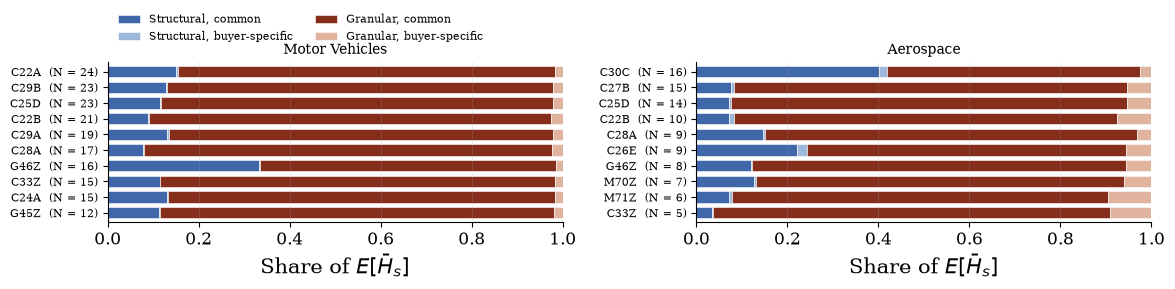

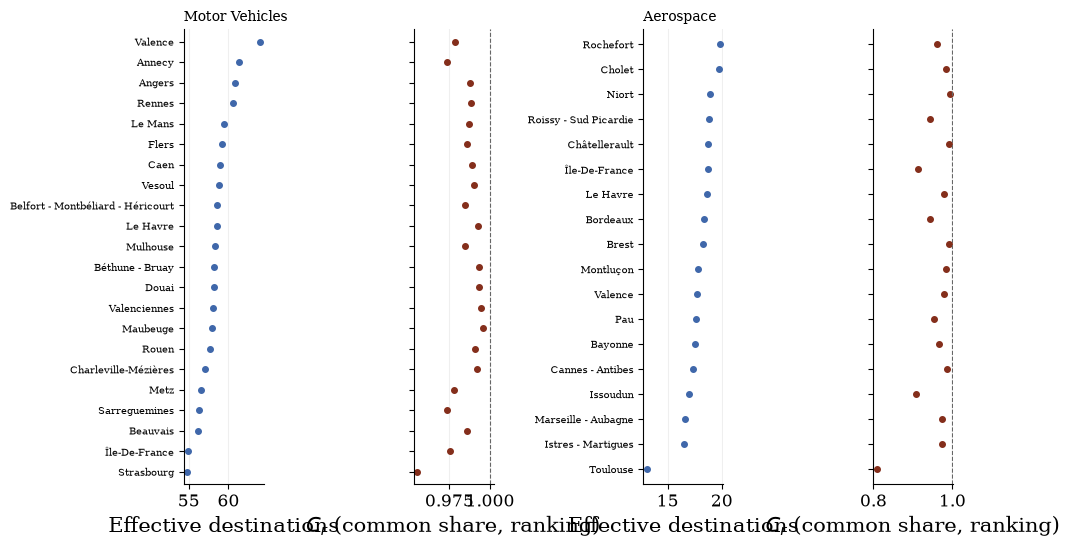

In [123]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
conc_sector, conc_gran, conc_buyers = {}, {}, {}
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"\n[{industry}, mu = {MU}] — concentration and commonality, sector by sector")
    rep = concentration_report(data, industry=industry)
    conc_sector[cfg["display_name"]] = rep["sector"]
    conc_buyers[cfg["display_name"]] = rep["buyers"]
    if rep["granular"] is not None:
        conc_gran[cfg["display_name"]] = rep["granular"]

    print(f"\n  Table: the section's five columns [{industry}]")
    display(rep["table"].round(3))

# the granularity figure: the four cells per sector, sectors ordered by N_s
if conc_gran:
    plot_concentration_decomposition(
        conc_gran, save_to=f"{out_folder}/concentration_decomposition_mu{MU}.pdf")
    plt.show()

# the appendix figure: every buyer's effective number and its C_r, one row order
plot_buyer_concentration(
    conc_buyers, save_to=f"{out_folder}/buyer_concentration_mu{MU}.pdf")
plt.show()

## Test 6 — how much of the shock does the region keep?

How far the euro travels is not the same question as how much of it the shocked region
retains, and it is the second that the reduced-form part of the paper measures:

$$L_r(d) = \frac{\sum_{r' : d_{r'r} \le d} X_{r'r}}{\sum_{r'} X_{r'r}}.$$

The denominator is UPSTREAM SALES ONLY — the euro of downstream demand is not in it — so it is
a share of what propagates. The radius is a free parameter throughout; the headline is 200 km,
the radius of the reduced-form evidence, and `local_share_profile` sweeps it so that number is
visibly one point on a CDF rather than assumed robust.

**This is where the sign reversal lives, and it is the section's sharpest result.** In motor
vehicles the two forces reinforce: removing either lowers the local share. In aerospace they
work against each other — equalising $\hat T$ *raises* it. Comparative advantage there is not a
localising force at all: it takes the response off the region where the shock starts and sends
it to the hubs. That is precisely the reallocation the average distance of test 4 nearly
cancels, which is why $d_r$ and $L_r$ are both needed rather than one being a check on the
other.

The map is drawn because $L_r(d)$ is a number attached to a PLACE, and a bar chart sorted by
value destroys exactly the geography the result claims. Its colour scale is PINNED and shared
across the pair: the content is that aerospace reaches 0.56 where motor vehicles never passes
0.44, and a per-panel scale would rescale that away and paint the two maps alike.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto]  within 100 km: mean 0.074, median 0.059, min 0.024, max 0.180
[auto]  within 200 km: mean 0.238, median 0.213, min 0.155, max 0.437


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


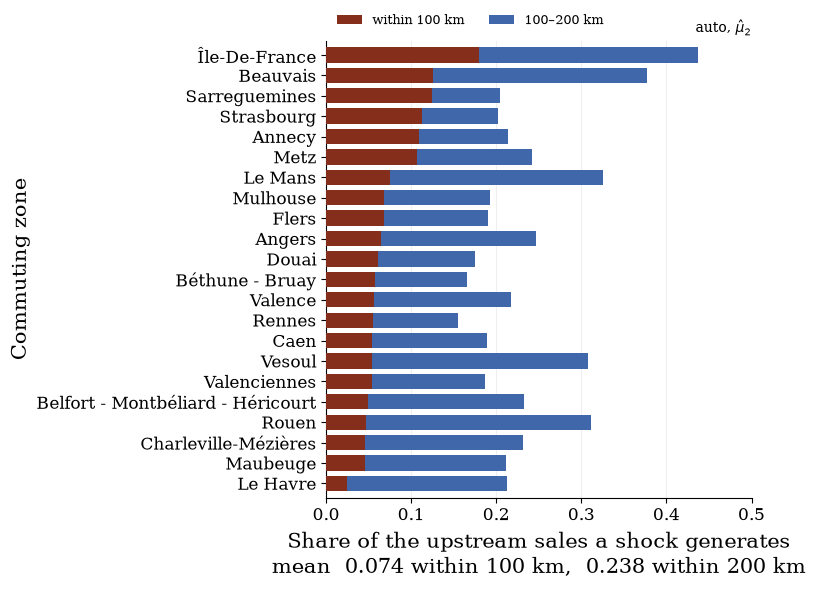

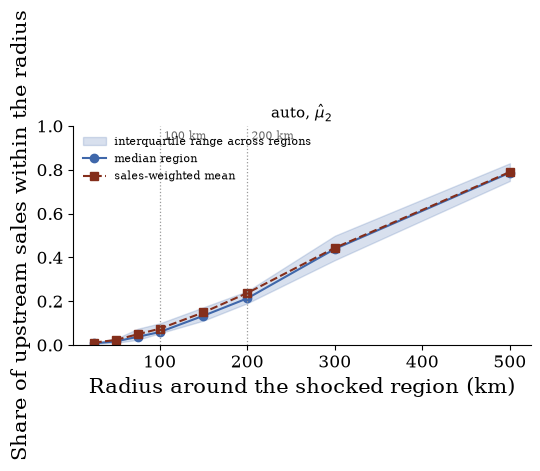

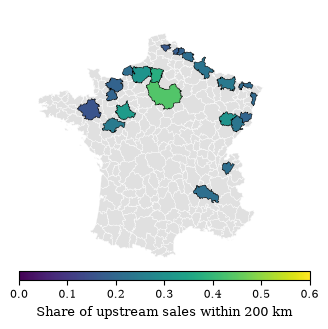

  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.074 vs closed-form both-forces 0.073 — the gap is granularity, not a different economy


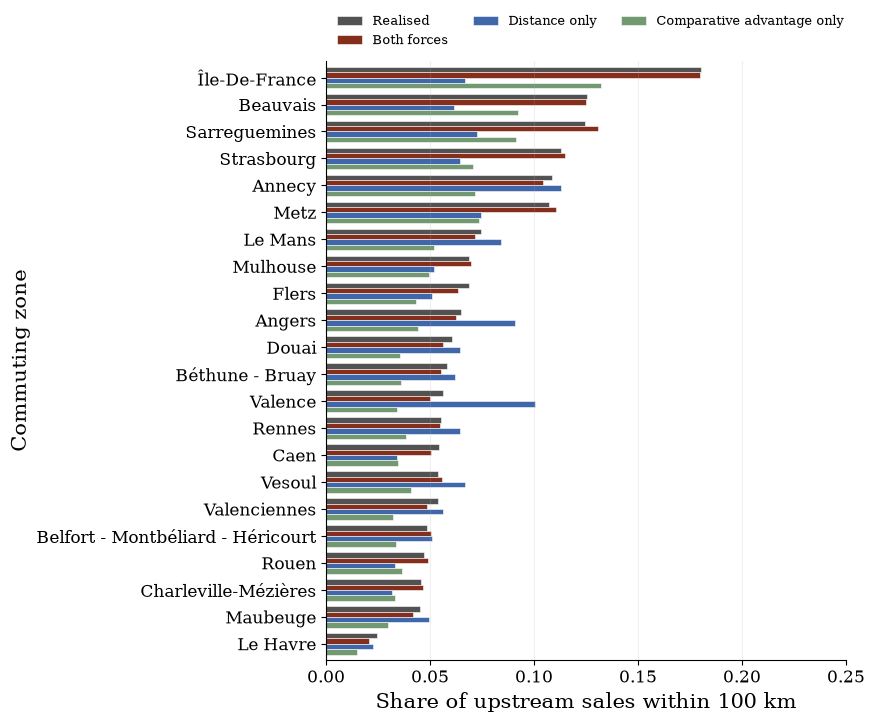

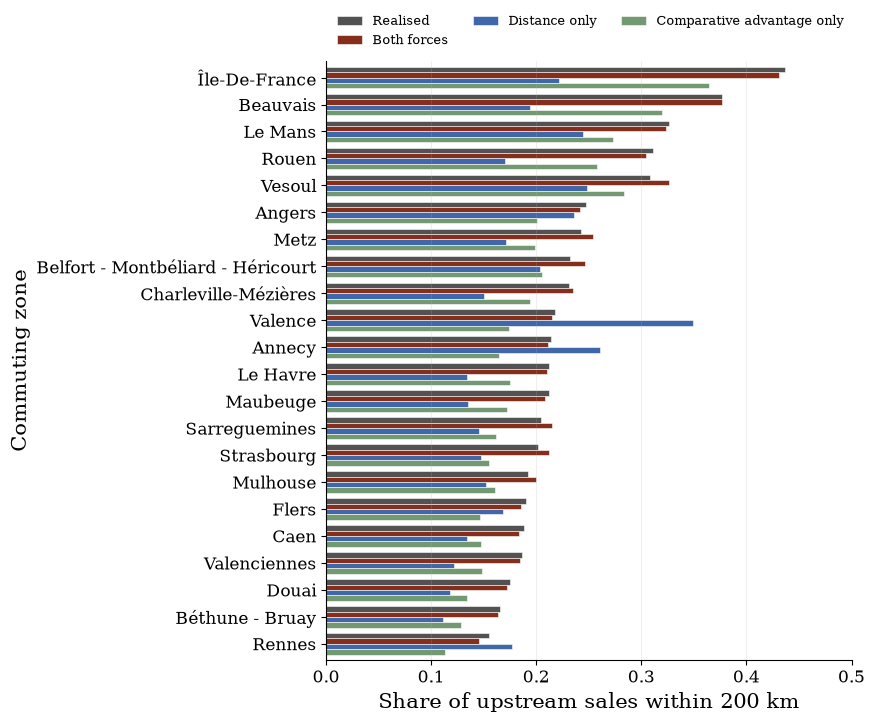

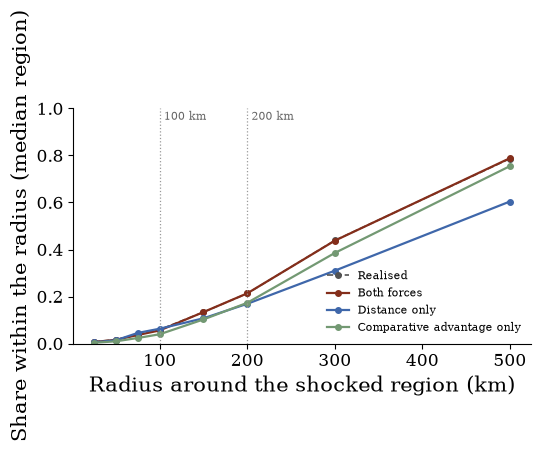

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero]  within 100 km: mean 0.088, median 0.058, min 0.006, max 0.392
[aero]  within 200 km: mean 0.213, median 0.197, min 0.031, max 0.563


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


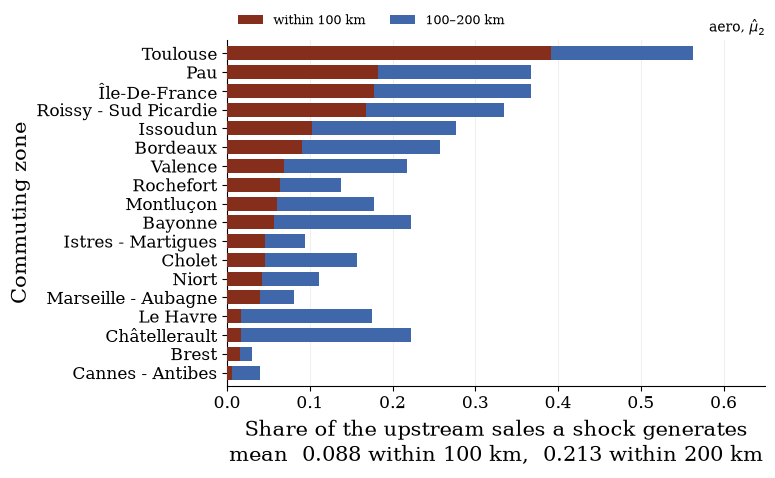

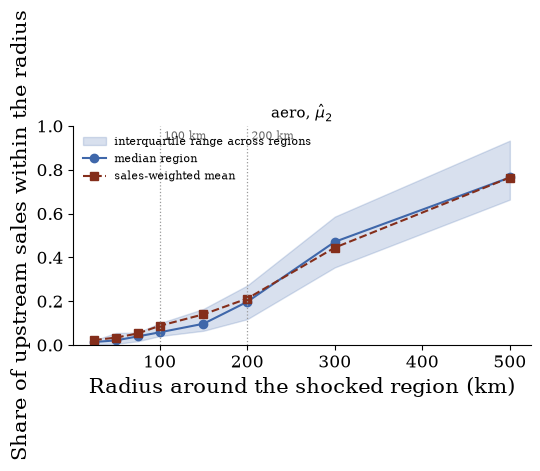

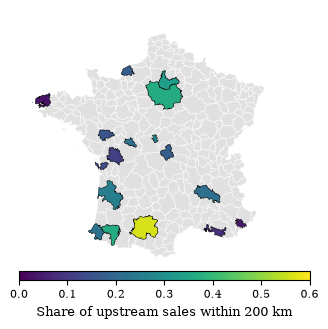

  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.088 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy


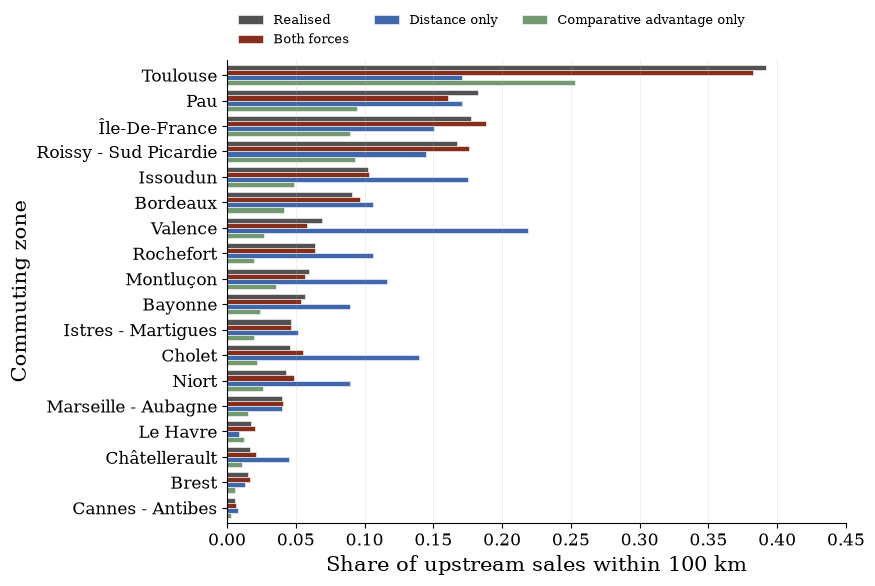

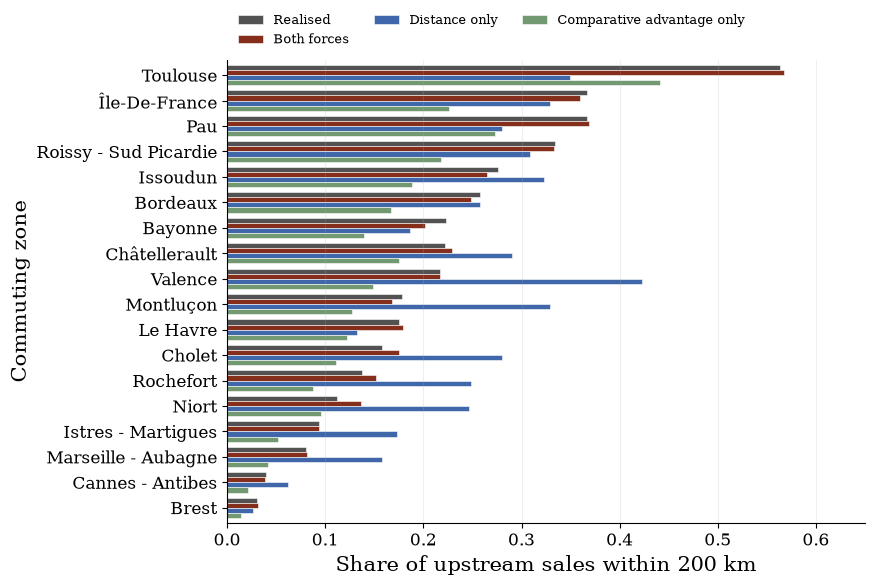

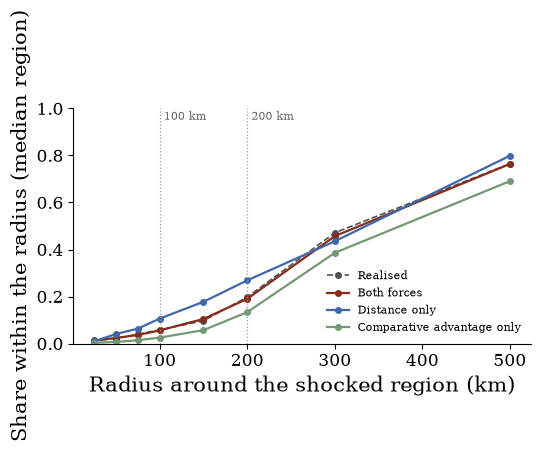

In [124]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    diff = build_diffusion_frame(data)
    summ = amplification_summary(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    prof = local_share_profile(data, diffusion=diff)

    for d in AMPLIFICATION_RADII:
        c = f"share_within_{int(d)}km"
        print(f"[{industry}]  within {d:g} km: mean {summ[c].mean():.3f}, "
              f"median {summ[c].median():.3f}, min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_local_share(data, radii=AMPLIFICATION_RADII, summary=summ,
                     save_to=f"{out_folder}/local_share_{industry}_mu{MU}.pdf")
    plt.show()
    plot_local_share_profile(data, profile=prof, mark=AMPLIFICATION_RADII,
                             save_to=f"{out_folder}/local_share_profile_{industry}_mu{MU}.pdf")
    plt.show()

    # the map: L_r(d) is a number attached to a place. Guarded on the geometry.
    try:
        plot_local_share_map(data, radius_km=AMPLIFICATION_RADII[-1], summary=summ,
                             vlim=LOCAL_SHARE_MAP_VLIM_WIDE,
                             save_to=f"{out_folder}/local_share_map{int(AMPLIFICATION_RADII[-1])}km_{industry}_mu{MU}.pdf")
        plt.show()
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  local-share map skipped: {type(e).__name__}: {e}")

    # the sign reversal, region by region and as the whole profile
    det = counterfactual_amplification(data, radii=AMPLIFICATION_RADII, diffusion=diff)
    for d in AMPLIFICATION_RADII:
        plot_counterfactual_local_share(
            data, radius_km=d, detail=det,
            save_to=f"{out_folder}/counterfactual_local_share{int(d)}km_{industry}_mu{MU}.pdf")
        plt.show()
    plot_counterfactual_profile(data, mark=AMPLIFICATION_RADII, diffusion=diff,
                                save_to=f"{out_folder}/counterfactual_profile_{industry}_mu{MU}.pdf")
    plt.show()


## Test 7 — what does the finite variety count cost?

With $N_s$ finite the network is a RANDOM object, so no single realisation is a result. This
test is not a caveat on tests 1–6; it measures something they cannot see.

**What is invariant, and why.** Under Fréchet the identity of a variety's winner is
independent of its realised price, so conditionally on prices the location indicators are
i.i.d. and independent of them: $\mathbb{E}[L_r(d)]$ is EXACTLY invariant to $N_s$ — the same
argument that gives $\hat q \perp N_s$. The point estimates of tests 1, 3 and 6 were therefore
right whatever the variety count.

**What is not.** The SUPPORT: a buyer sources $\sum_s \hat N_s$ varieties, so a shock reaches a
few dozen origins rather than every commuting zone, and the loss is larger in the industry
where comparative advantage concentrates sourcing. The DISPERSION: the spread of $L_r(100)$
across realisations is of the same order as its mean, so the cross-region contrast the map
reports (a contrast of expectations) stands while a statement about one region in one year does
not. And $D_r$ rises: the within-sector index is convex in the draws, so a finite basket is on
average dearer, and with $\lambda < 1$ that raises the intermediate share — the price-index
channel, which is why the gap from the continuum is not sampling noise.


In [125]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    print(f"[{industry}, mu = {MU}]")
    try:
        granularity_report(data, radii=AMPLIFICATION_RADII)
        # the spread one draw carries, region by region
        display(granular_band(data, radii=AMPLIFICATION_RADII).round(3))
    except (FileNotFoundError, KeyError, ValueError) as e:
        print(f"  granularity report skipped: {type(e).__name__}: {e}")


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8480           0.0115     1.8378       0.0102           0.0055
mean_upstream_distance       347.2472          23.6606   345.7733       1.4739           0.0043
supplier_cells               112.9336           5.5331   273.2273    -160.2936          -0.5867
share_within_100km             0.0745           0.0301     0.0749      -0.0004          -0.0050
share_within_200km             0.2376           0.0510     0.2389      -0.0013          -0.0055
  a shock reaches 113 origins with N_hat_s varieties against 273 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
12,Île-De-France,1.842,0.012,257.290,21.134,109.74,5.678,0.180,0.046,0.437,0.058,50
13,Charleville-Mézières,1.848,0.011,338.270,24.214,111.52,5.339,0.046,0.020,0.231,0.048,50
26,Beauvais,1.845,0.012,295.575,22.965,110.90,5.614,0.126,0.041,0.377,0.062,50
36,Le Havre,1.849,0.011,363.149,24.844,113.72,5.789,0.024,0.021,0.212,0.051,50
37,Rouen,1.847,0.012,324.287,24.289,112.52,6.018,0.047,0.024,0.311,0.064,50
58,Caen,1.849,0.011,366.721,26.145,114.68,5.593,0.054,0.036,0.189,0.053,50
68,Flers,1.849,0.011,357.089,25.632,114.92,5.428,0.069,0.039,0.190,0.051,50
88,Douai,1.849,0.011,368.355,23.505,113.00,5.406,0.061,0.026,0.175,0.040,50
89,Valenciennes,1.849,0.011,368.352,23.353,112.78,5.327,0.054,0.024,0.186,0.041,50


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  granularity = the finite-variety economy minus its N_s -> infinity limit (50 realisations):
                        granular_mean  sd_across_draws  continuum  granularity  granularity_rel
quantity                                                                                       
amplification                  1.8733           0.0171     1.8608       0.0124           0.0067
mean_upstream_distance       353.2472          30.5876   352.8476       0.3996           0.0011
supplier_cells                61.6422           3.3333   261.5000    -199.8578          -0.7643
share_within_100km             0.0883           0.0467     0.0924      -0.0041          -0.0441
share_within_200km             0.2129           0.0736     0.2122       0.0007           0.0035
  a shock reaches 62 origins with N_hat_s varieties against 262 in the continuum — the extensive margin is the whole of what granularity is for.


,region,amplification,amplification_sd,mean_upstream_distance,mean_upstream_distance_sd,supplier_cells,supplier_cells_sd,share_within_100km,share_within_100km_sd,share_within_200km,share_within_200km_sd,n_replications
ze2010_downstream,,,,,,,,,,,,
7,Roissy - Sud Picardie,1.873,0.019,375.326,44.264,57.92,3.680,0.168,0.062,0.334,0.087,50
11,Toulouse,1.857,0.015,253.227,38.852,59.06,3.053,0.391,0.111,0.562,0.095,50
12,Île-De-France,1.871,0.019,350.262,45.077,56.54,3.512,0.178,0.067,0.367,0.092,50
36,Le Havre,1.880,0.017,453.455,39.915,59.82,3.607,0.017,0.016,0.176,0.060,50
45,Issoudun,1.866,0.020,267.270,25.550,60.46,3.610,0.102,0.061,0.277,0.102,50
137,Cholet,1.874,0.017,335.252,23.200,61.94,3.216,0.046,0.034,0.157,0.065,50
156,Brest,1.888,0.016,590.059,28.932,62.14,3.314,0.015,0.017,0.031,0.029,50
170,Châtellerault,1.871,0.018,287.374,20.220,61.54,3.327,0.016,0.020,0.222,0.088,50
176,Rochefort,1.872,0.016,313.911,25.298,62.34,3.185,0.063,0.055,0.137,0.070,50
